<div align="center">
    <img src="https://www.sharif.ir/documents/20124/0/logo-fa-IR.png/4d9b72bc-494b-ed5a-d3bb-e7dfd319aec8?t=1609608338755" alt="Logo" width="200">
    <p><b>HW1 @ Deep Learning Course, Dr. Soleymani</b></p>
    <p><b>ِDesinged by Payam Taebi</b></p>
</div>

---




*Full Name:Mohammadreza koohi*

*Student Number:402207199*

# Setup Code
Before getting started we need to run some boilerplate code to set up our environment. You'll need to rerun this setup code each time you start the notebook.

First, run this cell load the [autoreload](https://ipython.readthedocs.io/en/stable/config/extensions/autoreload.html?highlight=autoreload) extension. This allows us to edit `.py` source files, and re-import them into the notebook for a seamless editing and debugging experience.

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Google Colab Setup
Next we need to run a few commands to set up our environment on Google Colab. If you are running this notebook on a local machine you can skip this section.

Run the following cell to mount your Google Drive. Follow the link, sign in to your Google account (the same account you used to store this notebook!) and copy the authorization code into the text box that appears below.

Now recall the path in your Google Drive where you uploaded this notebook, fill it in below. If everything is working correctly then running the folowing cell should print the filenames from the assignment:

```
['pytorch_basic.py', 'pytorch_basic.ipynb']
```

In [4]:
import os

# TODO: Fill in the Google Drive path where you uploaded the assignment
# Example: If you create a 2020FA folder and put all the files under A1 folder, then '2020FA/A1'
# GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = '2020FA/A1'
GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'Pytorch_question'
GOOGLE_DRIVE_PATH = os.path.join('drive', 'My Drive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
print(os.listdir('/content/drive/MyDrive/DL_HW1'))

['2-NN_Scratch.ipynb', '3-Optimization.ipynb', '4-Lazy_Gradient.ipynb', '.ipynb_checkpoints', 'utils', '__pycache__', 'pytorch_basic.py', 'models', 'data_MNIST', '1-Basics.ipynb']


Once you have successfully mounted your Google Drive and located the path to this assignment, run the following cell to allow us to import from the `.py` files of this assignment. If it works correctly, it should print the message:

```
Hello from pytorch_basic.py!
```

as well as the last edit time for the file `pytorch_basic.py`.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import sys
sys.path.append('/content/drive/MyDrive/DL_HW1')

import time, os
os.environ["TZ"] = "'Asia/Tehran'"
time.tzset()

from pytorch_basic import hello
hello()

pytorch_path = os.path.join(GOOGLE_DRIVE_PATH, 'pytorch_basic.py')
edit_time = time.ctime(os.path.getmtime('/content/drive/MyDrive/DL_HW1'))
print('pytorch_basic.py last edited on %s' % edit_time)

Hello from pytorch_basic.py!
pytorch_basic.py last edited on Sat Mar  8 18:23:59 2025


# Introduction

Python 3 and [PyTorch](https://pytorch.org/) will be used throughout the semseter, so it is important to be familiar with them. This material in this notebook draws from http://cs231n.github.io/python-numpy-tutorial/ and https://github.com/kuleshov/cs228-material/blob/master/tutorials/python/cs228-python-tutorial.ipynb. This material focuses mainly on PyTorch.

This notebook will walk you through many of the important features of PyTorch that you will need to use throughout the semester.

When completing the notebook, please adhere to the following rules:
- Do not write or modify any code outside of code blocks
- Do not add or delete any cells from the notebook. You may add new cells to perform scatch work, but delete them before submitting.
- Run all cells before submitting. You will only get credit for code that has been run.

This notebook contains many inline sanity checks for the code you write. However, **passing these sanity checks does not mean your code is correct!** During grading we may run your code on additional inputs, and we may look at your code to make sure you've followed the specific guildelines for each implementation. You are encouraged to write additional test cases for the functions you are asked to write instead of solely relying on the sanity checks in the notebook.

# PyTorch (70 points)

[PyTorch](https://pytorch.org/) is an open source machine learning framework. At its core, PyTorch provides a few key features:

- A multidimensional **Tensor** object, similar to [numpy](https://numpy.org/) but with GPU accelleration.
- An optimized **autograd** engine for automatically computing derivatives
- A clean, modular API for building and deploying **deep learning models**

We will use PyTorch for all programming assignments throughout the semester. This notebook will focus on the **Tensor API**, as it is the main part of PyTorch that we will use for the first few assignments.

You can find more information about PyTorch by following one of the [oficial tutorials](https://pytorch.org/tutorials/) or by [reading the documentation](https://pytorch.org/docs/stable/).

To use PyTorch, we first need to import the `torch` package.

We also check the version; the assignments in this course will use PyTorch verion 1.6.0, since this is the default version in Google Colab.

In [6]:
import torch
print(torch.__version__)

2.6.0+cu124


## Tensor Basics

### Creating and Accessing tensors

A `torch` **tensor** is a multidimensional grid of values, all of the same type, and is indexed by a tuple of nonnegative integers. The number of dimensions is the **rank** of the tensor; the **shape** of a tensor is a tuple of integers giving the size of the array along each dimension.

We can initialize `torch` tensor from nested Python lists. We can access or mutate elements of a PyTorch tensor using square brackets.

Accessing an element from a PyTorch tensor returns a PyTorch scalar; we can convert this to a Python scalar using the `.item()` method:

In [7]:
# Create a rank 1 tensor from a Python list
a = torch.tensor([1, 2, 3])
print('Here is a:')
print(a)
print('type(a): ', type(a))
print('rank of a: ', a.dim())
print('a.shape: ', a.shape)

# Access elements using square brackets
print()
print('a[0]: ', a[0])
print('type(a[0]): ', type(a[0]))
print('type(a[0].item()): ', type(a[0].item()))

# Mutate elements using square brackets
a[1] = 10
print()
print('a after mutating:')
print(a)

Here is a:
tensor([1, 2, 3])
type(a):  <class 'torch.Tensor'>
rank of a:  1
a.shape:  torch.Size([3])

a[0]:  tensor(1)
type(a[0]):  <class 'torch.Tensor'>
type(a[0].item()):  <class 'int'>

a after mutating:
tensor([ 1, 10,  3])


The example above shows a one-dimensional tensor; we can similarly create tensors with two or more dimensions:

In [8]:
# Create a two-dimensional tensor
b = torch.tensor([[1, 2, 3], [4, 5, 5]])
print('Here is b:')
print(b)
print('rank of b:', b.dim())
print('b.shape: ', b.shape)

# Access elements from a multidimensional tensor
print()
print('b[0, 1]:', b[0, 1])
print('b[1, 2]:', b[1, 2])

# Mutate elements of a multidimensional tensor
b[1, 1] = 100
print()
print('b after mutating:')
print(b)

Here is b:
tensor([[1, 2, 3],
        [4, 5, 5]])
rank of b: 2
b.shape:  torch.Size([2, 3])

b[0, 1]: tensor(2)
b[1, 2]: tensor(5)

b after mutating:
tensor([[  1,   2,   3],
        [  4, 100,   5]])


Now it's **your turn**. In the file `pytorch_basic.py`, complete the implementation of the functions `create_sample_tensor`, `mutate_tensor`, and `count_tensor_elements` to practice constructing, mutating, and thinking about the shapes of tensors.

In [9]:
from pytorch_basic import create_sample_tensor, mutate_tensor, count_tensor_elements

# Create a sample tensor
x = create_sample_tensor()
print('Here is the sample tensor:')
print(x)

# Mutate the tensor by setting a few elements
indices = [(0, 0), (1, 0), (1, 1)]
values = [4, 5, 6]
mutate_tensor(x, indices, values)
print('\nAfter mutating:')
print(x)
print('\nCorrect shape: ', x.shape == (3, 2))
print('x[0, 0] correct: ', x[0, 0].item() == 4)
print('x[1, 0] correct: ', x[1, 0].item() == 5)
print('x[1, 1] correct: ', x[1, 1].item() == 6)

# Check the number of elements in the sample tensor
num = count_tensor_elements(x)
print('\nNumber of elements in x: ', num)
print('Correctly counted: ', num == 6)

Here is the sample tensor:
tensor([[  0.,  10.],
        [100.,   0.],
        [  0.,   0.]])

After mutating:
tensor([[ 4., 10.],
        [ 5.,  6.],
        [ 0.,  0.]])

Correct shape:  True
x[0, 0] correct:  True
x[1, 0] correct:  True
x[1, 1] correct:  True

Number of elements in x:  6
Correctly counted:  True


### Tensor constructors

PyTorch provides many convenience methods for constructing tensors; this avoids the need to use Python lists. For example:

- [`torch.zeros`](https://pytorch.org/docs/1.1.0/torch.html#torch.zeros): Creates a tensor of all zeros
- [`torch.ones`](https://pytorch.org/docs/1.1.0/torch.html#torch.ones): Creates a tensor of all ones
- [`torch.rand`](https://pytorch.org/docs/1.1.0/torch.html#torch.rand): Creates a tensor with uniform random numbers

You can find a full list of tensor creation operations [in the documentation](https://pytorch.org/docs/stable/torch.html#creation-ops).

In [10]:
# Create a tensor of all zeros
a = torch.zeros(2, 3)
print('tensor of zeros:')
print(a)

# Create a tensor of all ones
b = torch.ones(1, 2)
print('\ntensor of ones:')
print(b)

# Create a 3x3 identity matrix
c = torch.eye(3)
print('\nidentity matrix:')
print(c)

# Tensor of random values
d = torch.rand(4, 5)
print('\nrandom tensor:')
print(d)

tensor of zeros:
tensor([[0., 0., 0.],
        [0., 0., 0.]])

tensor of ones:
tensor([[1., 1.]])

identity matrix:
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

random tensor:
tensor([[0.2486, 0.0537, 0.7177, 0.7915, 0.8589],
        [0.7939, 0.6033, 0.6850, 0.4928, 0.4534],
        [0.9122, 0.6992, 0.0211, 0.0804, 0.4667],
        [0.3687, 0.1193, 0.7416, 0.1431, 0.1243]])


**Your turn**: In the file `pytorch_basic.py`, complete the implementation of `create_tensor_of_pi` to practice using a tensor constructor.

Hint: [`torch.full`](https://pytorch.org/docs/stable/generated/torch.full.html#torch.full)

In [11]:
from pytorch_basic import create_tensor_of_pi

x = create_tensor_of_pi(4, 5)

print('x is a tensor:', torch.is_tensor(x))
print('x has correct shape: ', x.shape == (4, 5))
print('x is filled with sevens: ', (x == 3.14).all().item() == 1)

x is a tensor: True
x has correct shape:  True
x is filled with sevens:  True


### Datatypes

In the examples above, you may have noticed that some of our tensors contained floating-point values, while others contained integer values.

PyTorch provides a [large set of numeric datatypes](https://pytorch.org/docs/stable/tensor_attributes.html#torch.torch.dtype) that you can use to construct tensors. PyTorch tries to guess a datatype when you create a tensor; functions that construct tensors typically have a `dtype` argument that you can use to explicitly specify a datatype.

Each tensor has a `dtype` attribute that you can use to check its data type:

In [12]:
# Let torch choose the datatype
x0 = torch.tensor([1, 2])   # List of integers
x1 = torch.tensor([1., 2.]) # List of floats
x2 = torch.tensor([1., 2])  # Mixed list
print('dtype when torch chooses for us:')
print('List of integers:', x0.dtype)
print('List of floats:', x1.dtype)
print('Mixed list:', x2.dtype)

# Force a particular datatype
y0 = torch.tensor([1, 2], dtype=torch.float32)  # 32-bit float
y1 = torch.tensor([1, 2], dtype=torch.int32)    # 32-bit (signed) integer
y2 = torch.tensor([1, 2], dtype=torch.int64)    # 64-bit (signed) integer
print('\ndtype when we force a datatype:')
print('32-bit float: ', y0.dtype)
print('32-bit integer: ', y1.dtype)
print('64-bit integer: ', y2.dtype)

# Other creation ops also take a dtype argument
z0 = torch.ones(1, 2)  # Let torch choose for us
z1 = torch.ones(1, 2, dtype=torch.int16) # 16-bit (signed) integer
z2 = torch.ones(1, 2, dtype=torch.uint8) # 8-bit (unsigned) integer
print('\ntorch.ones with different dtypes')
print('default dtype:', z0.dtype)
print('16-bit integer:', z1.dtype)
print('8-bit unsigned integer:', z2.dtype)

dtype when torch chooses for us:
List of integers: torch.int64
List of floats: torch.float32
Mixed list: torch.float32

dtype when we force a datatype:
32-bit float:  torch.float32
32-bit integer:  torch.int32
64-bit integer:  torch.int64

torch.ones with different dtypes
default dtype: torch.float32
16-bit integer: torch.int16
8-bit unsigned integer: torch.uint8


We can **cast** a tensor to another datatype using the [`.to()`](https://pytorch.org/docs/1.1.0/tensors.html#torch.Tensor.to) method; there are also convenience methods like [`.float()`](https://pytorch.org/docs/1.1.0/tensors.html#torch.Tensor.float) and [`.long()`](https://pytorch.org/docs/1.1.0/tensors.html#torch.Tensor.long) that cast to particular datatypes:


In [13]:
x0 = torch.eye(3, dtype=torch.int64)
x1 = x0.float()  # Cast to 32-bit float
x2 = x0.double() # Cast to 64-bit float
x3 = x0.to(torch.float32) # Alternate way to cast to 32-bit float
x4 = x0.to(torch.float64) # Alternate way to cast to 64-bit float
print('x0:', x0.dtype)
print('x1:', x1.dtype)
print('x2:', x2.dtype)
print('x3:', x3.dtype)
print('x4:', x4.dtype)

x0: torch.int64
x1: torch.float32
x2: torch.float64
x3: torch.float32
x4: torch.float64


PyTorch provides several ways to create a tensor with the same datatype as another tensor:

- PyTorch provides tensor constructors such as [`torch.zeros_like()`](https://pytorch.org/docs/stable/generated/torch.zeros_like.html#torch.zeros_like) that create new tensors with the same shape and type as a given tensor
- Tensor objects have instance methods such as [`.new_zeros()`](https://pytorch.org/docs/stable/tensors.html#torch.Tensor.new_zeros) that create tensors the same type but possibly different shapes
- The tensor instance method [`.to()`](https://pytorch.org/docs/stable/tensors.html#torch.Tensor.to) can take a tensor as an argument, in which case it casts to the datatype of the argument.

In [14]:
x0 = torch.eye(3, dtype=torch.float64)  # Shape (3, 3), dtype torch.float64
x1 = torch.zeros_like(x0)               # Shape (3, 3), dtype torch.float64
x2 = x0.new_zeros(4, 5)                 # Shape (4, 5), dtype torch.float64
x3 = torch.ones(6, 7).to(x0)            # Shape (6, 7), dtype torch.float64)
print('x0 shape is %r, dtype is %r' % (x0.shape, x0.dtype))
print('x1 shape is %r, dtype is %r' % (x1.shape, x1.dtype))
print('x2 shape is %r, dtype is %r' % (x2.shape, x2.dtype))
print('x3 shape is %r, dtype is %r' % (x3.shape, x3.dtype))

x0 shape is torch.Size([3, 3]), dtype is torch.float64
x1 shape is torch.Size([3, 3]), dtype is torch.float64
x2 shape is torch.Size([4, 5]), dtype is torch.float64
x3 shape is torch.Size([6, 7]), dtype is torch.float64


**Your turn**: In the file `pytorch_basic.py`, implement the function `multiples_of_ten` which should create and return a tensor of dtype `torch.float64` containing all the multiples of ten in a given range.

Hint: [`torch.arange`](https://pytorch.org/docs/stable/generated/torch.arange.html#torch.arange)

In [15]:
from pytorch_basic import multiples_of_ten

start = 5
stop = 25
x = multiples_of_ten(start, stop)
print('Correct dtype: ', x.dtype == torch.float64)
print('Correct shape: ', x.shape == (2,))
print('Correct values: ', x.tolist() == [10, 20])

# If there are no multiples of ten in the given range you should return an empty tensor
start = 5
stop = 7
x = multiples_of_ten(start, stop)
print('\nCorrect dtype: ', x.dtype == torch.float64)
print('Correct shape: ', x.shape == (0,))

Correct dtype:  True
Correct shape:  True
Correct values:  True

Correct dtype:  True
Correct shape:  True


Even though PyTorch provides a large number of numeric datatypes, the most commonly used datatypes are:

- `torch.float32`: Standard floating-point type; used to store learnable parameters, network activations, etc. Nearly all arithmetic is done using this type.
- `torch.int64`: Typically used to store indices
- `torch.bool`: Stores boolean values: 0 is false and 1 is true
- `torch.float16`: Used for mixed-precision arithmetic, usually on NVIDIA GPUs with [tensor cores](https://www.nvidia.com/en-us/data-center/tensorcore/). You won't need to worry about this datatype in this course.

## Tensor indexing

We have already seen how to get and set individual elements of PyTorch tensors. PyTorch also provides many other ways of indexing into tensors. Getting comfortable with these different options makes it easy to modify different parts of tensors with ease.

### Slice indexing

Similar to Python lists and numpy arrays, PyTorch tensors can be **sliced** using the syntax `start:stop` or `start:stop:step`. The `stop` index is always non-inclusive: it is the first element not to be included in the slice.

Start and stop indices can be negative, in which case they count backward from the end of the tensor.

In [16]:
a = torch.tensor([0, 11, 22, 33, 44, 55, 66])
print(0, a)        # (0) Original tensor
print(1, a[2:5])   # (1) Elements between index 2 and 5
print(2, a[2:])    # (2) Elements after index 2
print(3, a[:5])    # (3) Elements before index 5
print(4, a[:])     # (4) All elements
print(5, a[1:5:2]) # (5) Every second element between indices 1 and 5
print(6, a[:-1])   # (6) All but the last element
print(7, a[-4::2]) # (7) Every second element, starting from the fourth-last

0 tensor([ 0, 11, 22, 33, 44, 55, 66])
1 tensor([22, 33, 44])
2 tensor([22, 33, 44, 55, 66])
3 tensor([ 0, 11, 22, 33, 44])
4 tensor([ 0, 11, 22, 33, 44, 55, 66])
5 tensor([11, 33])
6 tensor([ 0, 11, 22, 33, 44, 55])
7 tensor([33, 55])


For multidimensional tensors, you can provide a slice or integer for each dimension of the tensor in order to extract different types of subtensors:

In [17]:
# Create the following rank 2 tensor with shape (3, 4)
# [[ 1  2  3  4]
#  [ 5  6  7  8]
#  [ 9 10 11 12]]
a = torch.tensor([[1,2,3,4], [5,6,7,8], [9,10,11,12]])
print('Original tensor:')
print(a)
print('shape: ', a.shape)

# Get row 1, and all columns.
print('\nSingle row:')
print(a[1, :])
print(a[1])  # Gives the same result; we can omit : for trailing dimensions
print('shape: ', a[1].shape)

print('\nSingle column:')
print(a[:, 1])
print('shape: ', a[:, 1].shape)

# Get the first two rows and the last three columns
print('\nFirst two rows, last two columns:')
print(a[:2, -3:])
print('shape: ', a[:2, -3:].shape)

# Get every other row, and columns at index 1 and 2
print('\nEvery other row, middle columns:')
print(a[::2, 1:3])
print('shape: ', a[::2, 1:3].shape)

Original tensor:
tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])
shape:  torch.Size([3, 4])

Single row:
tensor([5, 6, 7, 8])
tensor([5, 6, 7, 8])
shape:  torch.Size([4])

Single column:
tensor([ 2,  6, 10])
shape:  torch.Size([3])

First two rows, last two columns:
tensor([[2, 3, 4],
        [6, 7, 8]])
shape:  torch.Size([2, 3])

Every other row, middle columns:
tensor([[ 2,  3],
        [10, 11]])
shape:  torch.Size([2, 2])


There are two common ways to access a single row or column of a tensor: using an integer will reduce the rank by one, and using a length-one slice will keep the same rank. Note that this is different behavior from MATLAB.

In [18]:
# Create the following rank 2 tensor with shape (3, 4)
a = torch.tensor([[1,2,3,4], [5,6,7,8], [9,10,11,12]])
print('Original tensor')
print(a)

row_r1 = a[1, :]    # Rank 1 view of the second row of a
row_r2 = a[1:2, :]  # Rank 2 view of the second row of a
print('\nTwo ways of accessing a single row:')
print(row_r1, row_r1.shape)
print(row_r2, row_r2.shape)

# We can make the same distinction when accessing columns::
col_r1 = a[:, 1]
col_r2 = a[:, 1:2]
print('\nTwo ways of accessing a single column:')
print(col_r1, col_r1.shape)
print(col_r2, col_r2.shape)

Original tensor
tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])

Two ways of accessing a single row:
tensor([5, 6, 7, 8]) torch.Size([4])
tensor([[5, 6, 7, 8]]) torch.Size([1, 4])

Two ways of accessing a single column:
tensor([ 2,  6, 10]) torch.Size([3])
tensor([[ 2],
        [ 6],
        [10]]) torch.Size([3, 1])


Slicing a tensor returns a **view** into the same data, so modifying it will also modify the original tensor. To avoid this, you can use the `clone()` method to make a copy of a tensor.

In [19]:
# Create a tensor, a slice, and a clone of a slice
a = torch.tensor([[1, 2, 3, 4], [5, 6, 7, 8]])
b = a[0, 1:]
c = a[0, 1:].clone()
print('Before mutating:')
print(a)
print(b)
print(c)

a[0, 1] = 20  # a[0, 1] and b[0] point to the same element
b[1] = 30     # b[1] and a[0, 2] point to the same element
c[2] = 40     # c is a clone, so it has its own data
print('\nAfter mutating:')
print(a)
print(b)
print(c)

print(a.storage().data_ptr() == c.storage().data_ptr())

Before mutating:
tensor([[1, 2, 3, 4],
        [5, 6, 7, 8]])
tensor([2, 3, 4])
tensor([2, 3, 4])

After mutating:
tensor([[ 1, 20, 30,  4],
        [ 5,  6,  7,  8]])
tensor([20, 30,  4])
tensor([ 2,  3, 40])
False


<ipython-input-19-ebe253bfaff2>:18: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  print(a.storage().data_ptr() == c.storage().data_ptr())


**Your turn**: In the file `pytorch_basic.py`, implement the function `slice_indexing_practice` to practice indexing tensors with different types of slices.

In [20]:
# We will use this helper function to check your results
def check(orig, actual, expected):
    if not torch.is_tensor(actual):
        return False
    expected = torch.tensor(expected)
    same_elements = (actual == expected).all().item()
    same_storage = (orig.storage().data_ptr() == actual.storage().data_ptr())
    return same_elements and same_storage

In [21]:
from pytorch_basic import slice_indexing_practice

# Create the following rank 2 tensor of shape (3, 5)
# [[ 1  2  3  4  5]
#  [ 6  7  8  9 10]
#  [11 12 13 14 15]]
x = torch.tensor([[1, 2, 3, 4, 5],
                  [6, 7, 8, 8, 10],
                  [11, 12, 13, 14, 15]])
out = slice_indexing_practice(x)

last_row = out[0]
print('last_row:')
print(last_row)
correct = check(x, last_row, [11, 12, 13, 14, 15])
print('Correct: %r\n' % correct)

third_col = out[1]
print('third_col:')
print(third_col)
correct = check(x, third_col, [[3], [8], [13]])
print('Correct: %r\n' % correct)

first_two_rows_three_cols = out[2]
print('first_two_rows_three_cols:')
print(first_two_rows_three_cols)
correct = check(x, first_two_rows_three_cols, [[1, 2, 3], [6, 7, 8]])
print('Correct: %r\n' % correct)

even_rows_odd_cols = out[3]
print('even_rows_odd_cols:')
print(even_rows_odd_cols)
correct = check(x, even_rows_odd_cols, [[2, 4], [12, 14]])
print('Correct: %r\n' % correct)

last_row:
tensor([11, 12, 13, 14, 15])
Correct: True

third_col:
tensor([[ 3],
        [ 8],
        [13]])
Correct: True

first_two_rows_three_cols:
tensor([[1, 2, 3],
        [6, 7, 8]])
Correct: True

even_rows_odd_cols:
tensor([[ 2,  4],
        [12, 14]])
Correct: True



So far we have used slicing to **access** subtensors; we can also use slicing to **modify** subtensors by writing assignment expressions where the left-hand side is a slice expression, and the right-hand side is a constant or a tensor of the correct shape:

In [22]:
a = torch.zeros(2, 4, dtype=torch.int64)
a[:, :2] = 1
a[:, 2:] = torch.tensor([[2, 3], [4, 5]])
print(a)

tensor([[1, 1, 2, 3],
        [1, 1, 4, 5]])


**Your turn**: in the file `pytorch_basic.py`, implement the function `slice_assignment_practice` to practice modifying tensors with slicing assignment statements.

This function should use slicing assignment operations to modify the first four rows and first six columns of the input tensor so they are equal to

$$
\begin{bmatrix}
0 & 1 & 2 & 2 & 2 & 2 \\
0 & 1 & 2 & 2 & 2 & 2 \\
3 & 4 & 3 & 4 & 5 & 5 \\
3 & 4 & 3 & 4 & 5 & 5 \\
\end{bmatrix}
$$

Your implementation must obey the following:
- You should mutate the tensor x in-place and return it
- You should only modify the first 4 rows and first 6 columns; all other
elements should remain unchanged
- You may only mutate the tensor using slice assignment operations, where you
assign an integer to a slice of the tensor
- You must use <= 6 slicing operations to achieve the desired result

In [23]:
from pytorch_basic import slice_assignment_practice

x = torch.zeros(5, 7, dtype=torch.int64)
print('Here is x before calling slice_assignment_practice:')
print(x)
slice_assignment_practice(x)
print('Here is x after calling slice assignment practice:')
print(x)

expected = [
    [0, 1, 2, 2, 2, 2, 0],
    [0, 1, 2, 2, 2, 2, 0],
    [3, 4, 3, 4, 5, 5, 0],
    [3, 4, 3, 4, 5, 5, 0],
    [0, 0, 0, 0, 0, 0, 0],
]
print('Correct: ', x.tolist() == expected)

Here is x before calling slice_assignment_practice:
tensor([[0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0]])
Here is x after calling slice assignment practice:
tensor([[0, 1, 2, 2, 2, 2, 0],
        [0, 1, 2, 2, 2, 2, 0],
        [3, 4, 3, 4, 5, 5, 0],
        [3, 4, 3, 4, 5, 5, 0],
        [0, 0, 0, 0, 0, 0, 0]])
Correct:  True


### Integer tensor indexing

When you index into torch tensor using slicing, the resulting tensor view will always be a subarray of the original tensor. This is powerful, but can be restrictive.

We can also use **index arrays** to index tensors; this lets us construct new tensors with a lot more flexibility than using slices.

As an example, we can use index arrays to reorder the rows or columns of a tensor:

In [24]:
# Create the following rank 2 tensor with shape (3, 4)
# [[ 1  2  3  4]
#  [ 5  6  7  8]
#  [ 9 10 11 12]]
a = torch.tensor([[1, 2, 3, 4],
                  [5, 6, 7, 8],
                  [9, 10, 11, 12]])
print('Original tensor:')
print(a)

# Create a new tensor of shape (5, 4) by reordering rows from a:
# - First two rows same as the first row of a
# - Third row is the same as the last row of a
# - Fourth and fifth rows are the same as the second row from a
idx = [0, 0, 2, 1, 1]  # index arrays can be Python lists of integers
print('\nReordered rows:')
print(a[idx])

# Create a new tensor of shape (3, 4) by reversing the columns from a
idx = torch.tensor([3, 2, 1, 0])  # Index arrays can be int64 torch tensors
print('\nReordered columns:')
print(a[:, idx])

Original tensor:
tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])

Reordered rows:
tensor([[ 1,  2,  3,  4],
        [ 1,  2,  3,  4],
        [ 9, 10, 11, 12],
        [ 5,  6,  7,  8],
        [ 5,  6,  7,  8]])

Reordered columns:
tensor([[ 4,  3,  2,  1],
        [ 8,  7,  6,  5],
        [12, 11, 10,  9]])


More generally, given index arrays `idx0` and `idx1` with `N` elements each, `a[idx0, idx1]` is equivalent to:

```
torch.tensor([
  a[idx0[0], idx1[0]],
  a[idx0[1], idx1[1]],
  ...,
  a[idx0[N - 1], idx1[N - 1]]
])
```

(A similar pattern extends to tensors with more than two dimensions)

We can for example use this to get or set the diagonal of a tensor:

In [25]:
a = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print('Original tensor:')
print(a)

idx = [0, 1, 2]
print('\nGet the diagonal:')
print(a[idx, idx])

# Modify the diagonal
a[idx, idx] = torch.tensor([11, 22, 33])
print('\nAfter setting the diagonal:')
print(a)

Original tensor:
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

Get the diagonal:
tensor([1, 5, 9])

After setting the diagonal:
tensor([[11,  2,  3],
        [ 4, 22,  6],
        [ 7,  8, 33]])


One useful trick with integer array indexing is selecting or mutating one element from each row or column of a matrix:

In [26]:
# Create a new tensor from which we will select elements
a = torch.tensor([[1, 2, 3],
                  [4, 5, 6],
                  [7, 8, 9],
                  [10, 11, 12]])
print('Original tensor:')
print(a)

# Take on element from each row of a:
# from row 0, take element 1;
# from row 1, take element 2;
# from row 2, take element 1;
# from row 3, take element 0
idx0 = torch.arange(a.shape[0])  # Quick way to build [0, 1, 2, 3]
idx1 = torch.tensor([1, 2, 1, 0])
print('\nSelect one element from each row:')
print(a[idx0, idx1])

# Now set each of those elements to zero
a[idx0, idx1] = 0
print('\nAfter modifying one element from each row:')
print(a)

Original tensor:
tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])

Select one element from each row:
tensor([ 2,  6,  8, 10])

After modifying one element from each row:
tensor([[ 1,  0,  3],
        [ 4,  5,  0],
        [ 7,  0,  9],
        [ 0, 11, 12]])


**Your turn**: in the file `pytorch_basic.py`, implement the functions `shuffle_cols`, `reverse_rows`, and `take_one_elem_per_col` to practice using integer indexing to manipulate tensors. In each of these functions, your implementation should construct the output tensor **using a single indexing operation on the input**.

In [27]:
from pytorch_basic import shuffle_cols, reverse_rows, take_one_elem_per_col

# Build a tensor of shape (4, 3):
# [[ 1,  2,  3],
#  [ 4,  5,  6],
#  [ 7,  8,  9],
#  [10, 11, 12]]
x = torch.tensor([[1, 2, 3],
                  [4, 5, 6],
                  [7, 8, 9],
                  [10, 11, 12]])
print('Here is x:')
print(x)

y1 = shuffle_cols(x)
print('\nHere is shuffle_cols(x):')
print(y1)
expected = [[1, 1, 3, 2],
            [4, 4, 6, 5],
            [7, 7, 9, 8],
            [10, 10, 12, 11]]
y1_correct = torch.is_tensor(y1) and y1.tolist() == expected
print('Correct: %r\n' % y1_correct)

y2 = reverse_rows(x)
print('Here is reverse_rows(x):')
print(y2)
expected = [[10, 11, 12],
            [7, 8, 9],
            [4, 5, 6],
            [1, 2, 3]]
y2_correct = torch.is_tensor(y2) and y2.tolist() == expected
print('Correct: %r\n' % y2_correct)

y3 = take_one_elem_per_col(x)
print('Here is take_one_elem_per_col(x):')
print(y3)
expected = [4, 2, 12]
y3_correct = torch.is_tensor(y3) and y3.tolist() == expected
print('Correct: %r' % y3_correct)

Here is x:
tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])

Here is shuffle_cols(x):
tensor([[ 1,  1,  3,  2],
        [ 4,  4,  6,  5],
        [ 7,  7,  9,  8],
        [10, 10, 12, 11]])
Correct: True

Here is reverse_rows(x):
tensor([[10, 11, 12],
        [ 7,  8,  9],
        [ 4,  5,  6],
        [ 1,  2,  3]])
Correct: True

Here is take_one_elem_per_col(x):
tensor([ 4,  2, 12])
Correct: True


### Boolean tensor indexing

Boolean tensor indexing lets you pick out arbitrary elements of a tensor according to a boolean mask. Frequently this type of indexing is used to select or modify the elements of a tensor that satisfy some condition.

In PyTorch, we use tensors of dtype `torch.bool` to hold boolean masks.

(Prior to version 1.2.0, there was no `torch.bool` type so instead `torch.uint8` was usually used to represent boolean data, with 0 indicating false and 1 indicating true. Watch out for this in older PyTorch code!)

In [28]:
a = torch.tensor([[1,2], [3, 4], [5, 6]])
print('Original tensor:')
print(a)

# Find the elements of a that are bigger than 3. The mask has the same shape as
# a, where each element of mask tells whether the corresponding element of a
# is greater than three.
mask = (a > 3)
print('\nMask tensor:')
print(mask)

# We can use the mask to construct a rank-1 tensor containing the elements of a
# that are selected by the mask
print('\nSelecting elements with the mask:')
print(a[mask])

# We can also use boolean masks to modify tensors; for example this sets all
# elements <= 3 to zero:
a[a <= 3] = 0
print('\nAfter modifying with a mask:')
print(a)

Original tensor:
tensor([[1, 2],
        [3, 4],
        [5, 6]])

Mask tensor:
tensor([[False, False],
        [False,  True],
        [ True,  True]])

Selecting elements with the mask:
tensor([4, 5, 6])

After modifying with a mask:
tensor([[0, 0],
        [0, 4],
        [5, 6]])


**Your turn**: In the file `pytorch_basic.py`, implement the function `count_negative_entries` which counts the number of negative entries in a torch tensor. You can easily accomplish this using boolean tensor indexing. Your implementation should perform only a single indexing operation on the input tensor.

In [29]:
from pytorch_basic import count_negative_entries

# Make a few test cases
torch.manual_seed(598)
x0 = torch.tensor([[-1, -1, 0],
                   [0, 1, 2],
                   [3, 4, 5]])
x1 = torch.tensor([0, 1, 2, 3])
x2 = torch.randn(100, 100)
print('Correct for x0: ', count_negative_entries(x0) == 2)
print('Correct for x1: ', count_negative_entries(x1) == 0)
print('Correct for x2: ', count_negative_entries(x2) == 4984)

Correct for x0:  tensor(True)
Correct for x1:  tensor(True)
Correct for x2:  tensor(True)


Now implement the function `make_one_hot` that creates a matrix of **one-hot vectors** from a list of Python integers.

A one-hot vector for an integer $n$ is a vector that has a one in its $n$th slot, and zeros in all other slots. One-hot vectors are commonly used to represent categorical variables in machine learning models.

For example, given a list `[1, 4, 3, 2]` of integers, your function should produce the tensor:

```
[[0 1 0 0 0],
 [0 0 0 0 1],
 [0 0 0 1 0],
 [0 0 1 0 0]]
```

Here the first row corresponds to the first element of the list: it has a one at index 1, and zeros at all other indices. The second row corresponds to the second element of the list: it has a one at index 4, and zeros at all other indices. The other rows follow the same pattern. The output has just enough columns so that none of the rows go out-of-bounds: the largest index in the input is 4, so the output matrix has 5 columns.

In [30]:
from pytorch_basic import make_one_hot

def check_one_hot(x, y):
    C = y.shape[1]
    for i, n in enumerate(x):
        if n >= C: return False
        for j in range(C):
            expected = 1.0 if j == n else 0.0
            if y[i, j].item() != expected: return False
        return True

x0 = [1, 4, 3, 2]
y0 = make_one_hot(x0)
print('Here is y0:')
print(y0)
print('y0 correct: ', check_one_hot(x0, y0))

x1 = [1, 3, 5, 7, 6, 2]
y1 = make_one_hot(x1)
print('\nHere is y1:')
print(y1)
print('y1 correct: ', check_one_hot(x1, y1))

Here is y0:
tensor([[0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0.]])
y0 correct:  True

Here is y1:
tensor([[0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0.]])
y1 correct:  True


## Reshaping operations

### View

PyTorch provides many ways to manipulate the shapes of tensors. The simplest example is [`.view()`](https://pytorch.org/docs/1.1.0/tensors.html#torch.Tensor.view): This returns a new tensor with the same number of elements as its input, but with a different shape.

We can use `.view()` to flatten matrices into vectors, and to convert rank-1 vectors into rank-2 row or column matrices:

In [31]:
x0 = torch.tensor([[1, 2, 3, 4], [5, 6, 7, 8]])
print('Original tensor:')
print(x0)
print('shape:', x0.shape)

# Flatten x0 into a rank 1 vector of shape (8,)
x1 = x0.view(8)
print('\nFlattened tensor:')
print(x1)
print('shape:', x1.shape)

# Convert x1 to a rank 2 "row vector" of shape (1, 8)
x2 = x1.view(1, 8)
print('\nRow vector:')
print(x2)
print('shape:', x2.shape)

# Convert x1 to a rank 2 "column vector" of shape (8, 1)
x3 = x1.view(8, 1)
print('\nColumn vector:')
print(x3)
print('shape:', x3.shape)

# Convert x1 to a rank 3 tensor of shape (2, 2, 2):
x4 = x1.view(2, 2, 2)
print('\nRank 3 tensor:')
print(x4)
print('shape:', x4.shape)

Original tensor:
tensor([[1, 2, 3, 4],
        [5, 6, 7, 8]])
shape: torch.Size([2, 4])

Flattened tensor:
tensor([1, 2, 3, 4, 5, 6, 7, 8])
shape: torch.Size([8])

Row vector:
tensor([[1, 2, 3, 4, 5, 6, 7, 8]])
shape: torch.Size([1, 8])

Column vector:
tensor([[1],
        [2],
        [3],
        [4],
        [5],
        [6],
        [7],
        [8]])
shape: torch.Size([8, 1])

Rank 3 tensor:
tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])
shape: torch.Size([2, 2, 2])


As a convenience, calls to `.view()` may include a single -1 argument; this puts enough elements on that dimension so that the output has the same shape as the input. This makes it easy to write some reshape operations in a way that is agnostic to the shape of the tensor:

In [32]:
# We can reuse these functions for tensors of different shapes
def flatten(x):
    return x.view(-1)

def make_row_vec(x):
    return x.view(1, -1)

x0 = torch.tensor([[1, 2, 3], [4, 5, 6]])
x0_flat = flatten(x0)
x0_row = make_row_vec(x0)
print('x0:')
print(x0)
print('x0_flat:')
print(x0_flat)
print('x0_row:')
print(x0_row)

x1 = torch.tensor([[1, 2], [3, 4]])
x1_flat = flatten(x1)
x1_row = make_row_vec(x1)
print('\nx1:')
print(x1)
print('x1_flat:')
print(x1_flat)
print('x1_row:')
print(x1_row)

x0:
tensor([[1, 2, 3],
        [4, 5, 6]])
x0_flat:
tensor([1, 2, 3, 4, 5, 6])
x0_row:
tensor([[1, 2, 3, 4, 5, 6]])

x1:
tensor([[1, 2],
        [3, 4]])
x1_flat:
tensor([1, 2, 3, 4])
x1_row:
tensor([[1, 2, 3, 4]])


As its name implies, a tensor returned by `.view()` shares the same data as the input, so changes to one will affect the other and vice-versa:

In [33]:
x = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]])
x_flat = x.view(-1)
print('x before modifying:')
print(x)
print('x_flat before modifying:')
print(x_flat)

x[0, 0] = 10   # x[0, 0] and x_flat[0] point to the same data
x_flat[1] = 20 # x_flat[1] and x[0, 1] point to the same data

print('\nx after modifying:')
print(x)
print('x_flat after modifying:')
print(x_flat)

x before modifying:
tensor([[1, 2, 3],
        [4, 5, 6]])
x_flat before modifying:
tensor([1, 2, 3, 4, 5, 6])

x after modifying:
tensor([[10, 20,  3],
        [ 4,  5,  6]])
x_flat after modifying:
tensor([10, 20,  3,  4,  5,  6])


### Swapping axes

Another common reshape operation you might want to perform is transposing a matrix. You might be surprised if you try to transpose a matrix with `.view()`: The `view()` function takes elements in row-major order, so **you cannot transpose matrices with `.view()`**.

In general, you should only use `.view()` to add new dimensions to a tensor, or to collapse adjacent dimensions of a tensor.

For other types of reshape operations, you usually need to use a function that can swap axes of a tensor. The simplest such function is `.t()`, specificially for transposing matrices. It is available both as a [function in the `torch` module](https://pytorch.org/docs/stable/generated/torch.t.html#torch.t), and as a [tensor instance method](https://pytorch.org/docs/stable/tensors.html#torch.Tensor.t):

In [34]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
print('Original matrix:')
print(x)
print('\nTransposing with view DOES NOT WORK!')
print(x.view(3, 2))
print('\nTransposed matrix:')
print(torch.t(x))
print(x.t())

Original matrix:
tensor([[1, 2, 3],
        [4, 5, 6]])

Transposing with view DOES NOT WORK!
tensor([[1, 2],
        [3, 4],
        [5, 6]])

Transposed matrix:
tensor([[1, 4],
        [2, 5],
        [3, 6]])
tensor([[1, 4],
        [2, 5],
        [3, 6]])


*For* tensors with more than two dimensions, we can use the function [`torch.transpose`](https://pytorch.org/docs/stable/generated/torch.transpose.html#torch.transpose) to swap arbitrary dimensions, or the [`.permute`](https://pytorch.org/docs/stable/tensors.html#torch.Tensor.permute) method to arbitrarily permute dimensions:

In [35]:
# Create a tensor of shape (2, 3, 4)
x0 = torch.tensor([
     [[1,  2,  3,  4],
      [5,  6,  7,  8],
      [9, 10, 11, 12]],
     [[13, 14, 15, 16],
      [17, 18, 19, 20],
      [21, 22, 23, 24]]])
print('Original tensor:')
print(x0)
print('shape:', x0.shape)

# Swap axes 1 and 2; shape is (2, 4, 3)
x1 = x0.transpose(1, 2)
print('\nSwap axes 1 and 2:')
print(x1)
print(x1.shape)

# Permute axes; the argument (1, 2, 0) means:
# - Make the old dimension 1 appear at dimension 0;
# - Make the old dimension 2 appear at dimension 1;
# - Make the old dimension 0 appear at dimension 2
# This results in a tensor of shape (3, 4, 2)
x2 = x0.permute(1, 2, 0)
print('\nPermute axes')
print(x2)
print('shape:', x2.shape)

Original tensor:
tensor([[[ 1,  2,  3,  4],
         [ 5,  6,  7,  8],
         [ 9, 10, 11, 12]],

        [[13, 14, 15, 16],
         [17, 18, 19, 20],
         [21, 22, 23, 24]]])
shape: torch.Size([2, 3, 4])

Swap axes 1 and 2:
tensor([[[ 1,  5,  9],
         [ 2,  6, 10],
         [ 3,  7, 11],
         [ 4,  8, 12]],

        [[13, 17, 21],
         [14, 18, 22],
         [15, 19, 23],
         [16, 20, 24]]])
torch.Size([2, 4, 3])

Permute axes
tensor([[[ 1, 13],
         [ 2, 14],
         [ 3, 15],
         [ 4, 16]],

        [[ 5, 17],
         [ 6, 18],
         [ 7, 19],
         [ 8, 20]],

        [[ 9, 21],
         [10, 22],
         [11, 23],
         [12, 24]]])
shape: torch.Size([3, 4, 2])


### Contiguous tensors

Some combinations of reshaping operations will fail with cryptic errors. The exact reasons for this have to do with the way that tensors and views of tensors are implemented, and are beyond the scope of this assignment. However if you're curious, [this blog post by Edward Yang](http://blog.ezyang.com/2019/05/pytorch-internals/) gives a clear explanation of the problem.

What you need to know is that you can typically overcome these sorts of errors by either by calling [`.contiguous()`](https://pytorch.org/docs/stable/tensors.html#torch.Tensor.contiguous) before `.view()`, or by using [`.reshape()`](https://pytorch.org/docs/stable/generated/torch.reshape.html#torch.reshape) instead of `.view()`.

In [36]:
x0 = torch.randn(2, 3, 4)

try:
  # This sequence of reshape operations will crash
  x1 = x0.transpose(1, 2).view(8, 3)
except RuntimeError as e:
  print(type(e), e)

# We can solve the problem using either .contiguous() or .reshape()
x1 = x0.transpose(1, 2).contiguous().view(8, 3)
x2 = x0.transpose(1, 2).reshape(8, 3)
print('x1 shape: ', x1.shape)
print('x2 shape: ', x2.shape)

<class 'RuntimeError'> view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.
x1 shape:  torch.Size([8, 3])
x2 shape:  torch.Size([8, 3])


### **Your turn**

In the file `pytorch_basic.py`, implement the function `reshape_practice` to practice using reshape operations on tensors. Given the 1-dimensional input tensor `x` containing the numbers 0 through 23 in order, it should the following output tensor `y` of shape `(3, 8)` by using reshape operations on x:


```
y = tensor([[ 0,  1,  2,  3, 12, 13, 14, 15],
            [ 4,  5,  6,  7, 16, 17, 18, 19],
            [ 8,  9, 10, 11, 20, 21, 22, 23]])
```

Hint: You will need to create an intermediate tensor of rank 3

In [37]:
from pytorch_basic import reshape_practice

x = torch.arange(24)
print('Here is x:')
print(x)
y = reshape_practice(x)
print('Here is y:')
print(y)

expected = [
    [0, 1,  2,  3, 12, 13, 14, 15],
    [4, 5,  6,  7, 16, 17, 18, 19],
    [8, 9, 10, 11, 20, 21, 22, 23]]
print('Correct:', y.tolist() == expected)

Here is x:
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23])
Here is y:
tensor([[ 0,  1,  2,  3, 12, 13, 14, 15],
        [ 4,  5,  6,  7, 16, 17, 18, 19],
        [ 8,  9, 10, 11, 20, 21, 22, 23]])
Correct: True


## Tensor operations
So far we have seen how to construct, access, and reshape tensors. But one of the most important reasons to use tensors is for performing computation! PyTorch provides many different operations to perform computations on tensors.

### Elementwise operations

Basic mathematical functions operate elementwise on tensors, and are available as operator overloads, as functions in the `torch` module, and as instance methods on torch objects; all produce the same results:

In [38]:
x = torch.tensor([[1, 2, 3, 4]], dtype=torch.float32)
y = torch.tensor([[5, 6, 7, 8]], dtype=torch.float32)

# Elementwise sum; all give the same result
print('Elementwise sum:')
print(x + y)
print(torch.add(x, y))
print(x.add(y))

# Elementwise difference
print('\nElementwise difference:')
print(x - y)
print(torch.sub(x, y))
print(x.sub(y))

# Elementwise product
print('\nElementwise product:')
print(x * y)
print(torch.mul(x, y))
print(x.mul(y))

# Elementwise division
print('\nElementwise division')
print(x / y)
print(torch.div(x, y))
print(x.div(y))

# Elementwise power
print('\nElementwise power')
print(x ** y)
print(torch.pow(x, y))
print(x.pow(y))

Elementwise sum:
tensor([[ 6.,  8., 10., 12.]])
tensor([[ 6.,  8., 10., 12.]])
tensor([[ 6.,  8., 10., 12.]])

Elementwise difference:
tensor([[-4., -4., -4., -4.]])
tensor([[-4., -4., -4., -4.]])
tensor([[-4., -4., -4., -4.]])

Elementwise product:
tensor([[ 5., 12., 21., 32.]])
tensor([[ 5., 12., 21., 32.]])
tensor([[ 5., 12., 21., 32.]])

Elementwise division
tensor([[0.2000, 0.3333, 0.4286, 0.5000]])
tensor([[0.2000, 0.3333, 0.4286, 0.5000]])
tensor([[0.2000, 0.3333, 0.4286, 0.5000]])

Elementwise power
tensor([[1.0000e+00, 6.4000e+01, 2.1870e+03, 6.5536e+04]])
tensor([[1.0000e+00, 6.4000e+01, 2.1870e+03, 6.5536e+04]])
tensor([[1.0000e+00, 6.4000e+01, 2.1870e+03, 6.5536e+04]])


Torch also provides many standard mathematical functions; these are available both as functions in the `torch` module and as instance methods on tensors:

You can find a full list of all available mathematical functions [in the documentation](https://pytorch.org/docs/stable/torch.html#pointwise-ops); many functions in the `torch` module have corresponding instance methods [on tensor objects](https://pytorch.org/docs/stable/tensors.html).

In [39]:
x = torch.tensor([[1, 2, 3, 4]], dtype=torch.float32)

print('Square root:')
print(torch.sqrt(x))
print(x.sqrt())

print('\nTrig functions:')
print(torch.sin(x))
print(x.sin())
print(torch.cos(x))
print(x.cos())

Square root:
tensor([[1.0000, 1.4142, 1.7321, 2.0000]])
tensor([[1.0000, 1.4142, 1.7321, 2.0000]])

Trig functions:
tensor([[ 0.8415,  0.9093,  0.1411, -0.7568]])
tensor([[ 0.8415,  0.9093,  0.1411, -0.7568]])
tensor([[ 0.5403, -0.4161, -0.9900, -0.6536]])
tensor([[ 0.5403, -0.4161, -0.9900, -0.6536]])


### Reduction operations

So far we've seen basic arithmetic operations on tensors that operate elementwise. We may sometimes want to perform operations that aggregate over part or all of a tensor, such as a summation; these are called **reduction** operations.

Like the elementwise operations above, most reduction operations are available both as functions in the `torch` module and as instance methods on `tensor` objects.

The simplest reduction operation is summation. We can use the [`.sum()`](https://pytorch.org/docs/stable/tensors.html#torch.Tensor.sum) function (or eqivalently [`torch.sum`](https://pytorch.org/docs/stable/generated/torch.sum.html)) to reduce either an entire tensor, or to reduce along only one dimension of the tensor using the `dim` argument:

In [40]:
x = torch.tensor([[1, 2, 3],
                  [4, 5, 6]], dtype=torch.float32)
print('Original tensor:')
print(x)

print('\nSum over entire tensor:')
print(torch.sum(x))
print(x.sum())

# We can sum over each row:
print('\nSum of each row:')
print(torch.sum(x, dim=0))
print(x.sum(dim=0))

# Sum over each column:
print('\nSum of each column:')
print(torch.sum(x, dim=1))
print(x.sum(dim=1))

Original tensor:
tensor([[1., 2., 3.],
        [4., 5., 6.]])

Sum over entire tensor:
tensor(21.)
tensor(21.)

Sum of each row:
tensor([5., 7., 9.])
tensor([5., 7., 9.])

Sum of each column:
tensor([ 6., 15.])
tensor([ 6., 15.])


Other useful reduction operations include [`mean`](https://pytorch.org/docs/stable/torch.html#torch.mean), [`min`](https://pytorch.org/docs/stable/torch.html#torch.min), and [`max`](https://pytorch.org/docs/stable/torch.html#torch.max). You can find a full list of all available reduction operations [in the documentation](https://pytorch.org/docs/stable/torch.html#reduction-ops).

Some reduction operations return more than one value; for example `min` returns both the minimum value over the specified dimension, as well as the index where the minimum value occurs:

In [41]:
x = torch.tensor([[2, 4, 3, 5], [3, 3, 5, 2]], dtype=torch.float32)
print('Original tensor:')
print(x, x.shape)

# Finding the overall minimum only returns a single value
print('\nOverall minimum: ', x.min())

# Compute the minimum along each column; we get both the value and location:
# The minimum of the first column is 2, and it appears at index 0;
# the minimum of the second column is 3 and it appears at index 1; etc
col_min_vals, col_min_idxs = x.min(dim=0)
print('\nMinimum along each column:')
print('values:', col_min_vals)
print('idxs:', col_min_idxs)

# Compute the minimum along each row; we get both the value and the minimum
row_min_vals, row_min_idxs = x.min(dim=1)
print('\nMinimum along each row:')
print('values:', row_min_vals)
print('idxs:', row_min_idxs)

Original tensor:
tensor([[2., 4., 3., 5.],
        [3., 3., 5., 2.]]) torch.Size([2, 4])

Overall minimum:  tensor(2.)

Minimum along each column:
values: tensor([2., 3., 3., 2.])
idxs: tensor([0, 1, 0, 1])

Minimum along each row:
values: tensor([2., 2.])
idxs: tensor([0, 3])


Reduction operations *reduce* the rank of tensors: the dimension over which you perform the reduction will be removed from the shape of the output. If you pass `keepdim=True` to a reduction operation, the specified dimension will not be removed; the output tensor will instead have a shape of 1 in that dimension.

When you are working with multidimensional tensors, thinking about rows and columns can become confusing; instead it's more useful to think about the shape that will result from each operation. For example:

In [42]:
# Create a tensor of shape (128, 10, 3, 64, 64)
x = torch.randn(128, 10, 3, 64, 64)
print(x.shape)

# Take the mean over dimension 1; shape is now (128, 3, 64, 64)
x = x.mean(dim=1)
print(x.shape)

# Take the sum over dimension 2; shape is now (128, 3, 64)
x = x.sum(dim=2)
print(x.shape)

# Take the mean over dimension 1, but keep the dimension from being eliminated
# by passing keepdim=True; shape is now (128, 1, 64)
x = x.mean(dim=1, keepdim=True)
print(x.shape)

torch.Size([128, 10, 3, 64, 64])
torch.Size([128, 3, 64, 64])
torch.Size([128, 3, 64])
torch.Size([128, 1, 64])


**Your turn**: In the file `pytorch_basic.py`, implement the function `zero_row_min` which sets the minimum value along each row of a tensor to zero. You should use reduction and indexing operations, and you should not use any explicit loops.

Hint: [`clone`](https://pytorch.org/docs/stable/tensors.html#torch.Tensor.clone), [`argmin`](https://pytorch.org/docs/stable/tensors.html#torch.Tensor.argmin)

In [43]:
from pytorch_basic import zero_row_min

x0 = torch.tensor([[10, 20, 30], [2, 5, 1]])
print('Here is x0:')
print(x0)
y0 = zero_row_min(x0)
print('Here is y0:')
print(y0)
expected = [[0, 20, 30], [2, 5, 0]]
y0_correct = torch.is_tensor(y0) and y0.tolist() == expected
print('y0 correct: ', y0_correct)

x1 = torch.tensor([[2, 5, 10, -1], [1, 3, 2, 4], [5, 6, 2, 10]])
print('\nHere is x1:')
print(x1)
y1 = zero_row_min(x1)
print('Here is y1:')
print(y1)
expected = [[2, 5, 10, 0], [0, 3, 2, 4], [5, 6, 0, 10]]
y1_correct = torch.is_tensor(y1) and y1.tolist() == expected
print('y1 correct: ', y1_correct)

Here is x0:
tensor([[10, 20, 30],
        [ 2,  5,  1]])
Here is y0:
tensor([[ 0, 20, 30],
        [ 2,  5,  0]])
y0 correct:  True

Here is x1:
tensor([[ 2,  5, 10, -1],
        [ 1,  3,  2,  4],
        [ 5,  6,  2, 10]])
Here is y1:
tensor([[ 2,  5, 10,  0],
        [ 0,  3,  2,  4],
        [ 5,  6,  0, 10]])
y1 correct:  True


### Matrix operations

Note that unlike MATLAB, * is elementwise multiplication, not matrix multiplication. PyTorch provides a number of linear algebra functions that compute different types of vector and matrix products. The most commonly used are:

- [`torch.dot`](https://pytorch.org/docs/stable/generated/torch.dot.html#torch.dot): Computes inner product of vectors
- [`torch.mm`](https://pytorch.org/docs/stable/generated/torch.mm.html#torch.mm): Computes matrix-matrix products
- [`torch.mv`](https://pytorch.org/docs/stable/generated/torch.mv.html#torch.mv): Computes matrix-vector products
- [`torch.addmm`](https://pytorch.org/docs/stable/generated/torch.addmm.html#torch.addmm) / [`torch.addmv`](https://pytorch.org/docs/stable/generated/torch.addmv.html#torch.addmv): Computes matrix-matrix and matrix-vector multiplications plus a bias
- [`torch.bmm`](https://pytorch.org/docs/stable/generated/torch.bmm.html#torch.bmm) / [`torch.baddmm`](https://pytorch.org/docs/stable/generated/torch.baddbmm.html#torch.baddbmm): Batched versions of `torch.mm` and `torch.addmm`, respectively
- [`torch.matmul`](https://pytorch.org/docs/stable/generated/torch.matmul.html#torch.matmul): General matrix product that performs different operations depending on the rank of the inputs. Confusingly, this is similar to `np.dot` in numpy.

You can find a full list of the available linear algebra operators [in the documentation](https://pytorch.org/docs/stable/torch.html#blas-and-lapack-operations).

Here is an example of using `torch.dot` to compute inner products. Like the other mathematical operators we've seen, most linear algebra operators are available both as functions in the `torch` module and as instance methods of tensors:

In [44]:
v = torch.tensor([9,10], dtype=torch.float32)
w = torch.tensor([11, 12], dtype=torch.float32)

# Inner product of vectors
print('Dot products:')
print(torch.dot(v, w))
print(v.dot(w))

# dot only works for vectors -- it will give an error for tensors of rank > 1
x = torch.tensor([[1,2],[3,4]], dtype=torch.float32)
y = torch.tensor([[5,6],[7,8]], dtype=torch.float32)
try:
  print(x.dot(y))
except RuntimeError as e:
  print(e)

# Instead we use mm for matrix-matrix products:
print('\nMatrix-matrix product:')
print(torch.mm(x, y))
print(x.mm(y))

Dot products:
tensor(219.)
tensor(219.)
1D tensors expected, but got 2D and 2D tensors

Matrix-matrix product:
tensor([[19., 22.],
        [43., 50.]])
tensor([[19., 22.],
        [43., 50.]])


With all the different linear algebra operators that PyTorch provides, there is usually more than one way to compute something. For example to compute matrix-vector products we can use `torch.mv`; we can reshape the vector to have rank 2 and use `torch.mm`; or we can use `torch.matmul`. All give the same results, but the outputs might have different ranks:

In [45]:
print('Here is x (rank 2):')
print(x)
print('\nHere is v (rank 1):')
print(v)

# Matrix-vector multiply with torch.mv produces a rank-1 output
print('\nMatrix-vector product with torch.mv (rank 1 output)')
print(torch.mv(x, v))
print(x.mv(v))

# We can reshape the vector to have rank 2 and use torch.mm to perform
# matrix-vector products, but the result will have rank 2
print('\nMatrix-vector product with torch.mm (rank 2 output)')
print(torch.mm(x, v.view(2, 1)))
print(x.mm(v.view(2, 1)))

print('\nMatrix-vector product with torch.matmul (rank 1 output)')
print(torch.matmul(x, v))
print(x.matmul(v))

Here is x (rank 2):
tensor([[1., 2.],
        [3., 4.]])

Here is v (rank 1):
tensor([ 9., 10.])

Matrix-vector product with torch.mv (rank 1 output)
tensor([29., 67.])
tensor([29., 67.])

Matrix-vector product with torch.mm (rank 2 output)
tensor([[29.],
        [67.]])
tensor([[29.],
        [67.]])

Matrix-vector product with torch.matmul (rank 1 output)
tensor([29., 67.])
tensor([29., 67.])


**Your turn**: In the file `pytorch_basic.py`, implement the function `batched_matrix_multiply`. You should implement two pathways within this function: one that uses an explicit loop over the batch dimension, and another that performs the batched matrix multiply using a single PyTorch operation and no explicit loop.

Hint: [`torch.stack`](https://pytorch.org/docs/master/generated/torch.stack.html), [`bmm`](https://pytorch.org/docs/stable/generated/torch.bmm.html#torch.bmm)



In [46]:
from pytorch_basic import batched_matrix_multiply

B, N, M, P = 2, 3, 5, 4
x = torch.randn(B, N, M) # 3 5
y = torch.randn(B, M, P) # 5 4
z_expected = torch.stack([x[0] @ y[0], x[1] @ y[1]])

# The two may not return exactly the same result; different linear algebra
# routines often return slightly different results due to the fact that
# floating-point math is non-exact and non-associative.
z1 = batched_matrix_multiply(x, y, use_loop=True)
z1_diff = (z1 - z_expected).abs().max().item()
print('z1 difference: ', z1_diff)
print('z1 difference within tolerance: ', z1_diff < 1e-6)

z2 = batched_matrix_multiply(x, y, use_loop=False)
z2_diff = (z2 - z_expected).abs().max().item()
print('\nz2 difference: ', z2_diff)
print('z2 difference within tolerance: ', z2_diff < 1e-6)

z1 difference:  0.0
z1 difference within tolerance:  True

z2 difference:  2.384185791015625e-07
z2 difference within tolerance:  True


### Vectorization
In many cases, avoiding explicit Python loops in your code and instead using PyTorch operators to handle looping internally will cause your code to run a lot faster. This style of writing code, called **vectorization**, avoids overhead from the Python interpreter, and can also better parallelize the computation (e.g. across CPU cores, on on GPUs). Whenever possible you should strive to write vectorized code.

Run the following the compare the speed of the `batched_matrix_multiply` with `use_loop=True` and with `use_loop=False`.

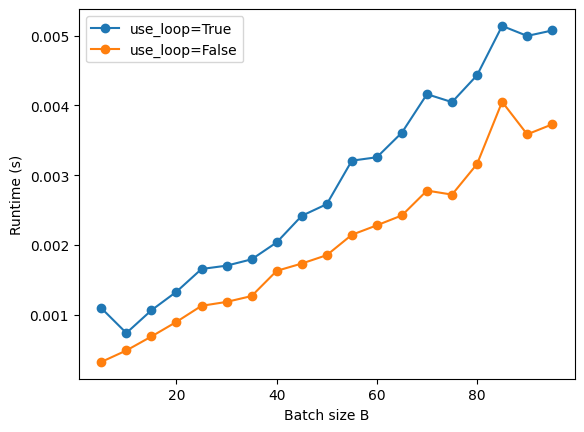

In [47]:
import time
import matplotlib.pyplot as plt
from pytorch_basic import batched_matrix_multiply

N, M, P = 100, 100, 100
loop_times = []
no_loop_times = []
Bs = list(range(5, 100, 5))
num_trials = 20
for B in Bs:
    loop_trials = []
    no_loop_trials = []
    for trial in range(num_trials):
        x = torch.randn(B, N, M)
        y = torch.randn(B, M, P)
        t0 = time.time()
        z1 = batched_matrix_multiply(x, y, use_loop=True)
        t1 = time.time()
        z2 = batched_matrix_multiply(x, y, use_loop=False)
        t2 = time.time()
        loop_trials.append(t1 - t0)
        no_loop_trials.append(t2 - t1)
    loop_mean = torch.tensor(loop_trials).mean().item()
    no_loop_mean = torch.tensor(no_loop_trials).mean().item()
    loop_times.append(loop_mean)
    no_loop_times.append(no_loop_mean)

plt.plot(Bs, loop_times, 'o-', label='use_loop=True')
plt.plot(Bs, no_loop_times, 'o-', label='use_loop=False')
plt.xlabel('Batch size B')
plt.ylabel('Runtime (s)')
plt.legend()
plt.show()

## Broadcasting

Broadcasting is a powerful mechanism that allows PyTorch to work with arrays of different shapes when performing arithmetic operations. Frequently we have a smaller tensor and a larger tensor, and we want to use the smaller tensor multiple times to perform some operation on the larger tensor.

For example, suppose that we want to add a constant vector to each row of a tensor. We could do it like this:


In [48]:
# We will add the vector v to each row of the matrix x,
# storing the result in the matrix y
x = torch.tensor([[1,2,3], [4,5,6], [7,8,9], [10, 11, 12]])
v = torch.tensor([1, 0, 1])
y = torch.zeros_like(x)   # Create an empty matrix with the same shape as x

# Add the vector v to each row of the matrix x with an explicit loop
for i in range(4):
    y[i, :] = x[i, :] + v

print(y)

tensor([[ 2,  2,  4],
        [ 5,  5,  7],
        [ 8,  8, 10],
        [11, 11, 13]])


This works; however when the tensor x is very large, computing an explicit loop in Python could be slow. Note that adding the vector v to each row of the tensor x is equivalent to forming a tensor vv by stacking multiple copies of v vertically, then performing elementwise summation of x and vv. We could implement this approach like this:


In [49]:
vv = v.repeat((4, 1))  # Stack 4 copies of v on top of each other
print(vv)              # Prints "[[1 0 1]
                       #          [1 0 1]
                       #          [1 0 1]
                       #          [1 0 1]]"

tensor([[1, 0, 1],
        [1, 0, 1],
        [1, 0, 1],
        [1, 0, 1]])


In [50]:
y = x + vv  # Add x and vv elementwise
print(y)

tensor([[ 2,  2,  4],
        [ 5,  5,  7],
        [ 8,  8, 10],
        [11, 11, 13]])


PyTorch broadcasting allows us to perform this computation without actually creating multiple copies of v. Consider this version, using broadcasting:

In [51]:
# We will add the vector v to each row of the matrix x,
# storing the result in the matrix y
x = torch.tensor([[1,2,3], [4,5,6], [7,8,9], [10, 11, 12]])
v = torch.tensor([1, 0, 1])
y = x + v  # Add v to each row of x using broadcasting
print(y)

tensor([[ 2,  2,  4],
        [ 5,  5,  7],
        [ 8,  8, 10],
        [11, 11, 13]])


The line y = x + v works even though x has shape (4, 3) and v has shape (3,) due to broadcasting; this line works as if v actually had shape (4, 3), where each row was a copy of v, and the sum was performed elementwise.

Broadcasting two tensors together follows these rules:

1.   If the tensors do not have the same rank, prepend the shape of the lower rank array with 1s until both shapes have the same length.
2.   The two tensors are said to be *compatible* in a dimension if they have the same size in the dimension, or if one of the tensors has size 1 in that dimension.
3.   The tensors can be broadcast together if they are compatible in all dimensions.
4.   After broadcasting, each tensor behaves as if it had shape equal to the elementwise maximum of shapes of the two input tensors.
5.   In any dimension where one tensor had size 1 and the other tensor had size greater than 1, the first tensor behaves as if it were copied along that dimension

If this explanation does not make sense, try reading the explanation from the [documentation](https://pytorch.org/docs/stable/notes/broadcasting.html).

Broadcasting usually happens implicitly inside many PyTorch operators. However we can also broadcast explicitly using the function [`torch.broadcast_tensors`](https://pytorch.org/docs/stable/generated/torch.broadcast_tensors.html#torch.broadcast_tensors):

In [52]:
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]])
v = torch.tensor([1, 0, 1])
print('Here is x (before broadcasting):')
print(x)
print('x.shape: ', x.shape)
print('\nHere is v (before broadcasting):')
print(v)
print('v.shape: ', v.shape)

xx, vv = torch.broadcast_tensors(x, v)
print('Here is xx (after) broadcasting):')
print(xx)
print('xx.shape: ', x.shape)
print('\nHere is vv (after broadcasting):')
print(vv)
print('vv.shape: ', vv.shape)

Here is x (before broadcasting):
tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])
x.shape:  torch.Size([4, 3])

Here is v (before broadcasting):
tensor([1, 0, 1])
v.shape:  torch.Size([3])
Here is xx (after) broadcasting):
tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])
xx.shape:  torch.Size([4, 3])

Here is vv (after broadcasting):
tensor([[1, 0, 1],
        [1, 0, 1],
        [1, 0, 1],
        [1, 0, 1]])
vv.shape:  torch.Size([4, 3])


Notice that after broadcasting, `x` remains the same but `v` has an extra dimension prepended to its shape, and it is duplicated to have the same shape as `x`; since they have the same shape after broadcasting they can be added elementwise.

Not all functions support broadcasting. You can find functions that does not support broadcasting from the official docs. (e.g. [`torch.mm`](https://pytorch.org/docs/stable/torch.html#torch.mm) does not support broadcasting, but [`torch.matmul`](https://pytorch.org/docs/1.1.0/torch.html#torch.matmul) does)

Broadcasting can let us easily implement many different operations. For example we can compute an outer product of vectors:

In [53]:
# Compute outer product of vectors
v = torch.tensor([1, 2, 3])  # v has shape (3,)
w = torch.tensor([4, 5])     # w has shape (2,)
# To compute an outer product, we first reshape v to be a column
# vector of shape (3, 1); we can then broadcast it against w to yield
# an output of shape (3, 2), which is the outer product of v and w:
print(v.view(3, 1) * w)

tensor([[ 4,  5],
        [ 8, 10],
        [12, 15]])


We can add a vector to each row of a matrix:

In [54]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])  # x has shape (2, 3)
v = torch.tensor([1, 2, 3])               # v has shape (3,)
print('Here is the matrix:')
print(x)
print('\nHere is the vector:')
print(v)

# x has shape (2, 3) and v has shape (3,) so they broadcast to (2, 3),
# giving the following matrix:
print('\nAdd the vector to each row of the matrix:')
print(x + v)

Here is the matrix:
tensor([[1, 2, 3],
        [4, 5, 6]])

Here is the vector:
tensor([1, 2, 3])

Add the vector to each row of the matrix:
tensor([[2, 4, 6],
        [5, 7, 9]])


*We* can add a vector to each column of a matrix:

In [55]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])  # x has shape (2, 3)
w = torch.tensor([4, 5])                  # w has shape (2,)
print('Here is the matrix:')
print(x)
print('\nHere is the vector:')
print(w)

# x has shape (2, 3) and w has shape (2,). We reshape w to (2, 1);
# then when we add the two the result broadcasts to (2, 3):
print('\nAdd the vector to each column of the matrix:')
print(x + w.view(-1, 1))

# Another solution is the following:
# 1. Transpose x so it has shape (3, 2)
# 2. Since w has shape (2,), adding will broadcast to (3, 2)
# 3. Transpose the result, resulting in a shape (2, 3)
print((x.t() + w).t())

Here is the matrix:
tensor([[1, 2, 3],
        [4, 5, 6]])

Here is the vector:
tensor([4, 5])

Add the vector to each column of the matrix:
tensor([[ 5,  6,  7],
        [ 9, 10, 11]])
tensor([[ 5,  6,  7],
        [ 9, 10, 11]])


Multiply a tensor by a set of constants:

In [56]:
import torch

In [57]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])  # x has shape (2, 3)
c = torch.tensor([1, 10, 11, 100])        # c has shape (4)
print('Here is the matrix:')
print(x)
print('\nHere is the vector:')
print(c)

# We do the following:
# 1. Reshape c from (4,) to (4, 1, 1)
# 2. x has shape (2, 3). Since they have different ranks, when we multiply the
#    two, x behaves as if its shape were (1, 2, 3)
# 3. The result of the broadcast multiplication between tensor of shape
#    (4, 1, 1) and (1, 2, 3) has shape (4, 2, 3)
# 4. The result y has shape (4, 2, 3), and y[i] (shape (2, 3)) is equal to
#    c[i] * x
y = c.view(-1, 1, 1) * x
print('\nMultiply x by a set of constants:')
print(y)

Here is the matrix:
tensor([[1, 2, 3],
        [4, 5, 6]])

Here is the vector:
tensor([  1,  10,  11, 100])

Multiply x by a set of constants:
tensor([[[  1,   2,   3],
         [  4,   5,   6]],

        [[ 10,  20,  30],
         [ 40,  50,  60]],

        [[ 11,  22,  33],
         [ 44,  55,  66]],

        [[100, 200, 300],
         [400, 500, 600]]])


**Your turn**: In the file `pytorch_basic.py`, implement the function `normalize_columns` that normalizes the columns of a matrix. It should compute the mean and standard deviation of each column, then subtract the mean and divide by the standard deviation for each element in the column.

Example:
```
x = [[ 0,  30,  600],
     [ 1,  10,  200],
     [-1,  20,  400]]
```
- The first column has mean 0 and std 1
- The second column has mean 20 and std 10
- The third column has mean 400 and std 200

After normalizing the columns, the result should be:
```
y = [[ 0,  1,  1],
     [ 1, -1, -1],
     [-1,  0,  0]]
```

Recall that given scalars $x_1,\ldots,x_M$ the mean $\mu$ and standard deviation $\sigma$ are given by

$$\mu=\frac{1}{M}\sum_{i=1}^M x_i \hspace{4pc} \sigma = \sqrt{\frac{1}{M-1}\sum_{i=1}^M(x_i-\mu)^2}$$

In [58]:
from pytorch_basic import normalize_columns

x = torch.tensor([[0., 30., 600.], [1., 10., 200.], [-1., 20., 400.]])
y = normalize_columns(x)
print('Here is x:')
print(x)
print('Here is y:')
print(y)

x_expected = [[0., 30., 600.], [1., 10., 200.], [-1., 20., 400.]]
y_expected = [[0., 1., 1.], [1., -1., -1.], [-1., 0., 0.]]
y_correct = y.tolist() == y_expected
x_correct = x.tolist() == x_expected
print('y correct: ', y_correct)
print('x unchanged: ', x_correct)

Here is x:
tensor([[  0.,  30., 600.],
        [  1.,  10., 200.],
        [ -1.,  20., 400.]])
Here is y:
tensor([[ 0.0000,  0.1000,  0.0050],
        [ 1.0000, -0.1000, -0.0050],
        [-1.0000,  0.0000,  0.0000]])
y correct:  False
x unchanged:  True


### Out-of-place vs in-place operators
Most PyTorch operators are classified into one of two categories:
- **Out-of-place operators:** return a new tensor. Most PyTorch operators behave this way.
- **In-place operators:** modify and return the input tensor. Instance methods that end with an underscore (such as `add_()` are in-place. Operators in the `torch` namespace can be made in-place using the `out=` keyword argument.

For example:

In [59]:
# Out-of-place addition creates and returns a new tensor without modifying the inputs:
x = torch.tensor([1, 2, 3])
y = torch.tensor([3, 4, 5])
print('Out-of-place addition:')
print('Before addition:')
print('x: ', x)
print('y: ', y)
z = x.add(y)  # Same as z = x + y or z = torch.add(x, y)
print('\nAfter addition (x and y unchanged):')
print('x: ', x)
print('y: ', y)
print('z: ', z)
print('z is x: ', z is x)
print('z is y: ', z is y)

# In-place addition modifies the input tensor:
print('\n\nIn-place Addition:')
print('Before addition:')
print('x: ', x)
print('y: ', y)
x.add_(y)  # Same as x += y or torch.add(x, y, out=x)
print('\nAfter addition (x is modified):')
print('x: ', x)
print('y: ', y)
print('z: ', z)
print('z is x: ', z is x)
print('z is y: ', z is y)

Out-of-place addition:
Before addition:
x:  tensor([1, 2, 3])
y:  tensor([3, 4, 5])

After addition (x and y unchanged):
x:  tensor([1, 2, 3])
y:  tensor([3, 4, 5])
z:  tensor([4, 6, 8])
z is x:  False
z is y:  False


In-place Addition:
Before addition:
x:  tensor([1, 2, 3])
y:  tensor([3, 4, 5])

After addition (x is modified):
x:  tensor([4, 6, 8])
y:  tensor([3, 4, 5])
z:  tensor([4, 6, 8])
z is x:  False
z is y:  False


In general, **you should avoid in-place operations** since they can cause problems when computing gradients using autograd (which we will cover in a future assignment).

## Running on GPU

One of the most important features of PyTorch is that it can use graphics processing units (GPUs) to accelerate its tensor operations.

We can easily check whether PyTorch is configured to use GPUs:

Tensors can be moved onto any device using the .to method.

In [60]:
import torch

if torch.cuda.is_available:
  print('PyTorch can use GPUs!')
else:
  print('PyTorch cannot use GPUs.')

PyTorch can use GPUs!


You can enable GPUs in Colab via Runtime -> Change Runtime Type -> Hardware Accelerator -> GPU.

This may cause the Colab runtime to restart, so we will re-import torch in the next cell.

We have already seen that PyTorch tensors have a `dtype` attribute specifying their datatype. All PyTorch tensors also have a `device` attribute that specifies the device where the tensor is stored -- either CPU, or CUDA (for NVIDA GPUs). A tensor on a CUDA device will automatically use that device to accelerate all of its operations.

Just as with datatypes, we can use the [`.to()`](https://pytorch.org/docs/1.1.0/tensors.html#torch.Tensor.to) method to change the device of a tensor. We can also use the convenience methods `.cuda()` and `.cpu()` methods to move tensors between CPU and GPU.

In [61]:
# Construct a tensor on the CPU
x0 = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
print('x0 device:', x0.device)

# Move it to the GPU using .to()
x1 = x0.to('cuda')
print('x1 device:', x1.device)

# Move it to the GPU using .cuda()
x2 = x0.cuda()
print('x2 device:', x2.device)

# Move it back to the CPU using .to()
x3 = x1.to('cpu')
print('x3 device:', x3.device)

# Move it back to the CPU using .cpu()
x4 = x2.cpu()
print('x4 device:', x4.device)

# We can construct tensors directly on the GPU as well
y = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float64, device='cuda')
print('y device / dtype:', y.device, y.dtype)

# Calling x.to(y) where y is a tensor will return a copy of x with the same
# device and dtype as y
x5 = x0.to(y)
print('x5 device / dtype:', x5.device, x5.dtype)

x0 device: cpu
x1 device: cuda:0
x2 device: cuda:0
x3 device: cpu
x4 device: cpu
y device / dtype: cuda:0 torch.float64
x5 device / dtype: cuda:0 torch.float64


Performing large tensor operations on a GPU can be **a lot faster** than running the equivalent operation on CPU.

Here we compare the speed of adding two tensors of shape (10000, 10000) on CPU and GPU:

(Note that GPU code may run asynchronously with CPU code, so when timing the speed of operations on the GPU it is important to use `torch.cuda.synchronize` to synchronize the CPU and GPU.)

In [62]:
import time

a_cpu = torch.randn(10000, 10000, dtype=torch.float32)
b_cpu = torch.randn(10000, 10000, dtype=torch.float32)

a_gpu = a_cpu.cuda()
b_gpu = b_cpu.cuda()
torch.cuda.synchronize()

t0 = time.time()
c_cpu = a_cpu + b_cpu
t1 = time.time()
c_gpu = a_gpu + b_gpu
torch.cuda.synchronize()
t2 = time.time()

# Check that they computed the same thing
diff = (c_gpu.cpu() - c_cpu).abs().max().item()
print('Max difference between c_gpu and c_cpu:', diff)

cpu_time = 1000.0 * (t1 - t0)
gpu_time = 1000.0 * (t2 - t1)
print('CPU time: %.2f ms' % cpu_time)
print('GPU time: %.2f ms' % gpu_time)
print('GPU speedup: %.2f x' % (cpu_time / gpu_time))

Max difference between c_gpu and c_cpu: 0.0
CPU time: 335.60 ms
GPU time: 57.37 ms
GPU speedup: 5.85 x


You should see that running the same computation on the GPU was more than 10~30 times faster than on the CPU! Due to the massive speedups that GPUs offer, we will use GPUs to accelerate much of our machine learning code starting in Assignment 2.

**Your turn**: Use the GPU to accelerate the following matrix multiplication operation. You should see 5~10x speedup by using the GPU.

In [63]:
import time
from pytorch_basic import mm_on_cpu, mm_on_gpu

x = torch.rand(512, 4096)
w = torch.rand(4096, 4096)

t0 = time.time()
y0 = mm_on_cpu(x, w)
t1 = time.time()

y1 = mm_on_gpu(x, w)
torch.cuda.synchronize()
t2 = time.time()

print('y1 on CPU:', y1.device == torch.device('cpu'))
diff = (y0 - y1).abs().max().item()
print('Max difference between y0 and y1:', diff)
print('Difference within tolerance:', diff < 5e-2)

cpu_time = 1000.0 * (t1 - t0)
gpu_time = 1000.0 * (t2 - t1)
print('CPU time: %.2f ms' % cpu_time)
print('GPU time: %.2f ms' % gpu_time)
print('GPU speedup: %.2f x' % (cpu_time / gpu_time))

y1 on CPU: True
Max difference between y0 and y1: 0.001220703125
Difference within tolerance: True
CPU time: 235.94 ms
GPU time: 163.80 ms
GPU speedup: 1.44 x


## Data Loader



PyTorch has two classes from [`torch.utils.data` to work with data](https://pytorch.org/docs/stable/data.html#module-torch.utils.data):
- [Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) which represents the actual data items, such as images or pieces of text, and their labels
- [DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) which is used for processing the dataset in batches in an efficient manner.

It provides:

* Batching: Automatically groups samples into batches.
* Shuffling: Randomly shuffles data at every epoch.
* Parallel Loading: Uses multiple workers for faster data loading.
* Transformation Support: Applies transformations to data on the fly.

PyTorch has domain-specific libraries with utilities for common data types such as [TorchText](https://pytorch.org/text/stable/index.html), [TorchVision](https://pytorch.org/vision/stable/index.html) and [TorchAudio](https://pytorch.org/audio/stable/index.html).

## Using DataLoader with MNIST

Here we will use TorchVision and `torchvision.datasets` which provides easy access to [many common visual datasets](https://pytorch.org/vision/stable/datasets.html). In this example we'll use the [MNIST class](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) for loading the [MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database).


Let's implement a simple example using the MNIST dataset and visualize some images.

In [67]:
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision import datasets
import matplotlib.pyplot as plt

# TODO:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root="/content/drive/MyDrive/DL_HW1/data_MNIST", train=True, download=True, transform=transform)

dataloader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=2)

data_iter = iter(dataloader)
images, labels = next(data_iter)



# Define transformations (ToTensor and Normalize to range [-1,1])
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load MNIST dataset
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=2)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.03MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.97MB/s]


In [68]:
# Print information about train_loader
print("Train DataLoader Information:")
print("Number of batches:", len(dataloader))
print("Batch size:", dataloader.batch_size)
data_batch, target_batch = next(iter(dataloader))
print("Shape of data tensor in next batch:", data_batch.shape)
print("Shape of target tensor in next batch:", target_batch.shape)
print("Target values in next batch:", target_batch)


Train DataLoader Information:
Number of batches: 7500
Batch size: 8
Shape of data tensor in next batch: torch.Size([8, 1, 28, 28])
Shape of target tensor in next batch: torch.Size([8])
Target values in next batch: tensor([1, 9, 8, 7, 0, 5, 5, 4])


The shape of images is: torch.Size([8, 1, 28, 28])


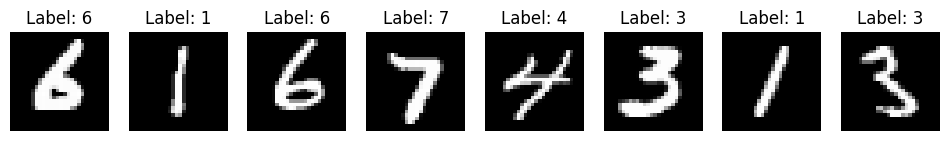

In [69]:
# Get one batch
dataiter = iter(dataloader)
images, labels = next(dataiter)
print('The shape of images is:',images.shape)

# Display the batch

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")
plt.show()


## CIFAR-10 Dataset
The CIFAR-10 dataset is a widely used dataset for training machine learning and computer vision models. It consists of **60,000 color images** in **10 classes**, with **6,000 images per class**. The dataset is divided into **50,000 training images** and **10,000 test images**. Each image is **32x32 pixels** and comes in **RGB format**.

### Classes
The CIFAR-10 dataset contains the following **10 mutually exclusive classes**:

1. Airplane
2. Automobile
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck

Each class has **6,000 images** distributed across the training and test sets.


### Dataset Properties
- **Number of Classes:** 10
- **Number of Images:** 60,000 (50,000 training + 10,000 test)
- **Image Size:** 32x32 pixels
- **Color Channels:** RGB (3 channels)
- **Format:** `.png` images stored in Python `pickle` format


### Applications
The CIFAR-10 dataset is widely used for:
- Image classification tasks
- Benchmarking deep learning models
- Testing convolutional neural networks (CNNs)
- Transfer learning research

### References
- [CIFAR-10 Official Website](https://www.cs.toronto.edu/~kriz/cifar.html)
- [Torchvision Documentation](https://pytorch.org/vision/stable/datasets.html#cifar10)


### Usage in `torchvision.datasets`
CIFAR-10 is available in the `torchvision.datasets` module and can be easily loaded in PyTorch.

In [70]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load training and test datasets
trainset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
testset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

# Create DataLoaders
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:13<00:00, 13.0MB/s]


### Example Visualization
To visualize some sample images from the dataset, use the following code:


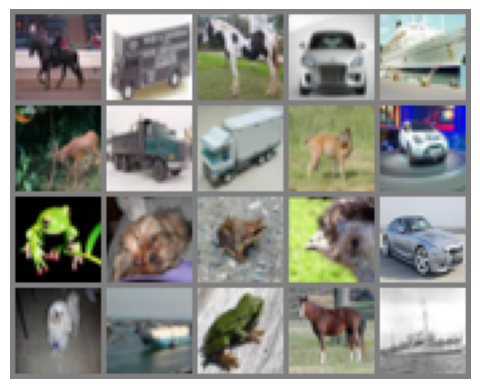

horse    truck    horse    automobile    ship
deer    truck    truck    deer    automobile
frog    dog    frog    bird    automobile
dog    ship    frog    horse    ship


In [71]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid

# Define class labels
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Function to unnormalize and display images
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)
N = 20
rows = 4
# Show images
imshow(make_grid(images[:N], N//rows))
# Print class labels
for i in range(rows):
    print('    '.join(classes[labels[j + i*(N//rows)]] for j in range(N//rows)))

In [72]:
# Print information about train_loader
print("Train DataLoader Information:")
print("Number of batches:", len(trainloader))
print("Batch size:", trainloader.batch_size)
data_batch, target_batch = next(iter(trainloader))
print("Shape of data tensor in next batch:", data_batch.shape)
print("Shape of target tensor in next batch:", target_batch.shape)
print("Target values in next batch:", target_batch)


Train DataLoader Information:
Number of batches: 782
Batch size: 64
Shape of data tensor in next batch: torch.Size([64, 3, 32, 32])
Shape of target tensor in next batch: torch.Size([64])
Target values in next batch: tensor([9, 8, 3, 0, 6, 0, 2, 3, 0, 0, 7, 6, 0, 6, 9, 7, 2, 4, 9, 1, 0, 3, 3, 7,
        1, 4, 4, 6, 8, 6, 1, 4, 9, 0, 3, 5, 0, 6, 6, 3, 8, 1, 5, 0, 4, 7, 3, 9,
        8, 2, 1, 8, 0, 0, 3, 9, 9, 1, 2, 2, 0, 7, 0, 4])


## Save Models!


Saving and loading models is a crucial part of deep learning workflows. PyTorch provides flexible mechanisms to save and load models, whether you need to save the entire model, just the model parameters (state_dict), or both. This guide covers different methods for saving and loading PyTorch models efficiently.

### 1. Saving and Loading Model State Dict (Recommended)

The most common and recommended way to save a PyTorch model is to save its `state_dict`, which contains all the learnable parameters.


In [87]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define a simple model
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc1 = nn.Linear(10, 5)

    def forward(self, x):
        return self.fc1(x)

model = SimpleModel()

# Save the model state dict
torch.save(model.state_dict(), "model_state.pth")



In [88]:
# load the model from disk

model_loaded = SimpleModel()
model_loaded.load_state_dict(torch.load("model_state.pth"))

# Set the model to evaluation mode (important for inference)
model_loaded.eval()

SimpleModel(
  (fc1): Linear(in_features=10, out_features=5, bias=True)
)

### 2. Saving and Loading the Entire Model

You can also save the entire model, including the model architecture and parameters. However, this method is less flexible and may cause compatibility issues when loading the model in different environments.


In [89]:
# save the entire model
torch.save(model, "entire_model.pth")

In [91]:
# load the entire model
model_loaded = torch.load("/content/entire_model.pth",weights_only=False)
model_loaded.eval()

SimpleModel(
  (fc1): Linear(in_features=10, out_features=5, bias=True)
)

### 3. Saving and Loading Model with Optimizer State

When training deep learning models, saving the optimizer state along with the model can be useful for resuming training without losing progress.


In [92]:
optimizer = optim.SGD(model.parameters(), lr=0.01)

checkpoint = {
    'epoch': 10,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}

torch.save(checkpoint, "model_checkpoint.pth")

In [93]:
checkpoint = torch.load("model_checkpoint.pth")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']

# Set to evaluation mode if needed
model.eval()

SimpleModel(
  (fc1): Linear(in_features=10, out_features=5, bias=True)
)

### 4. Best Practices for Saving and Loading Models

- **Use `.state_dict()` method** for saving and loading models whenever possible.
- **Save additional metadata** like epoch, loss, and optimizer state when saving models for resuming training.
- **Use relative paths** instead of absolute paths to avoid compatibility issues.
- **Set the model to `.eval()` mode** when performing inference to ensure proper behavior of layers like dropout and batch normalization.
- **Ensure compatibility** when loading models by using the same model architecture and PyTorch version.


Now you know all the necessary background knowledge to start training the models that you like :)


Lets try it!

# NOW WE WANT TO TRAIN ON A VERY SIMPLE 1D FUNCTION TO SEE HOW NEURAL NETWORKS WORK (20 points)

In this notebook, we will train a neural network to approximate a **simple 1D function**. Instead of using a standard dataset like CIFAR or MNIST, we generate synthetic data from a known mathematical function.

Our chosen function is:
$$
f(x) = e^{-x^2} \sin(10x)
$$
This function exhibits **high-frequency oscillations near \( x = 0 \)** and decays smoothly as \( x \) moves away. The goal is to train a neural network to learn this function **purely from noisy samples**, demonstrating how neural networks approximate complex patterns.

We will:
- **Generate training data** with added noise.
- **Define a simple neural network** in PyTorch.
- **Train the network** using gradient descent.
- **Visualize** how the model learns step by step.

Let’s get started! 🚀


In [94]:

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset


def true_function_1(x):
    # TODO: Define the true function
    return np.exp(-x**2) * np.sin(10 * x)
    # End of TODO



# General function to plot any function in a given domain
def plot_function(func, domain=(-2, 2), num_points=400, title="Function Plot", label="Function", color="b"):
    x_values = np.linspace(domain[0], domain[1], num_points)
    y_values = func(x_values)

    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, label=label, color=color, linewidth=2)
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()



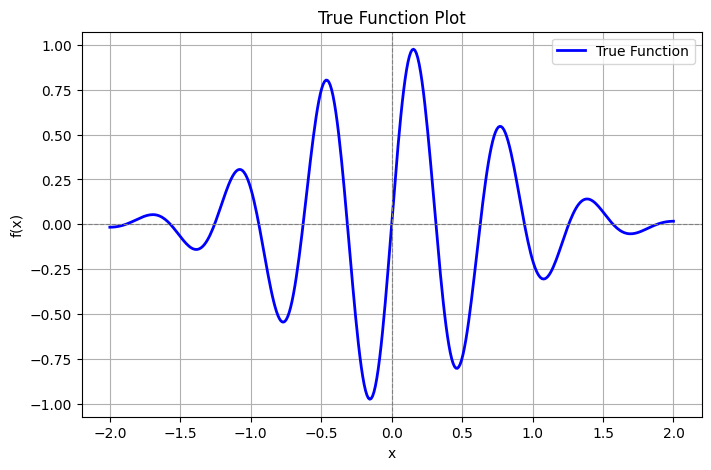

In [95]:
# TODO: Plot the true function
plot_function(true_function_1, domain=(-2, 2), num_points=400, title="True Function Plot", label="True Function", color="b")
# End of TODO

## Generating Training Data

To train our neural network, we need to create a **dataset** from our function.

### Steps:
1. **Sample random points** from the domain $ x \in [-2,2]  $.
2. **Evaluate** the true function $ f(x) = e^{-x^2} \sin(10x) $ at these points.
3. **Add Gaussian noise** to simulate real-world data imperfections.

This noisy dataset will be used to train the neural network. Below is the implementation.


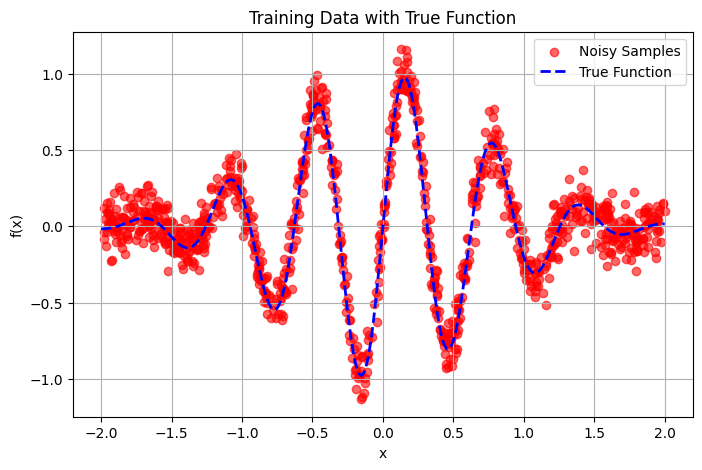

In [96]:
import torch

# Function to generate training data
def generate_training_data(true_func, num_samples=1000, noise_std=0.1, domain=(-2, 2)):
    np.random.seed(42)
    torch.manual_seed(42)

    x_train = np.random.uniform(domain[0], domain[1], num_samples)  # Randomly sample x values
    y_train = true_func(x_train) + np.random.normal(0, noise_std, num_samples)  # Add Gaussian noise

    # Convert to PyTorch tensors
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32).view(-1, 1)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    return x_train_tensor, y_train_tensor, x_train, y_train

# Function to plot training data alongside the true function
def plot_training_data(x_train, y_train, true_func, domain=(-2, 2), num_points=400):
    x_values = np.linspace(domain[0], domain[1], num_points)
    y_values = true_func(x_values)

    plt.figure(figsize=(8, 5))
    plt.scatter(x_train, y_train, color="r", label="Noisy Samples", alpha=0.6)
    plt.plot(x_values, y_values, label="True Function", color="b", linestyle="dashed", linewidth=2)
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title("Training Data with True Function")
    plt.legend()
    plt.grid(True)
    plt.show()

# Generate and plot data
x_train_tensor, y_train_tensor, x_train, y_train = generate_training_data(true_function_1)
plot_training_data(x_train, y_train, true_function_1)


## Defining the Neural Network Model

Now that we have our training data, we need to create a **neural network** to learn the function.

### Architecture:
- **Input Layer:** 1 neuron (since our input $ x $ is 1D).
- **Hidden Layers:** Two fully connected layers with 32 neurons each.
- **Activation Function:** ReLU (helps model non-linearity).
- **Output Layer:** 1 neuron (predicts $ y $).

This is a **simple feedforward network** that should be able to approximate the function. Below is the implementation.


In [97]:
import torch.nn as nn
import torch.optim as optim

# Define the neural network model
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, output_dim=1):
        super(NeuralNetwork, self).__init__()
        # TODO: init the layers
        # Input -> Hidden Layer 1
        # Hidden Layer 1 -> Hidden Layer 2
        # Hidden Layer 2 -> Output
        # ReLU activation function

        self.hidden1 = nn.Linear(input_dim, hidden_dim)
        self.hidden2 = nn.Linear(hidden_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)

        #ReLU
        self.relu = nn.ReLU()
        # End of TODO


    def forward(self, x):
        # TODO: Implement the forward function.
        # note: No activation in final layer (for regression)


        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        x = self.output(x)
        return x
        # End of TODO


# Initialize the model
model = NeuralNetwork()


criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Print model summary
print(model)


NeuralNetwork(
  (hidden1): Linear(in_features=1, out_features=32, bias=True)
  (hidden2): Linear(in_features=32, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)


## Training the Neural Network

Now that we have defined our model, we need to train it using our dataset.

### Training Process:
1. **Use mini-batches** to train the model efficiently.
2. **Compute the loss** using Mean Squared Error (MSE).
3. **Backpropagate the gradients** to update model weights.
4. **Monitor training progress** by plotting the function every few epochs.

We define a function `train_model()` to handle the entire training process and update the model iteratively.


In [98]:
def plot_learned_function(model, epoch, loss, true_function ,domain=(-2, 2), num_points=400 ):
    x_values = np.linspace(domain[0], domain[1], num_points)
    x_tensor = torch.tensor(x_values, dtype=torch.float32).view(-1, 1)

    with torch.no_grad():
        y_pred = model(x_tensor).numpy()

    plt.figure(figsize=(8, 5))
    plt.scatter(x_train, y_train, color="r", label="Noisy Samples", alpha=0.6)
    plt.plot(x_values, true_function(x_values), label="True Function", color="b", linestyle="dashed", linewidth=2)
    plt.plot(x_values, y_pred, label=f"Learned Function (Epoch {epoch})", color="g", linewidth=3)  # Thicker line
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title(f"Function Approximation at Epoch {epoch} (Loss: {loss:.6f})")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_loss_curve(loss_history):
    plt.figure(figsize=(8, 5))
    plt.plot(loss_history, label="Training Loss", color="r", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve During Training (Final Loss: {loss_history[-1]:.6f})")
    plt.legend()
    plt.grid(True)

    # Annotate final loss
    plt.text(len(loss_history) * 0.8, loss_history[-1] * 1.1,
             f"Final Loss: {loss_history[-1]:.6f}", fontsize=12, color="black")

    plt.show()


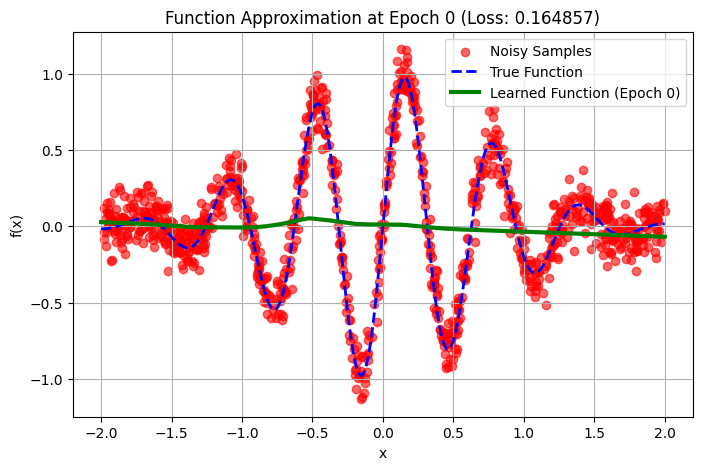

Epoch [1/10], Loss: 0.164857


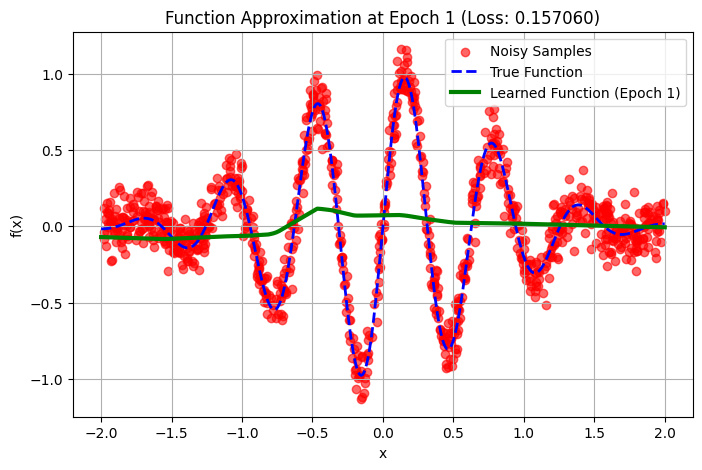

Epoch [2/10], Loss: 0.157060


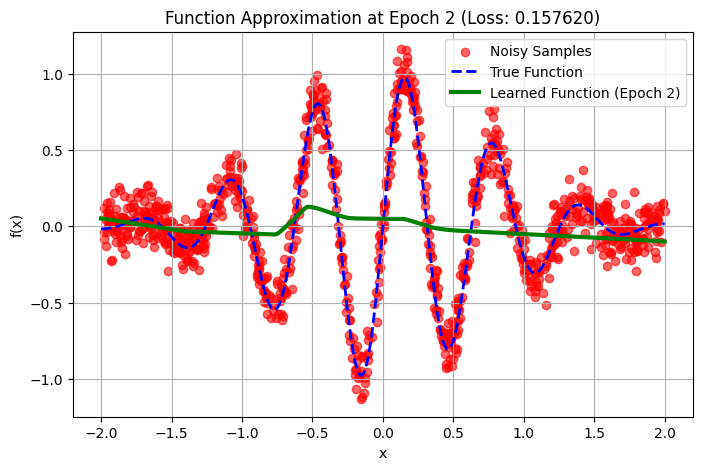

Epoch [3/10], Loss: 0.157620


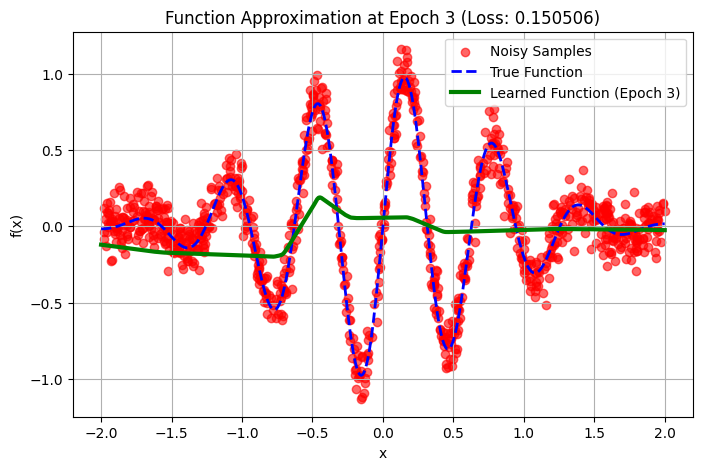

Epoch [4/10], Loss: 0.150506


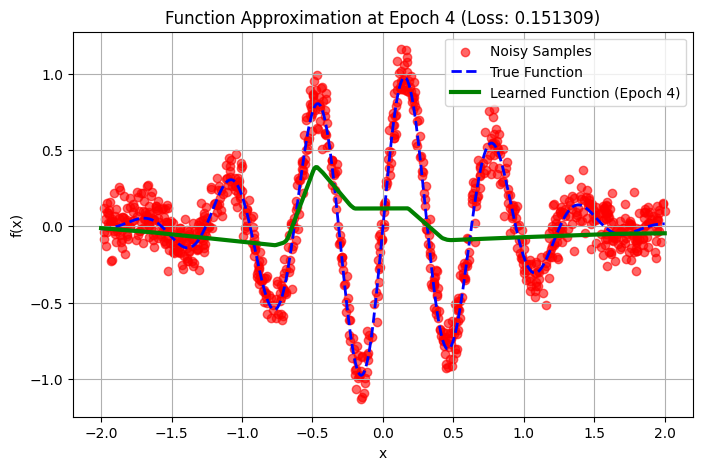

Epoch [5/10], Loss: 0.151309


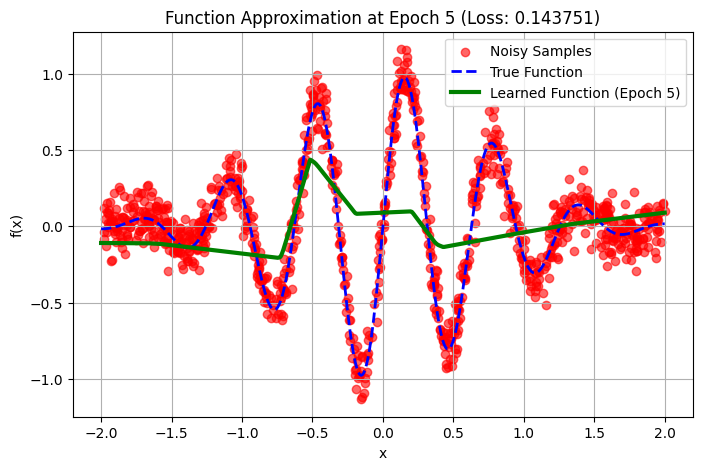

Epoch [6/10], Loss: 0.143751


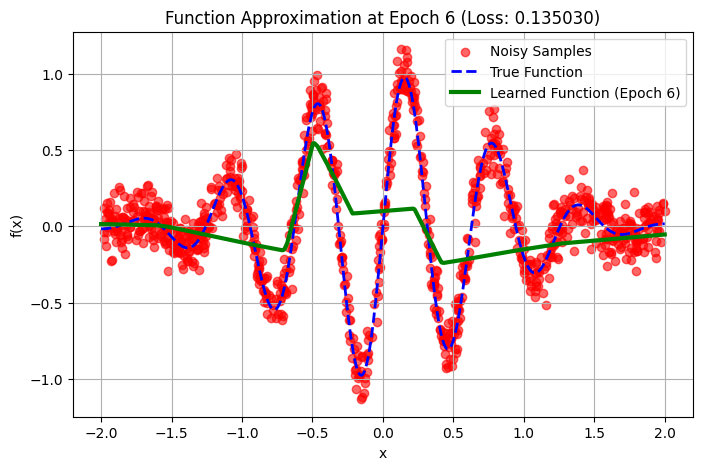

Epoch [7/10], Loss: 0.135030


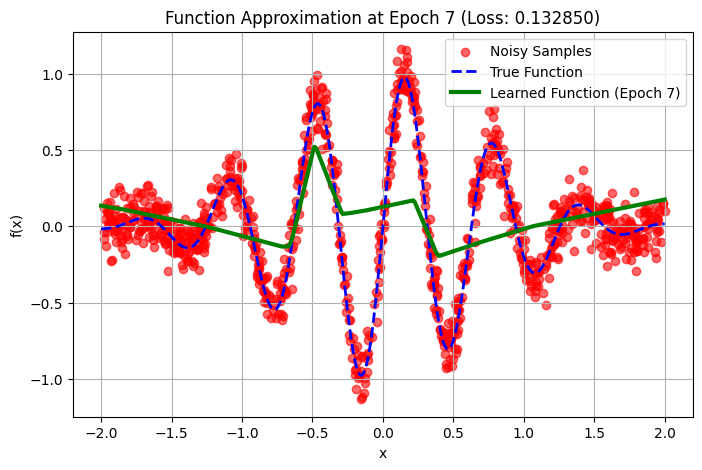

Epoch [8/10], Loss: 0.132850


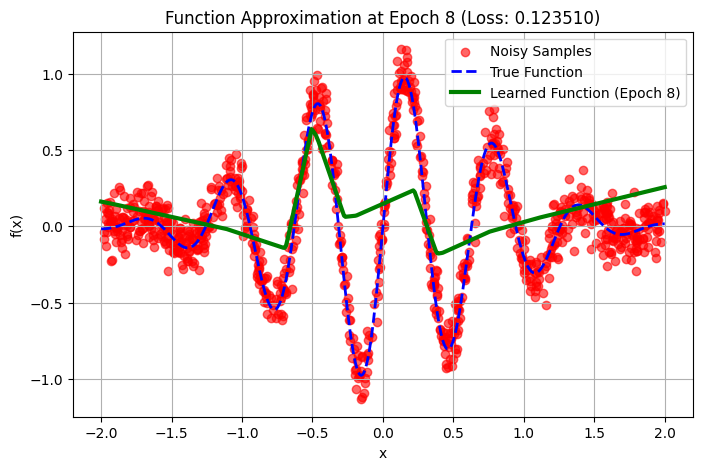

Epoch [9/10], Loss: 0.123510


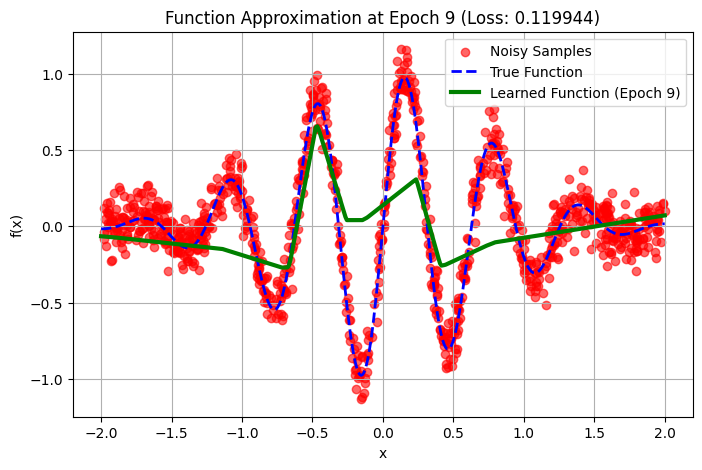

Epoch [10/10], Loss: 0.119944


In [99]:
# Function to train the model
def train_model(model, x_train_tensor, y_train_tensor, true_function_1, num_epochs=10, batch_size=32, lr=0.01, plot_interval=1):

    # TODO: Define loss function and optimizer.

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Create the proper DataLoader.
    train_dataset = torch.utils.data.TensorDataset(x_train_tensor, y_train_tensor)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # End of TODO


    loss_history = []  # Store loss values for visualization

    # Training loop
    for epoch in range(num_epochs):

        epoch_loss = 0.0
        loss_max = 10000

        for batch_x, batch_y in train_loader:
          # TODO: Forward pass and backpropagate
          y_hat = model(batch_x)

          loss = criterion(y_hat, batch_y)

          optimizer.zero_grad()

          loss.backward()

          optimizer.step()

          epoch_loss += loss.item()
          # End of TODO




        # TODO: Store average loss in loss_histor
        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)
        # End of TODO

        # TODO: Plot function every 'plot_interval' epochs. And Print progress
        # every 100 epochs
        if epoch % plot_interval == 0:
            plot_learned_function(model, epoch, avg_loss, true_function_1)

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}")

        # End of TODO


    return loss_history

# Train the model and store loss history
loss_history = train_model(model, x_train_tensor, y_train_tensor , true_function_1)




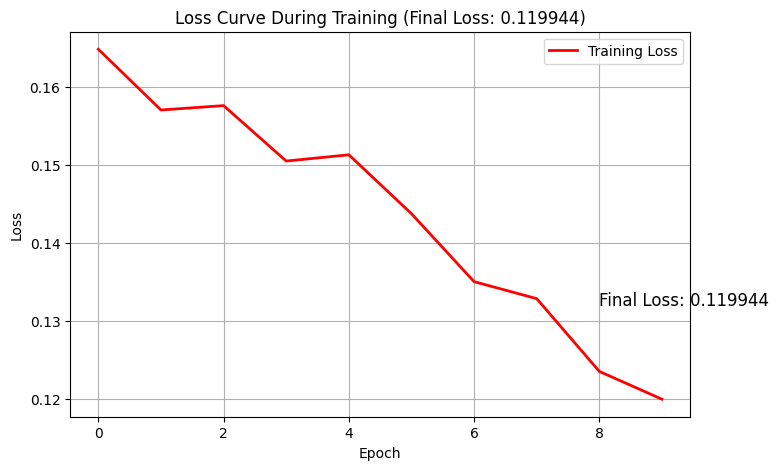

In [100]:
# Plot the loss curve
plot_loss_curve(loss_history)

In [101]:
# Define two new non-sinusoidal mathematical functions
def function_1(x):
    return np.exp(-x**2)  # Gaussian Bell Curve

def function_2(x):
    return 0.5 * x**3 - x**2 + 0.5 * x  # Cubic Polynomial


In [ ]:
# TODO: Train on Gaussian Bell Curve
# generate data - plot data - create model - train model - plot loss

x_train_tensor, y_train_tensor, x_train, y_train = generate_training_data(function_1)
plot_training_data(x_train, y_train, function_1)

x = np.arange(-2,2,0.01).reshape(-1, 1)
y = function_1(x)



x_train_tensor_1 = torch.tensor(x,dtype = torch.float32)
y_train_tensor_1 = torch.tensor(y,dtype = torch.float32)

model = NeuralNetwork()

loss_history = train_model(model, x_train_tensor_1, y_train_tensor_1,function_1, num_epochs=20, batch_size=32, lr=0.001, plot_interval=1 )


plot_loss_curve(loss_history)
# End of TODO

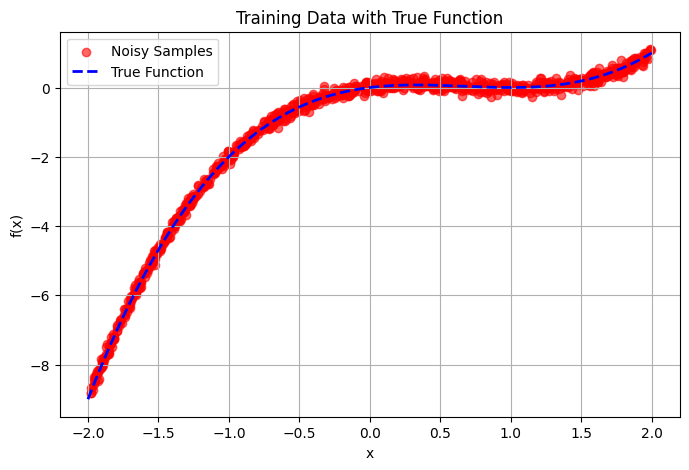

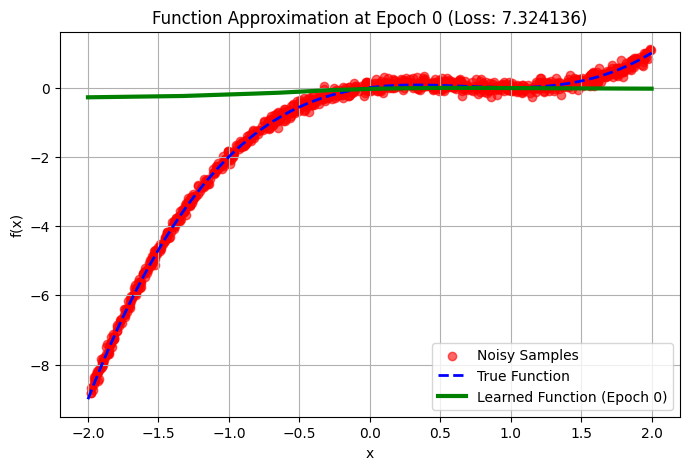

Epoch [1/20], Loss: 7.324136


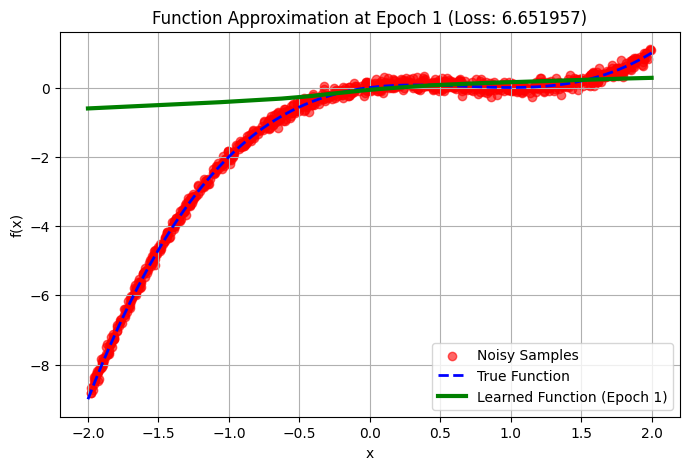

Epoch [2/20], Loss: 6.651957


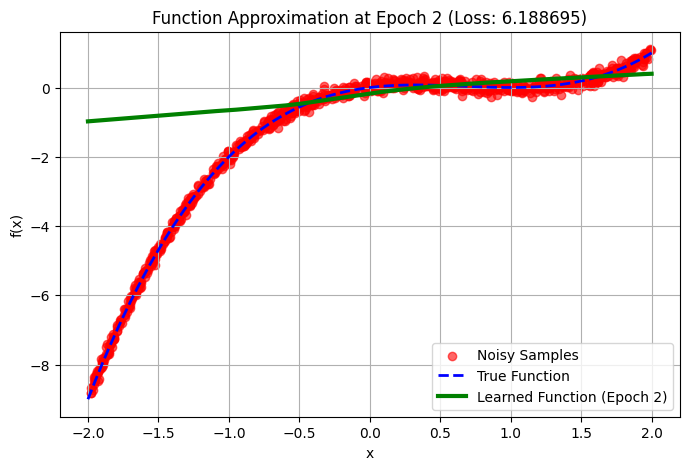

Epoch [3/20], Loss: 6.188695


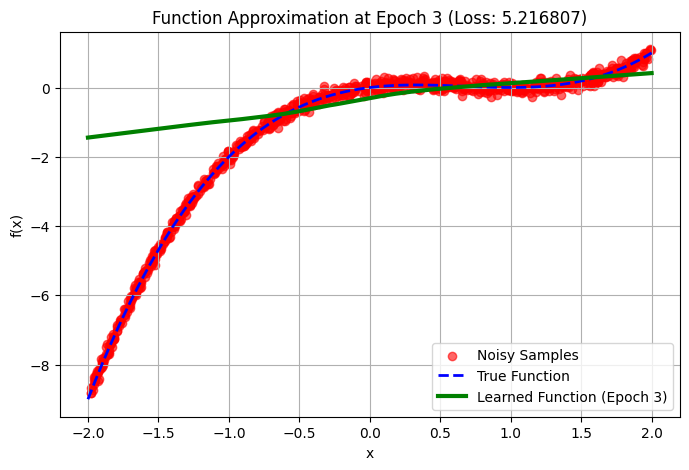

Epoch [4/20], Loss: 5.216807


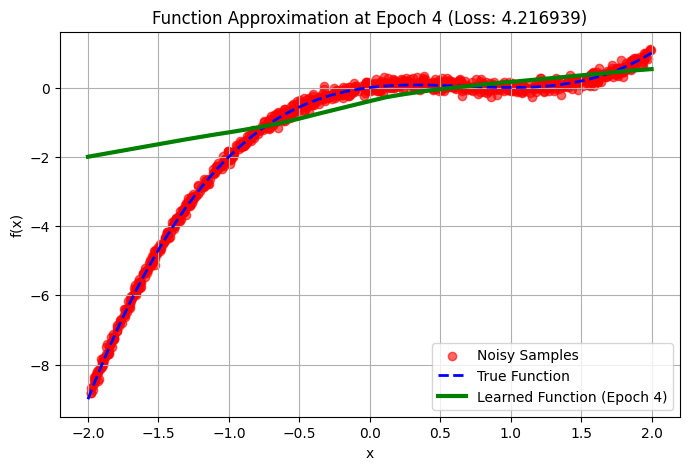

Epoch [5/20], Loss: 4.216939


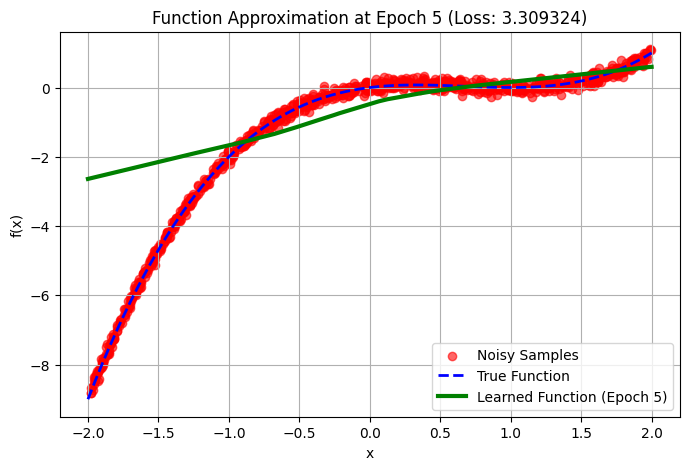

Epoch [6/20], Loss: 3.309324


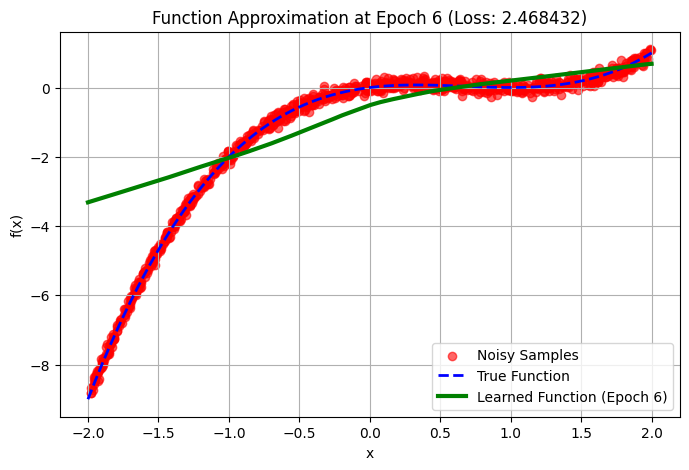

Epoch [7/20], Loss: 2.468432


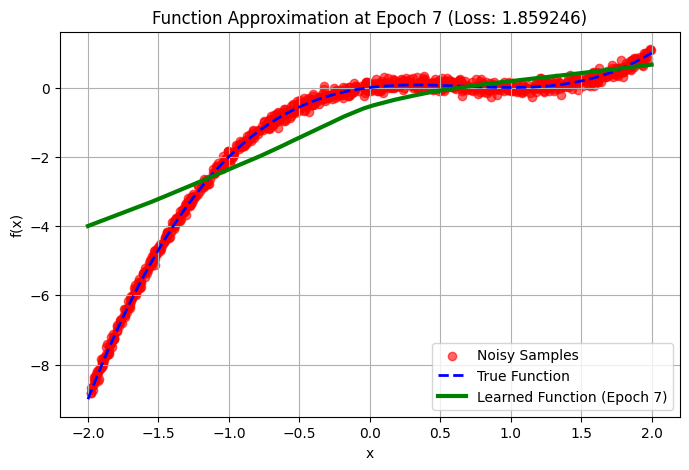

Epoch [8/20], Loss: 1.859246


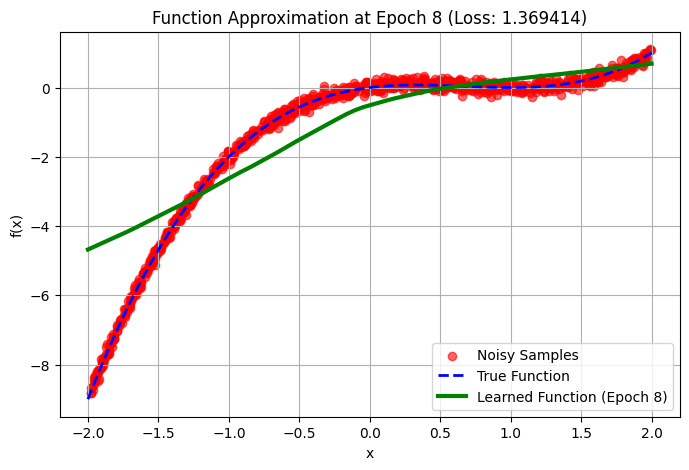

Epoch [9/20], Loss: 1.369414


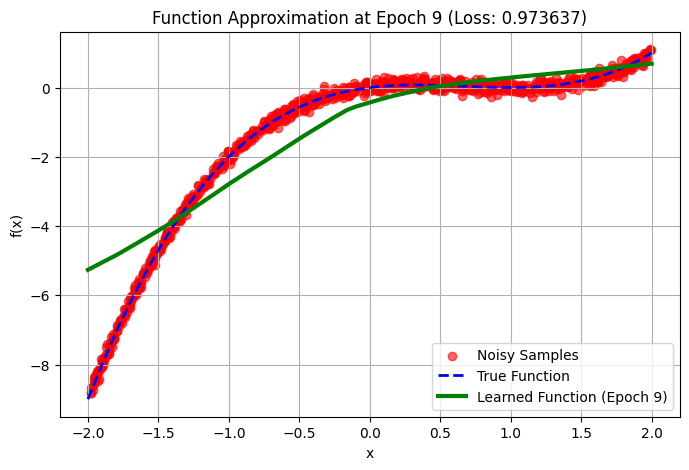

Epoch [10/20], Loss: 0.973637


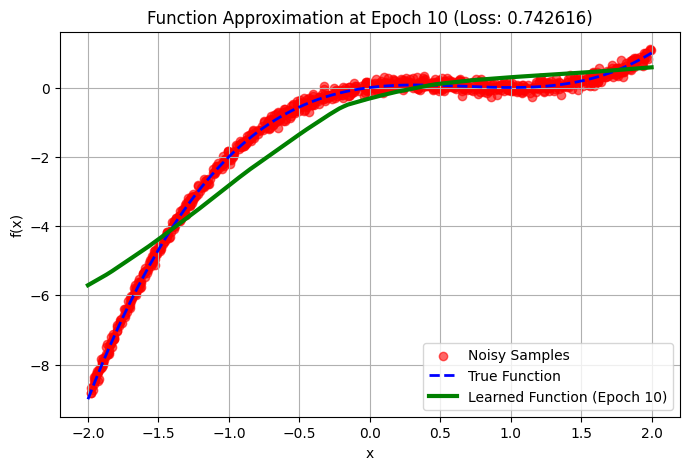

Epoch [11/20], Loss: 0.742616


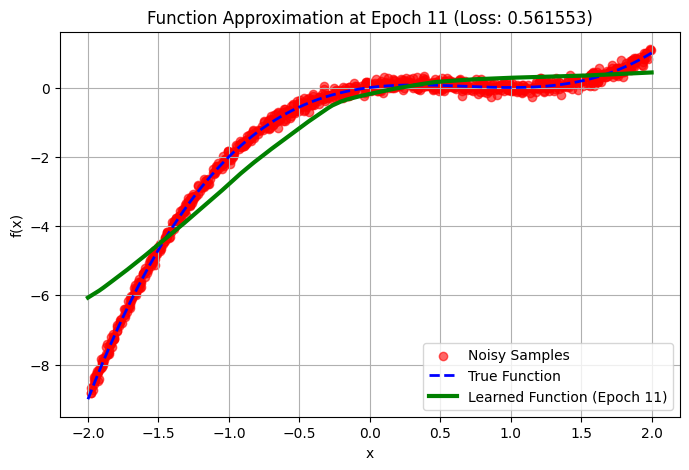

Epoch [12/20], Loss: 0.561553


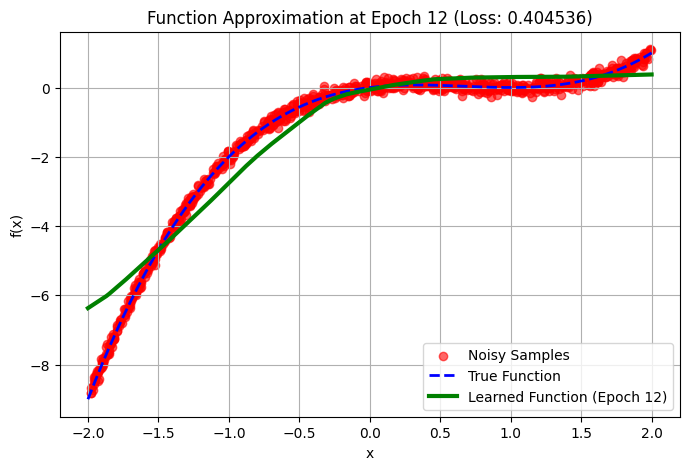

Epoch [13/20], Loss: 0.404536


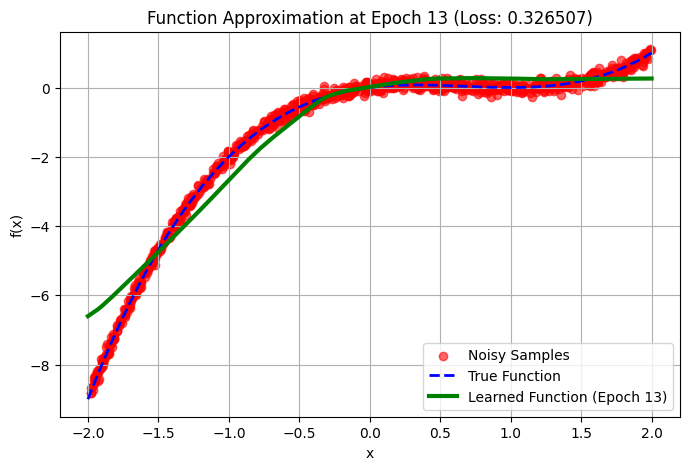

Epoch [14/20], Loss: 0.326507


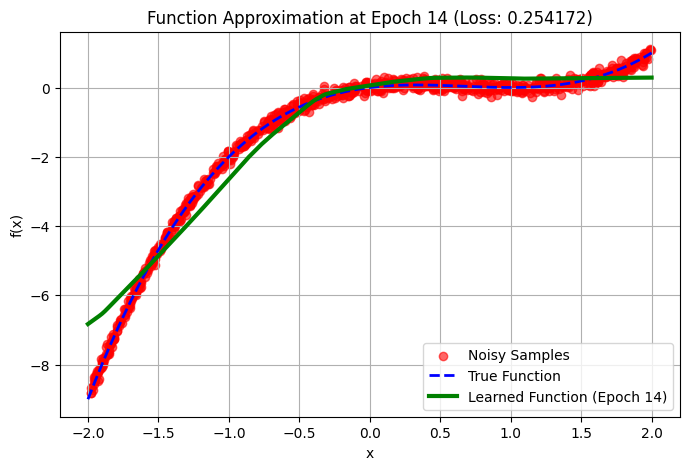

Epoch [15/20], Loss: 0.254172


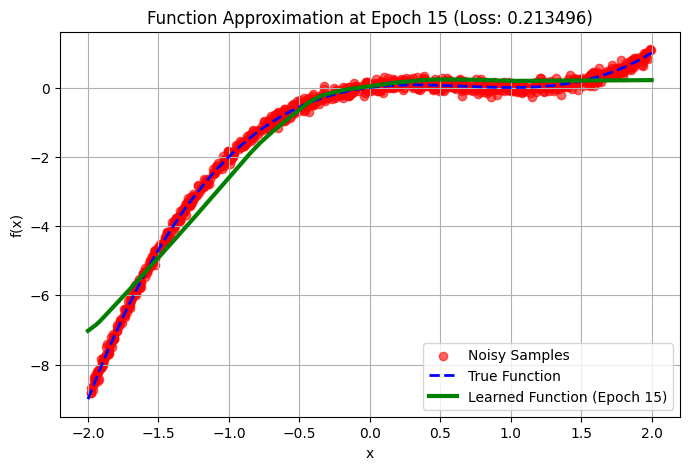

Epoch [16/20], Loss: 0.213496


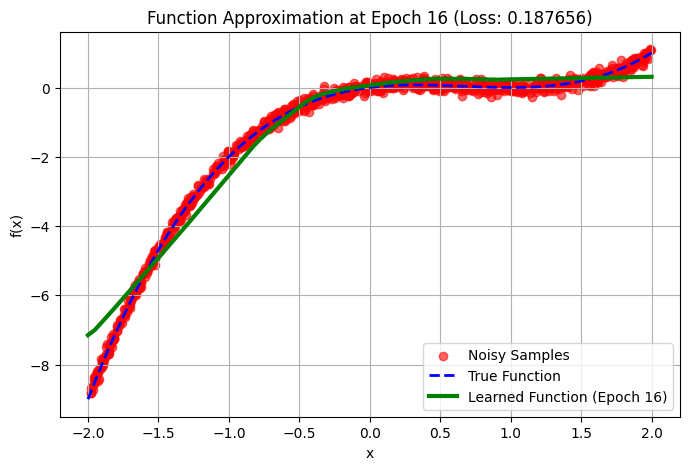

Epoch [17/20], Loss: 0.187656


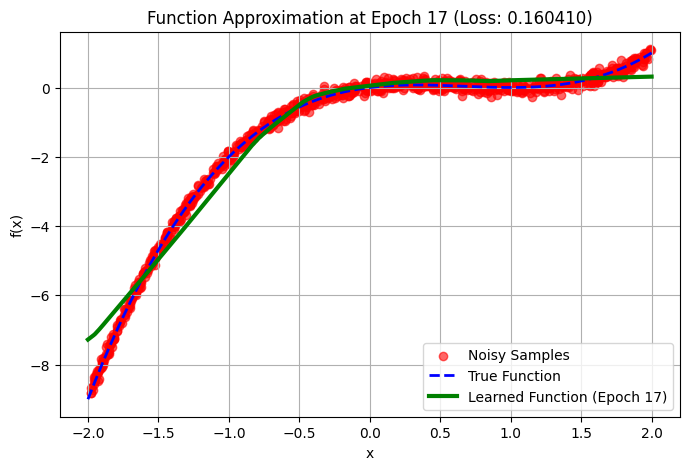

Epoch [18/20], Loss: 0.160410


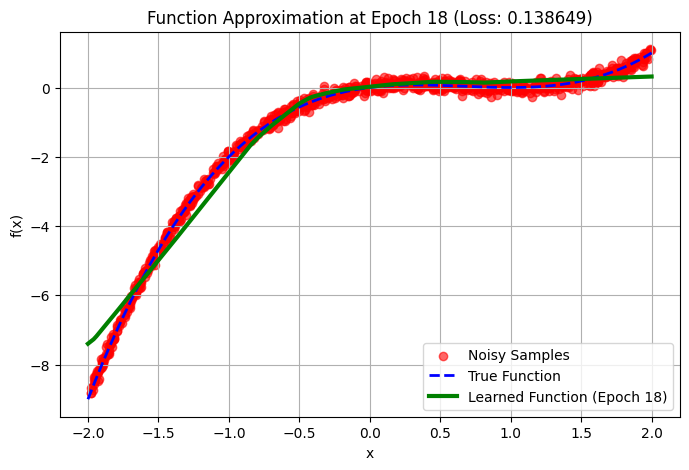

Epoch [19/20], Loss: 0.138649


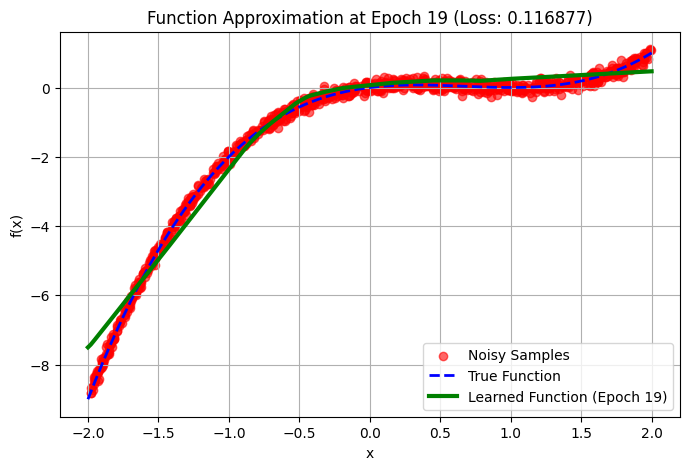

Epoch [20/20], Loss: 0.116877


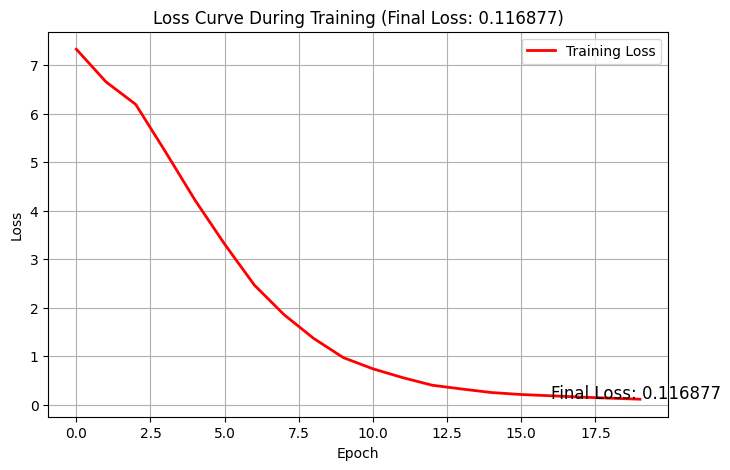

In [ ]:
# TODO: Train on Cubic Polynomial
# generate data - plot data - create model - train model - plot loss
x_train_tensor, y_train_tensor, x_train, y_train = generate_training_data(function_2)
plot_training_data(x_train, y_train, function_2)

x = np.arange(-2,2,0.01).reshape(-1, 1)
y = function_2(x)

x_train_tensor_2 = torch.tensor(x,dtype = torch.float32)
y_train_tensor_2 = torch.tensor(y,dtype = torch.float32)

model = NeuralNetwork()

loss_history = train_model(model, x_train_tensor_2, y_train_tensor_2, function_2, num_epochs=20, batch_size=32, lr=0.001 )
plot_loss_curve(loss_history)
# End of TODO

In [ ]:
# Define the hard function
def hard_function(x):
    return np.exp(-x**2) * np.sin(10*x) + 0.5 * np.tanh(5*x) + 0.3 * np.cos(20*x) + 0.1*x


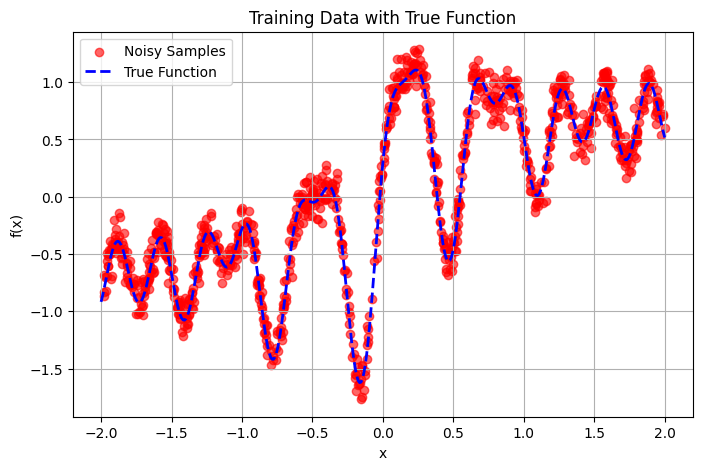

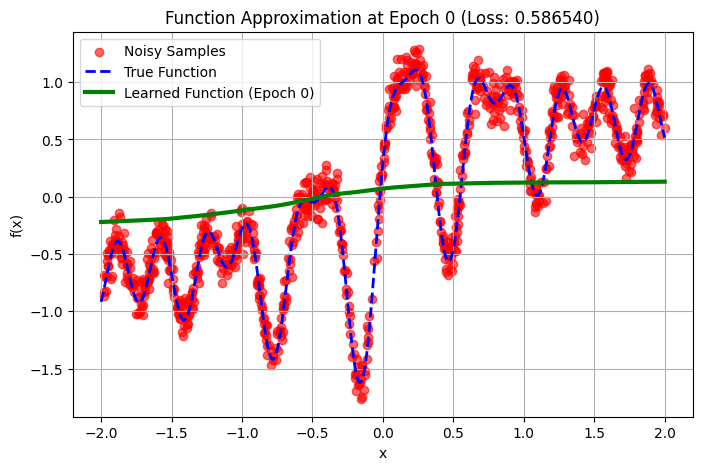

Epoch [1/10], Loss: 0.586540


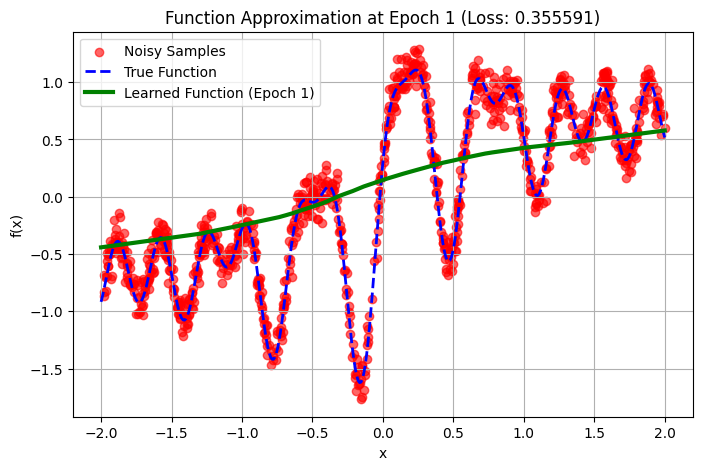

Epoch [2/10], Loss: 0.355591


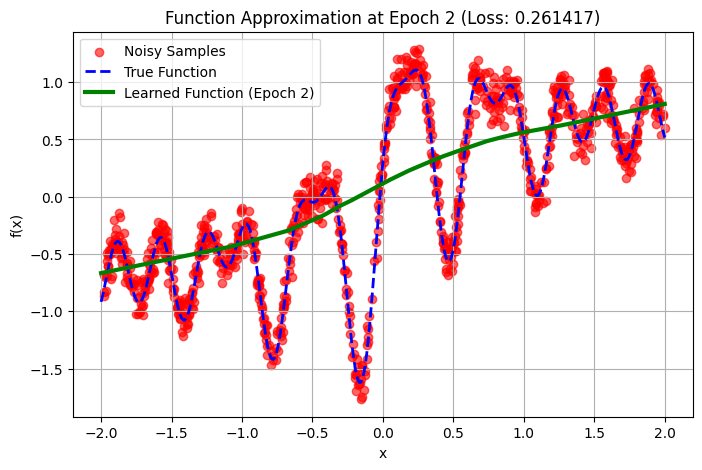

Epoch [3/10], Loss: 0.261417


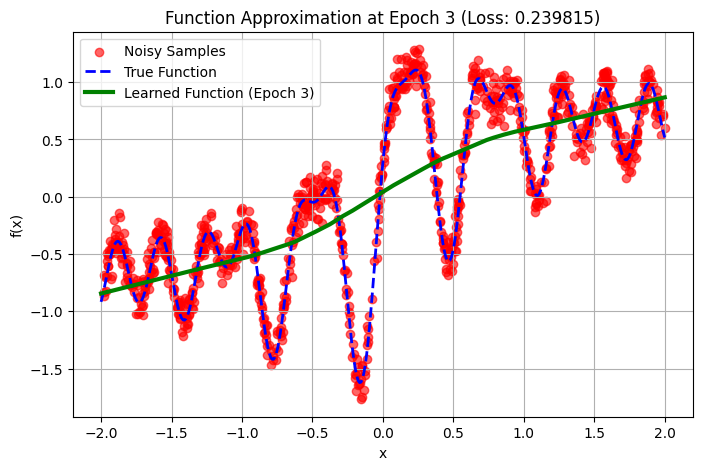

Epoch [4/10], Loss: 0.239815


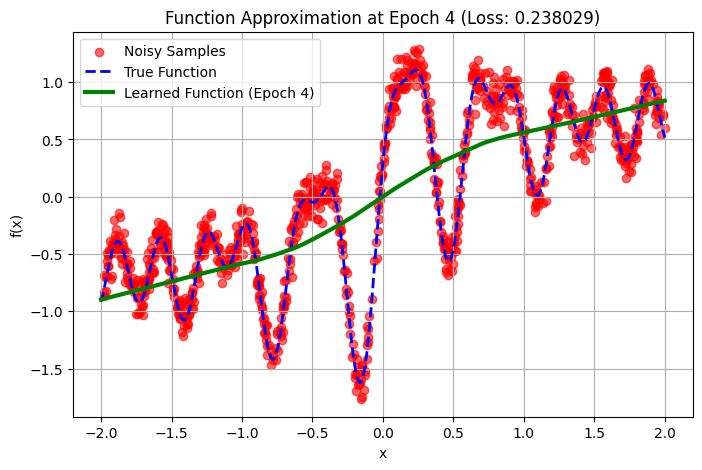

Epoch [5/10], Loss: 0.238029


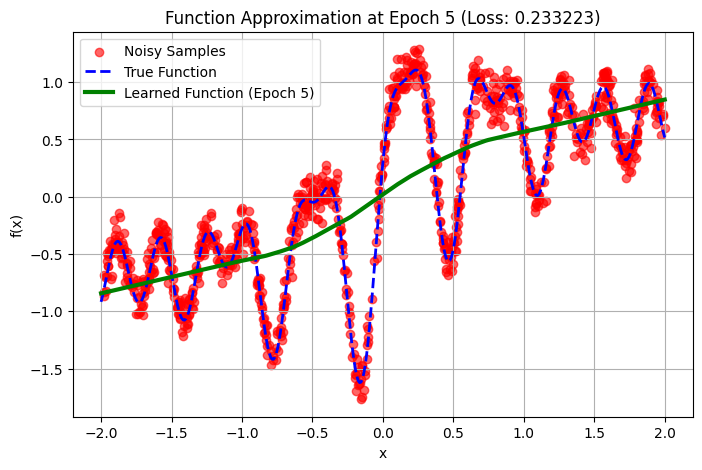

Epoch [6/10], Loss: 0.233223


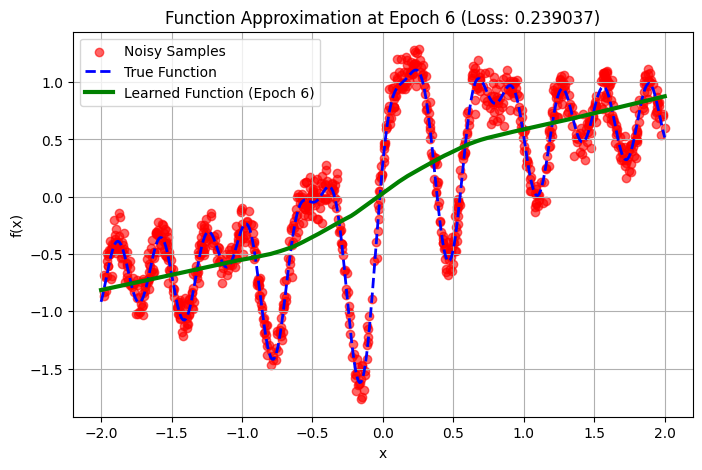

Epoch [7/10], Loss: 0.239037


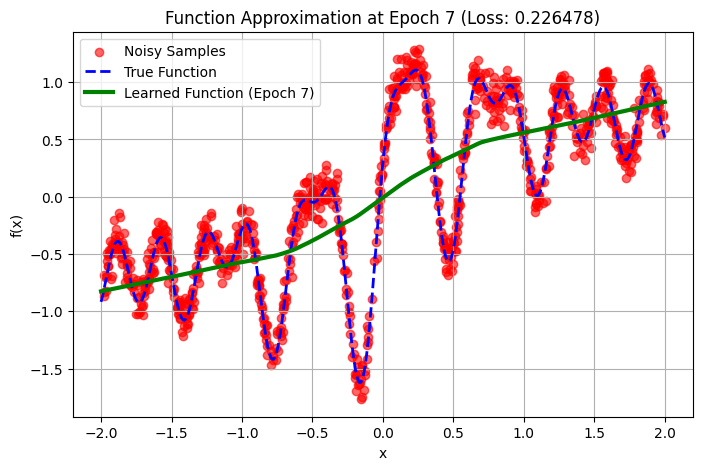

Epoch [8/10], Loss: 0.226478


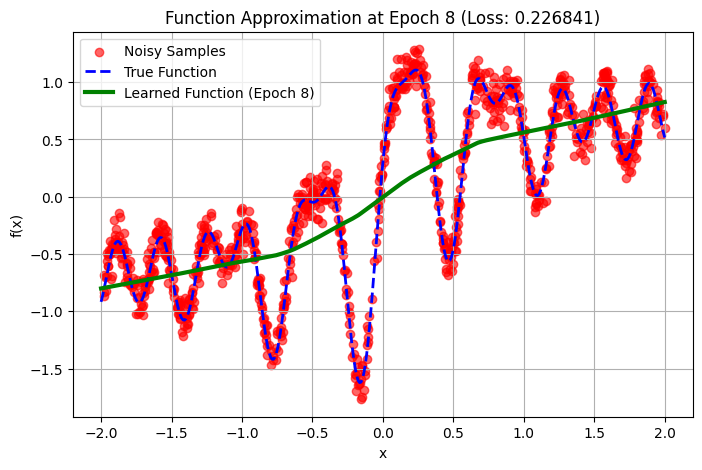

Epoch [9/10], Loss: 0.226841


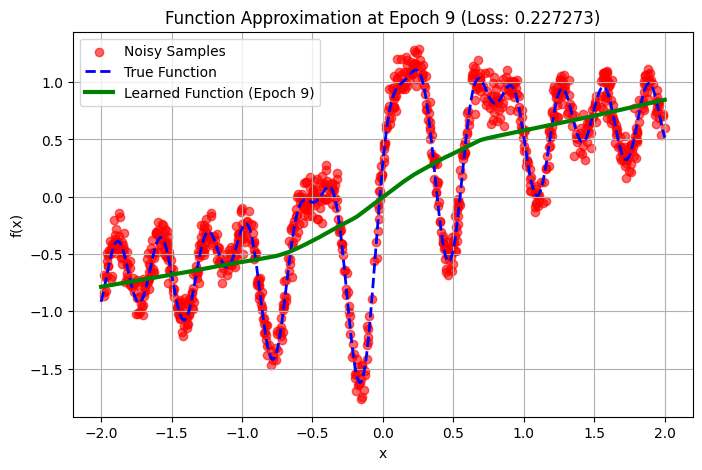

Epoch [10/10], Loss: 0.227273


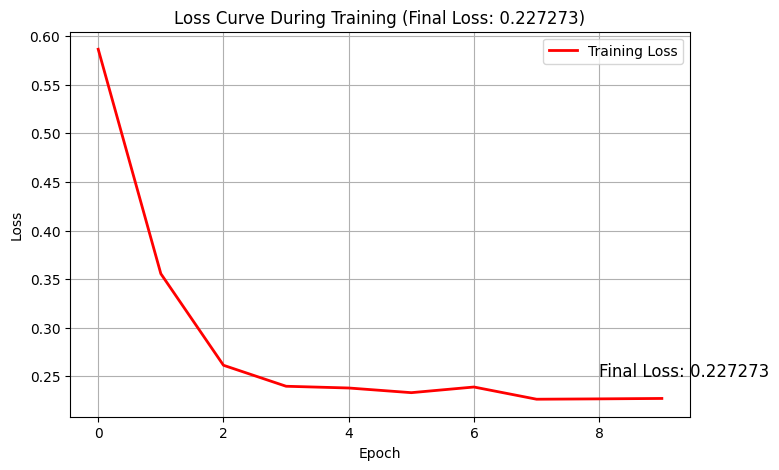

In [ ]:
#  TODO: Train on the hard function
# generate data - plot data - create model - train model - plot loss

x_train_tensor, y_train_tensor, x_train, y_train = generate_training_data(hard_function)
plot_training_data(x_train, y_train, hard_function)

x = np.arange(-2,2,0.01).reshape(-1, 1)
y = hard_function(x)

x_train_tensor_2 = torch.tensor(x,dtype = torch.float32)
y_train_tensor_2 = torch.tensor(y,dtype = torch.float32)

model = NeuralNetwork()

loss_history = train_model(model, x_train_tensor_2, y_train_tensor_2, true_function_1 = hard_function, num_epochs=10, batch_size=32, lr=0.001 )

plot_loss_curve(loss_history)

# End of TODO

Now you will implement three different neural networks using PyTorch: a shallow neural network, a medium-depth neural network, and a deep neural network. Follow the steps below to complete the assignment.

- Define a class `ShallowNetwork` inheriting from `nn.Module`.
- Implement the `__init__` method with parameters `input_dim=1`, `hidden_dim=16`, and `output_dim=1`.
- Add layers:
  - `fc1`: fully connected layer from `input_dim` to `hidden_dim`.
  - `fc2`: fully connected layer from `hidden_dim` to `output_dim`.
  - Activation: `nn.ReLU()`.
- Implement the `forward` method to apply activation after `fc1` and pass the output through `fc2`.



- Define a class `MediumNetwork` inheriting from `nn.Module`.
- Implement `__init__` with `input_dim=1`, `hidden_dim=32`, and `output_dim=1`.
- Add layers:
  - `fc1`: `input_dim` to `hidden_dim`.
  - `fc2`: `hidden_dim` to `hidden_dim`.
  - `fc3`: `hidden_dim` to `output_dim`.
  - Activation: `nn.ReLU()`.
- Implement `forward` with activation after `fc1` and `fc2`, then pass through `fc3`.





- Define a class `DeepNetwork` inheriting from `nn.Module`.
- Implement `__init__` with `input_dim=1`, `hidden_dim=64`, and `output_dim=1`.
- Add layers:
  - `fc1`: `input_dim` to `hidden_dim`.
  - `fc2`, `fc3`, `fc4`: each `hidden_dim` to `hidden_dim`.
  - `fc5`: `hidden_dim` to `output_dim`.
  - Activation: `nn.ReLU()`.
- Implement `forward` with activation after `fc1`, `fc2`, `fc3`, and `fc4`, then pass through `fc5`.

In [ ]:
# TODO: create the NNs that we described above
# Define a shallow neural network (1 hidden layer)

import torch.nn as nn

class ShallowNetwork(nn.Module):
  def __init__(self, input_dim=1, hidden_dim=16, output_dim=1):
    super(ShallowNetwork, self).__init__()

    # Define layers
    self.fc1 = nn.Linear(input_dim, hidden_dim)
    self.fc2 = nn.Linear(hidden_dim, output_dim)
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.relu(self.fc1(x))
    x = self.fc2(x)
    return x


# Define a medium-depth neural network (2 hidden layers)
class MediumNetwork(nn.Module):
  def __init__(self, input_dim=1, hidden_dim=32, output_dim=1):
    super(MediumNetwork, self).__init__()

    # Define layers
    self.fc1 = nn.Linear(input_dim, hidden_dim)
    self.fc2 = nn.Linear(hidden_dim, hidden_dim)
    self.fc3 = nn.Linear(hidden_dim, output_dim)
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.relu(self.fc1(x))
    x = self.relu(self.fc2(x))
    x = self.fc3(x)
    return x

# Define a deep neural network (4 hidden layers)
class DeepNetwork(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, output_dim=1):
        super(DeepNetwork, self).__init__()

        # Define layers
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, hidden_dim)
        self.fc5 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.fc5(x)
        return x

# END of TODO

Epoch [1/30], Loss: 0.940304
Epoch [2/30], Loss: 0.782901
Epoch [3/30], Loss: 0.673713
Epoch [4/30], Loss: 0.586240
Epoch [5/30], Loss: 0.521197
Epoch [6/30], Loss: 0.478283


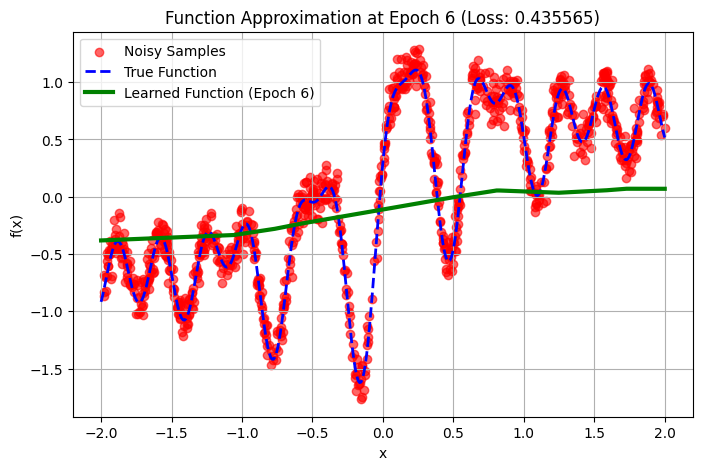

Epoch [7/30], Loss: 0.435565
Epoch [8/30], Loss: 0.395822
Epoch [9/30], Loss: 0.365422
Epoch [10/30], Loss: 0.347216
Epoch [11/30], Loss: 0.318648
Epoch [12/30], Loss: 0.312933


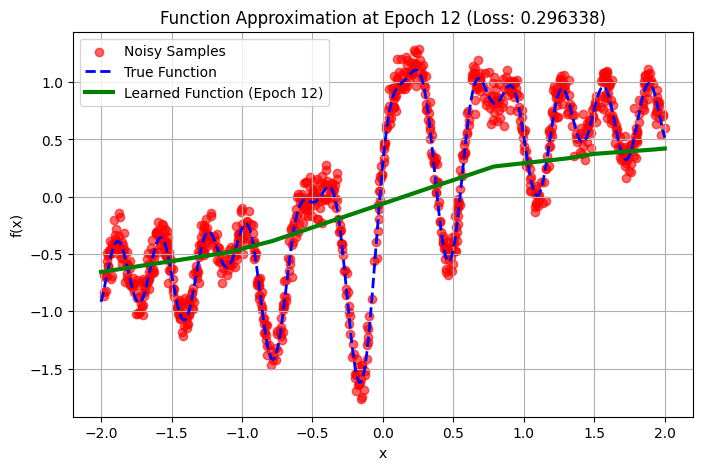

Epoch [13/30], Loss: 0.296338
Epoch [14/30], Loss: 0.271221
Epoch [15/30], Loss: 0.271685
Epoch [16/30], Loss: 0.253246
Epoch [17/30], Loss: 0.255229
Epoch [18/30], Loss: 0.246770


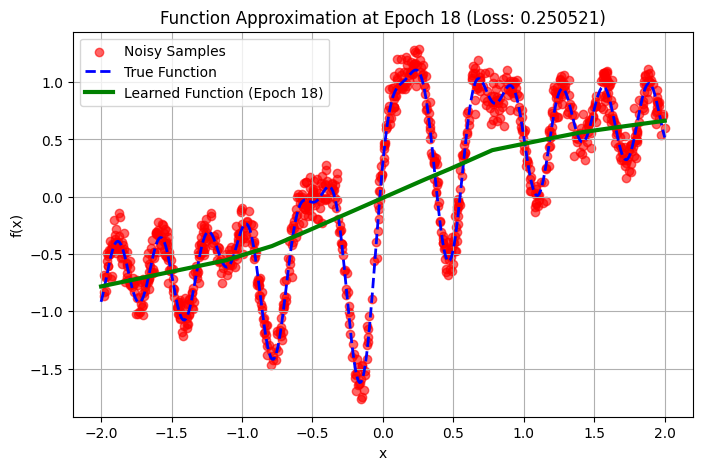

Epoch [19/30], Loss: 0.250521
Epoch [20/30], Loss: 0.249458
Epoch [21/30], Loss: 0.246161
Epoch [22/30], Loss: 0.237892
Epoch [23/30], Loss: 0.237340
Epoch [24/30], Loss: 0.241473


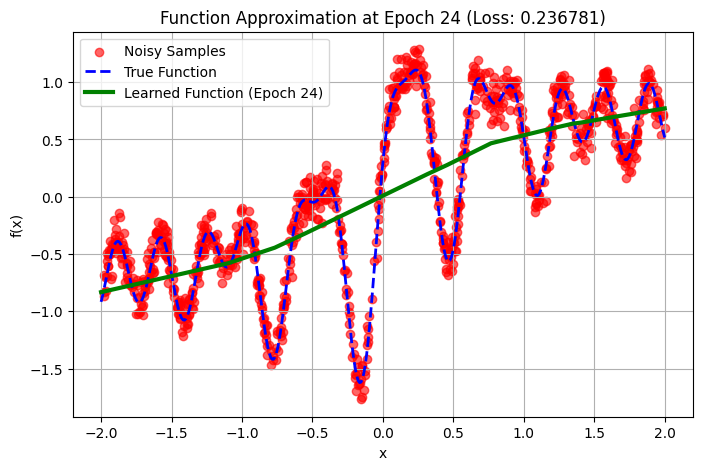

Epoch [25/30], Loss: 0.236781
Epoch [26/30], Loss: 0.239138
Epoch [27/30], Loss: 0.234473
Epoch [28/30], Loss: 0.235897
Epoch [29/30], Loss: 0.235720
Epoch [30/30], Loss: 0.244984


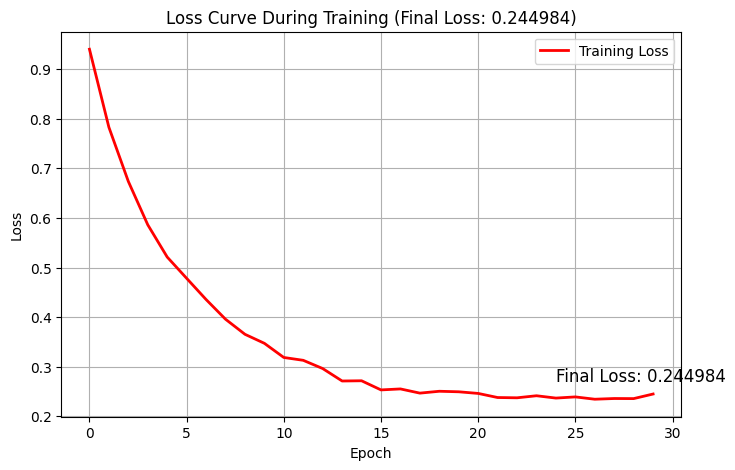

In [ ]:
# TODO: Train Shallow Network



x = np.arange(-2,2,0.01).reshape(-1, 1)
y = hard_function(x)



x_train_tensor_2 = torch.tensor(x,dtype = torch.float32)
y_train_tensor_2 = torch.tensor(y,dtype = torch.float32)

model = ShallowNetwork()

loss_history_Shallow = train_model(model, x_train_tensor_2, y_train_tensor_2, true_function_1 = hard_function, num_epochs=30, batch_size=32, lr=0.001,plot_interval= 6)

plot_loss_curve(loss_history_Shallow)

# End of TODO

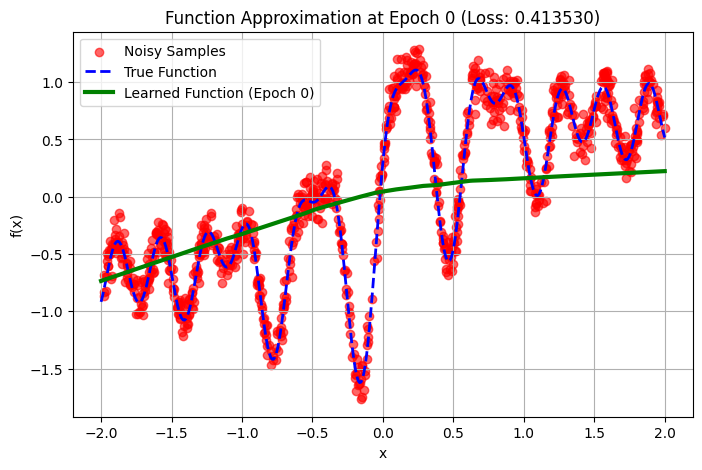

Epoch [1/30], Loss: 0.413530
Epoch [2/30], Loss: 0.313988
Epoch [3/30], Loss: 0.269619
Epoch [4/30], Loss: 0.253090
Epoch [5/30], Loss: 0.243552
Epoch [6/30], Loss: 0.238180


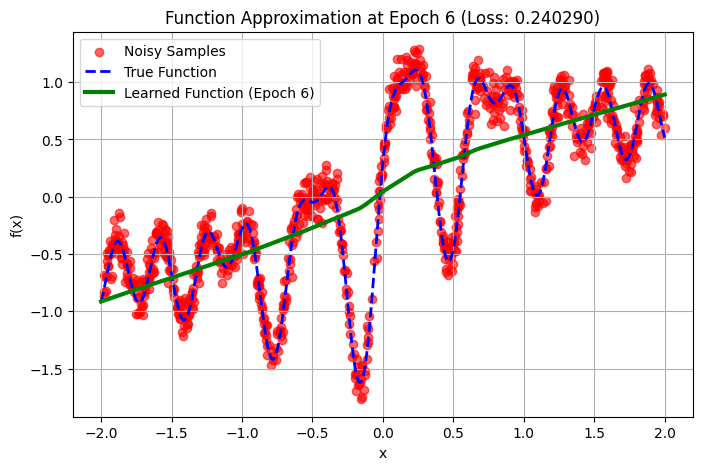

Epoch [7/30], Loss: 0.240290
Epoch [8/30], Loss: 0.233021
Epoch [9/30], Loss: 0.230648
Epoch [10/30], Loss: 0.234588
Epoch [11/30], Loss: 0.228699
Epoch [12/30], Loss: 0.222191


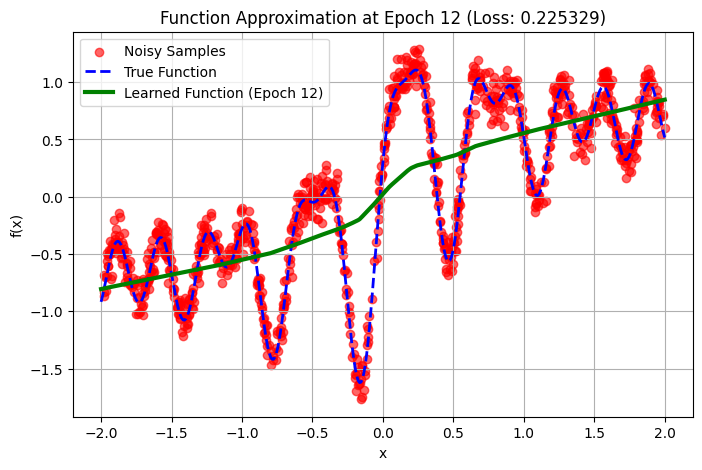

Epoch [13/30], Loss: 0.225329
Epoch [14/30], Loss: 0.224176
Epoch [15/30], Loss: 0.209896
Epoch [16/30], Loss: 0.211070
Epoch [17/30], Loss: 0.211147
Epoch [18/30], Loss: 0.209897


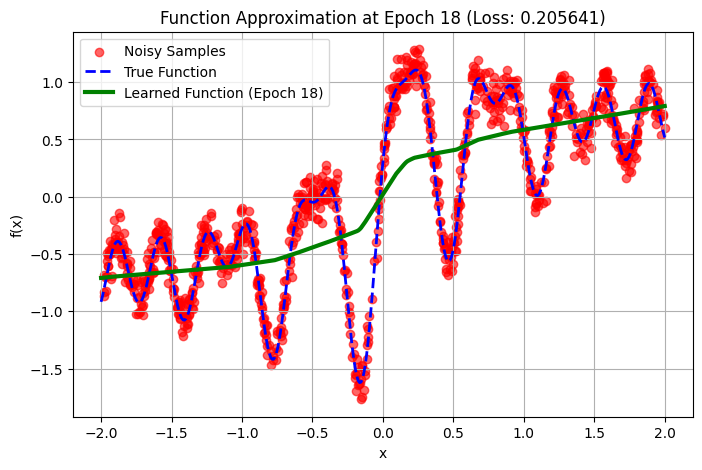

Epoch [19/30], Loss: 0.205641
Epoch [20/30], Loss: 0.203591
Epoch [21/30], Loss: 0.198537
Epoch [22/30], Loss: 0.197851
Epoch [23/30], Loss: 0.197809
Epoch [24/30], Loss: 0.194268


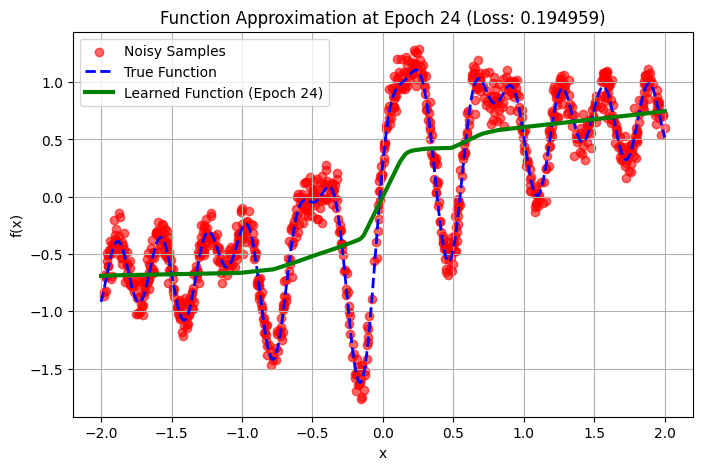

Epoch [25/30], Loss: 0.194959
Epoch [26/30], Loss: 0.190268
Epoch [27/30], Loss: 0.189360
Epoch [28/30], Loss: 0.185704
Epoch [29/30], Loss: 0.186492
Epoch [30/30], Loss: 0.182614


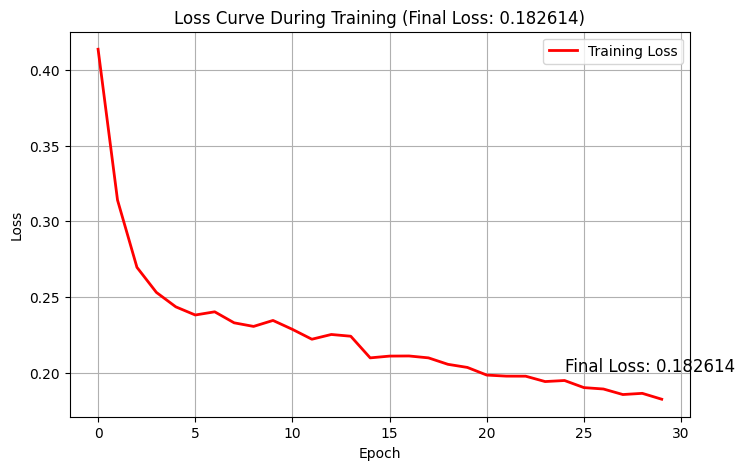

In [89]:
# TODO Train Medium Network
x = np.arange(-2,2,0.01).reshape(-1, 1)
y = hard_function(x)

x_train_tensor_2 = torch.tensor(x,dtype = torch.float32)
y_train_tensor_2 = torch.tensor(y,dtype = torch.float32)

model = MediumNetwork()

loss_history_Medium = train_model(model, x_train_tensor_2, y_train_tensor_2, true_function_1 = hard_function, num_epochs=30, batch_size=32, lr=0.001 ,plot_interval=6)

plot_loss_curve(loss_history_Medium)

# End of TODO

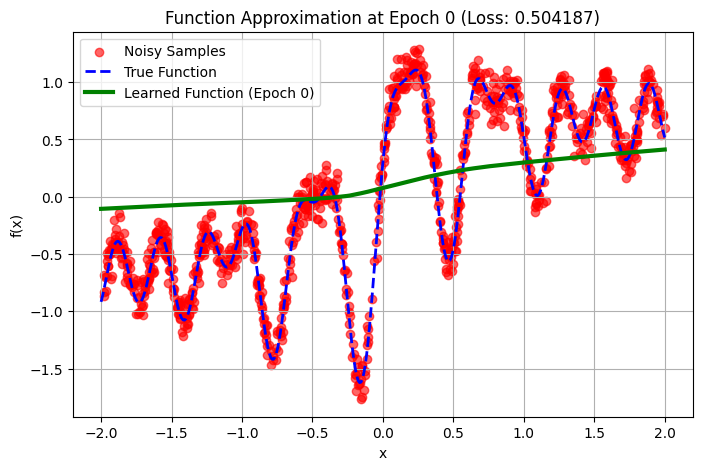

Epoch [1/30], Loss: 0.504187
Epoch [2/30], Loss: 0.311499
Epoch [3/30], Loss: 0.229973
Epoch [4/30], Loss: 0.223208
Epoch [5/30], Loss: 0.213698
Epoch [6/30], Loss: 0.211832


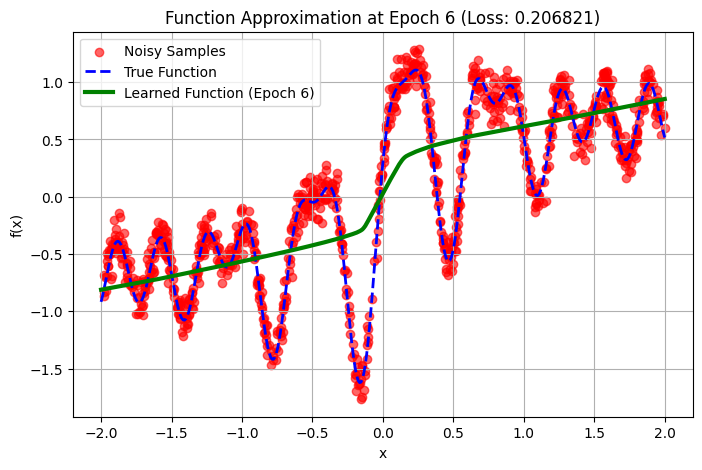

Epoch [7/30], Loss: 0.206821
Epoch [8/30], Loss: 0.205712
Epoch [9/30], Loss: 0.198190
Epoch [10/30], Loss: 0.202965
Epoch [11/30], Loss: 0.197000
Epoch [12/30], Loss: 0.187321


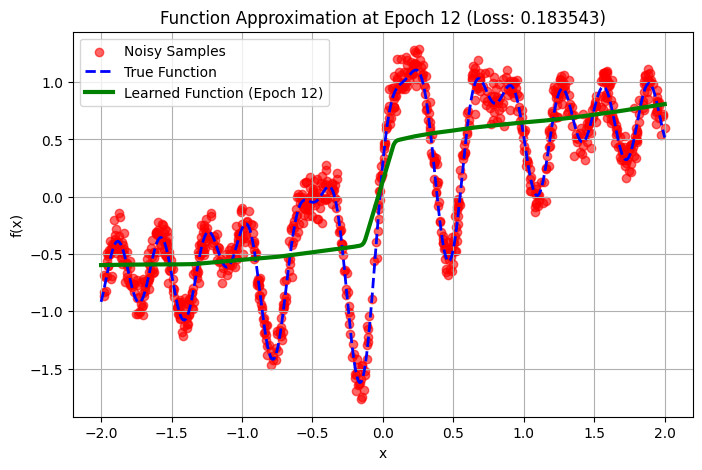

Epoch [13/30], Loss: 0.183543
Epoch [14/30], Loss: 0.180174
Epoch [15/30], Loss: 0.185575
Epoch [16/30], Loss: 0.176088
Epoch [17/30], Loss: 0.180011
Epoch [18/30], Loss: 0.174029


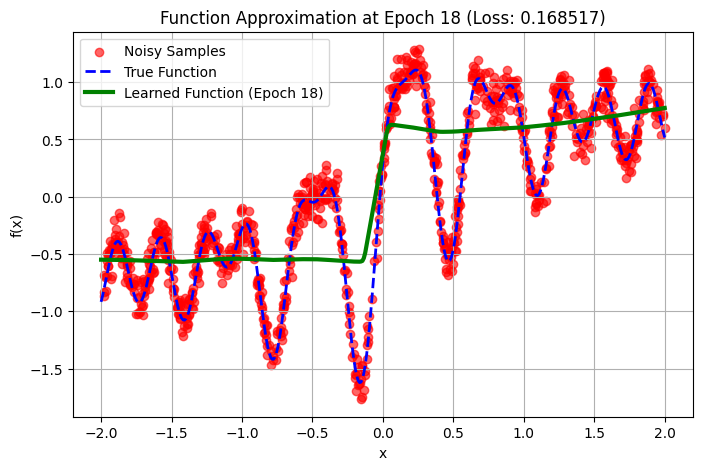

Epoch [19/30], Loss: 0.168517
Epoch [20/30], Loss: 0.171198
Epoch [21/30], Loss: 0.169134
Epoch [22/30], Loss: 0.166339
Epoch [23/30], Loss: 0.161518
Epoch [24/30], Loss: 0.160740


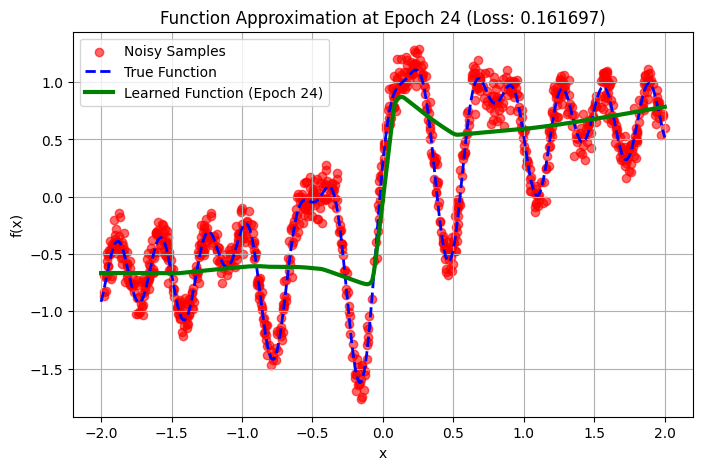

Epoch [25/30], Loss: 0.161697
Epoch [26/30], Loss: 0.160187
Epoch [27/30], Loss: 0.153653
Epoch [28/30], Loss: 0.155176
Epoch [29/30], Loss: 0.144660
Epoch [30/30], Loss: 0.144637


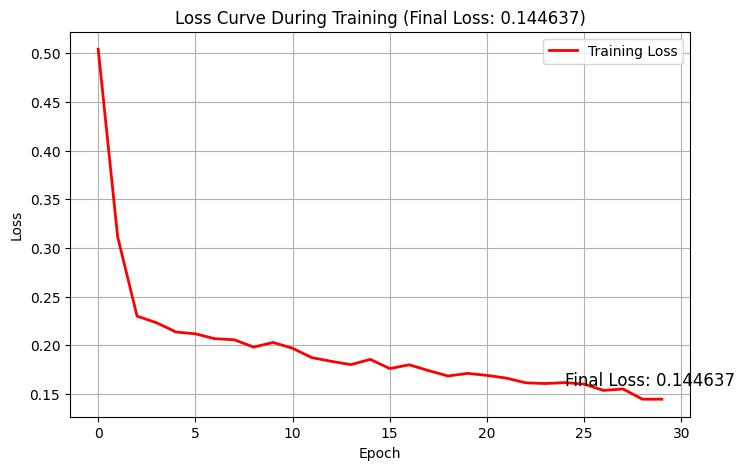

In [90]:
# TODO Train Deep Network
x = np.arange(-2,2,0.01).reshape(-1, 1)
y = hard_function(x)

x_train_tensor_2 = torch.tensor(x,dtype = torch.float32)
y_train_tensor_2 = torch.tensor(y,dtype = torch.float32)

model = DeepNetwork()

loss_history_Deep = train_model(model, x_train_tensor_2, y_train_tensor_2, true_function_1 = hard_function, num_epochs=30, batch_size=32, lr=0.001 ,plot_interval=6)

plot_loss_curve(loss_history_Deep)

# End of TODO

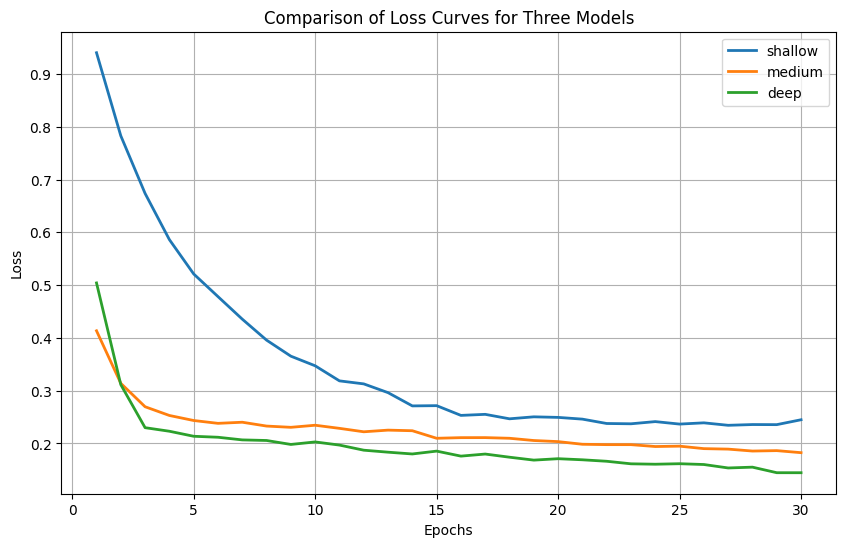

In [91]:
# TODO: create a function named compare_loss_curves
# and plot the loss of three models in one plot to compare them

def compare_loss_curves(loss_history1, loss_history2, loss_history3, labels=["Model 1", "Model 2", "Model 3"]):
    import matplotlib.pyplot as plt
    epochs = range(1, len(loss_history1) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, loss_history1, label=labels[0], linewidth=2)
    plt.plot(epochs, loss_history2, label=labels[1], linewidth=2)
    plt.plot(epochs, loss_history3, label=labels[2], linewidth=2)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Comparison of Loss Curves for Three Models")
    plt.legend()
    plt.grid(True)
    plt.show()


compare_loss_curves(loss_history_Shallow,loss_history_Medium,loss_history_Deep,labels =['shallow','medium','deep'])
# END of TODO

Now want to see the effect of number of layers and neurons. first we define a simple funtion and plot it.


Generating Data for Hybrid Function


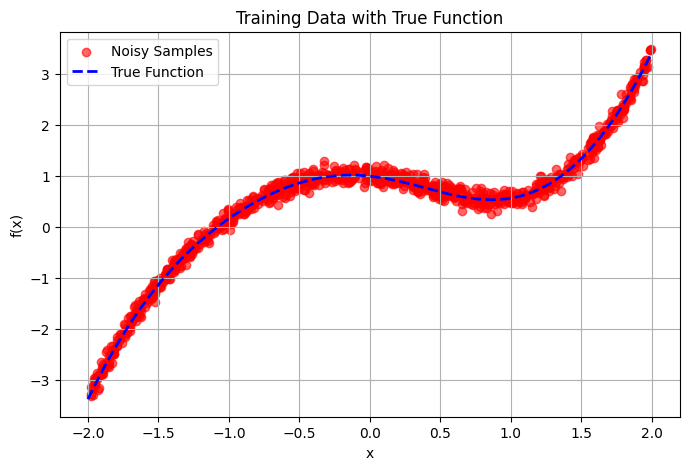

In [92]:
# Define the function to fit
def hybrid_function(x):
    return np.exp(-x**2) + 0.5*x**3 - 0.3*x

# Generate training data
print("\nGenerating Data for Hybrid Function")
x_train_tensor, y_train_tensor, x_train, y_train = generate_training_data(true_func=hybrid_function)

# Plot training data
plot_training_data(x_train, y_train, true_func=hybrid_function)


you will implement three different neural networks with varying depths and neuron counts using PyTorch to observe the effect of layers and the number of neurons. Note that all of these models have the same number of neurons.

- Define a class `WideShallowNetwork` inheriting from `nn.Module`.
- Implement `__init__` with `input_dim=1`, `hidden_dim=128`, and `output_dim=1`.
- Add layers:
  - `fc1`: fully connected layer from `input_dim` to `hidden_dim`.
  - `fc2`: fully connected layer from `hidden_dim` to `output_dim`.
  - Activation: `nn.ReLU()`.
- Implement the `forward` method to apply activation after `fc1` and pass the output through `fc2`.



- Define a class `BalancedNetwork` inheriting from `nn.Module`.
- Implement `__init__` with `input_dim=1`, `hidden_dim=64`, and `output_dim=1`.
- Add layers:
  - `fc1`: `input_dim` to `hidden_dim`.
  - `fc2`: `hidden_dim` to `hidden_dim`.
  - `fc3`: `hidden_dim` to `output_dim`.
  - Activation: `nn.ReLU()`.
- Implement `forward` with activation after `fc1` and `fc2`, then pass through `fc3`.


- Define a class `DeepNarrowNetwork` inheriting from `nn.Module`.
- Implement `__init__` with `input_dim=1`, `hidden_dim=32`, and `output_dim=1`.
- Add layers:
  - `fc1`: `input_dim` to `hidden_dim`.
  - `fc2`, `fc3`, `fc4`: each `hidden_dim` to `hidden_dim`.
  - `fc5`: `hidden_dim` to `output_dim`.
  - Activation: `nn.ReLU()`.
- Implement `forward` with activation after `fc1`, `fc2`, `fc3`, and `fc4`, then pass through `fc5`.

In [93]:
# TODO: create the NNs that we described above

# Wide-Shallow Network (1 layer with many neurons)
class WideShallowNetwork(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128, output_dim=1):
        super(WideShallowNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Balanced Network (2 layers, medium neurons)
class BalancedNetwork(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, output_dim=1):
        super(BalancedNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


# Deep-Narrow Network (4 layers, fewer neurons per layer)
class DeepNarrowNetwork(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, output_dim=1):
        super(DeepNarrowNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, hidden_dim)
        self.fc5 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.fc5(x)
        return x


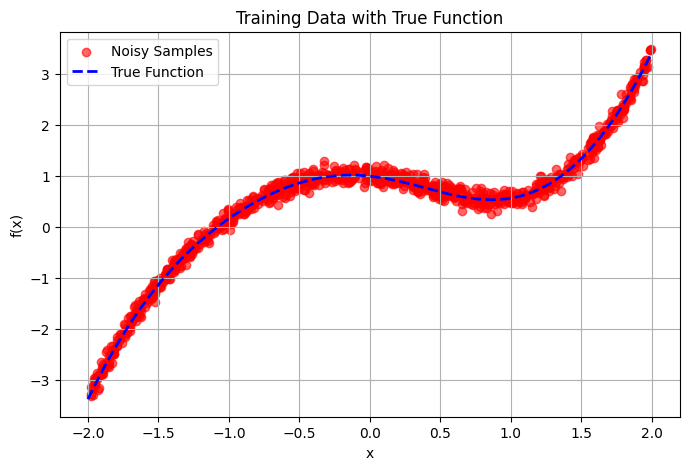

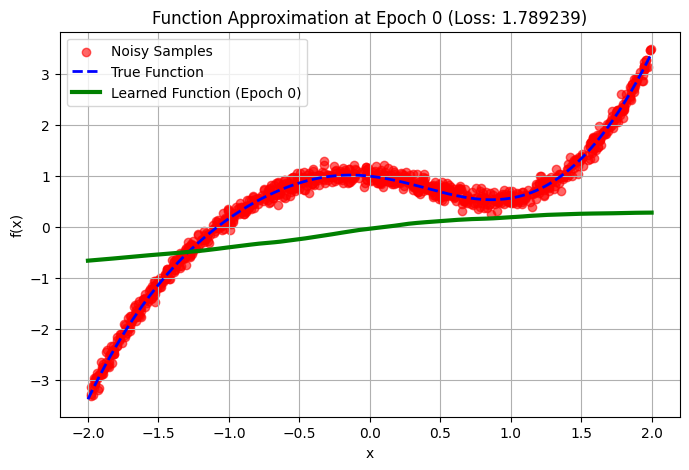

Epoch [1/31], Loss: 1.789239
Epoch [2/31], Loss: 1.041404
Epoch [3/31], Loss: 0.660493
Epoch [4/31], Loss: 0.505865
Epoch [5/31], Loss: 0.431749
Epoch [6/31], Loss: 0.395486


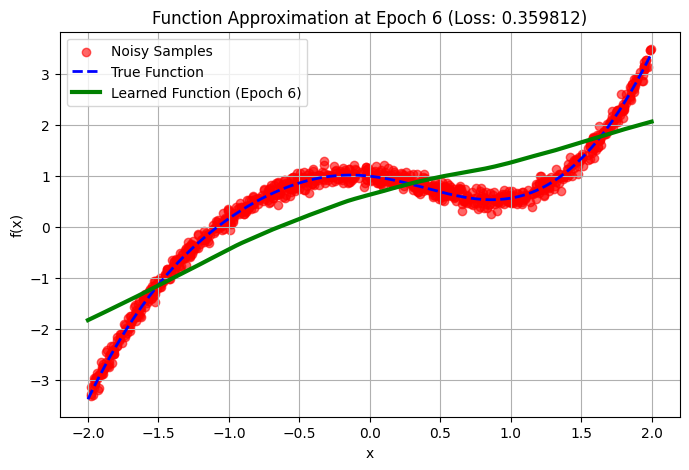

Epoch [7/31], Loss: 0.359812
Epoch [8/31], Loss: 0.328987
Epoch [9/31], Loss: 0.298206
Epoch [10/31], Loss: 0.272197
Epoch [11/31], Loss: 0.254552
Epoch [12/31], Loss: 0.234982


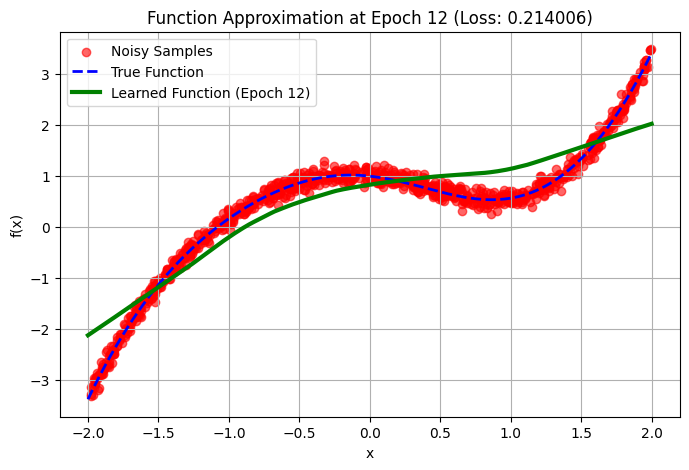

Epoch [13/31], Loss: 0.214006
Epoch [14/31], Loss: 0.202486
Epoch [15/31], Loss: 0.180942
Epoch [16/31], Loss: 0.168222
Epoch [17/31], Loss: 0.152586
Epoch [18/31], Loss: 0.142168


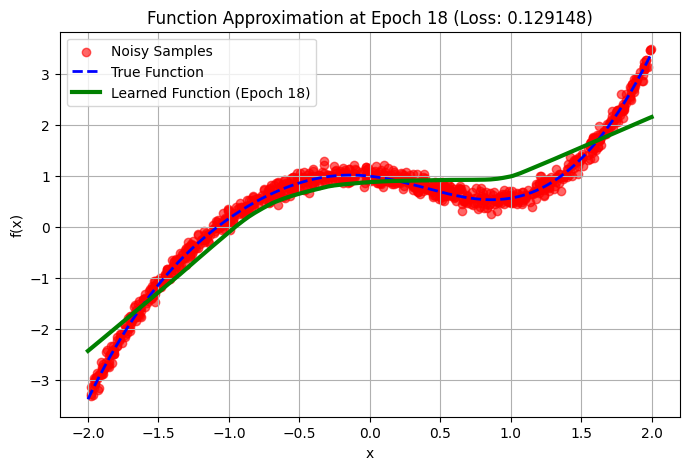

Epoch [19/31], Loss: 0.129148
Epoch [20/31], Loss: 0.118739
Epoch [21/31], Loss: 0.117092
Epoch [22/31], Loss: 0.101092
Epoch [23/31], Loss: 0.097072
Epoch [24/31], Loss: 0.085529


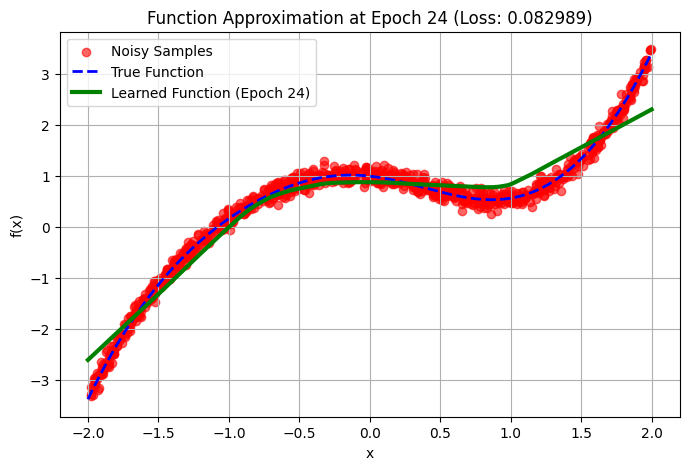

Epoch [25/31], Loss: 0.082989
Epoch [26/31], Loss: 0.073642
Epoch [27/31], Loss: 0.068132
Epoch [28/31], Loss: 0.064449
Epoch [29/31], Loss: 0.062544
Epoch [30/31], Loss: 0.056327


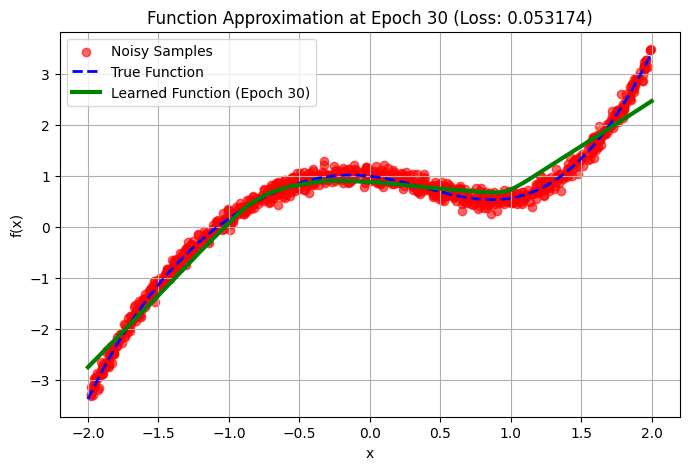

Epoch [31/31], Loss: 0.053174


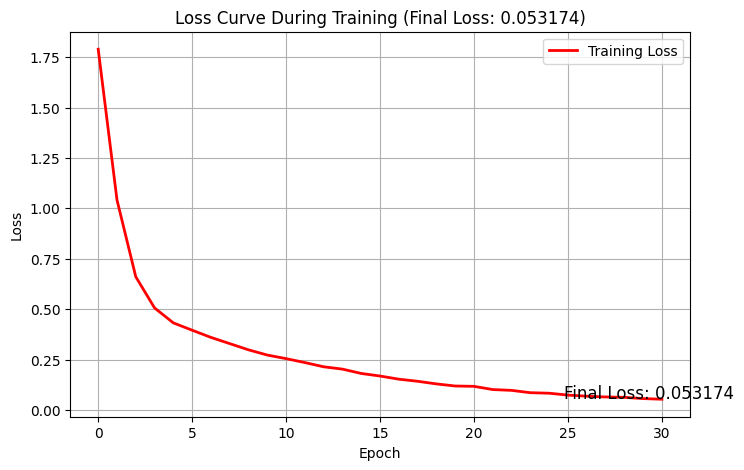

In [94]:
# TODO: Train Wide-Shallow Network
x_train_tensor, y_train_tensor, x_train, y_train = generate_training_data(hybrid_function)
plot_training_data(x_train, y_train, hybrid_function)

x = np.arange(-2,2,0.01).reshape(-1, 1)
y = hybrid_function(x)

x_train_tensor_2 = torch.tensor(x,dtype = torch.float32)
y_train_tensor_2 = torch.tensor(y,dtype = torch.float32)

model = WideShallowNetwork()

loss_history_WideShallowNetwork = train_model(model, x_train_tensor_2, y_train_tensor_2, true_function_1 = hybrid_function, num_epochs=31, batch_size=32, lr=0.001 ,plot_interval= 6)

plot_loss_curve(loss_history_WideShallowNetwork)

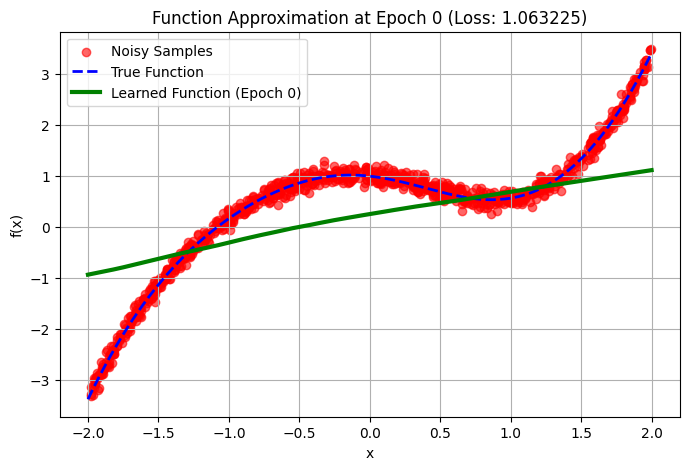

Epoch [1/31], Loss: 1.063225
Epoch [2/31], Loss: 0.532090
Epoch [3/31], Loss: 0.382964
Epoch [4/31], Loss: 0.298980
Epoch [5/31], Loss: 0.233291
Epoch [6/31], Loss: 0.181195


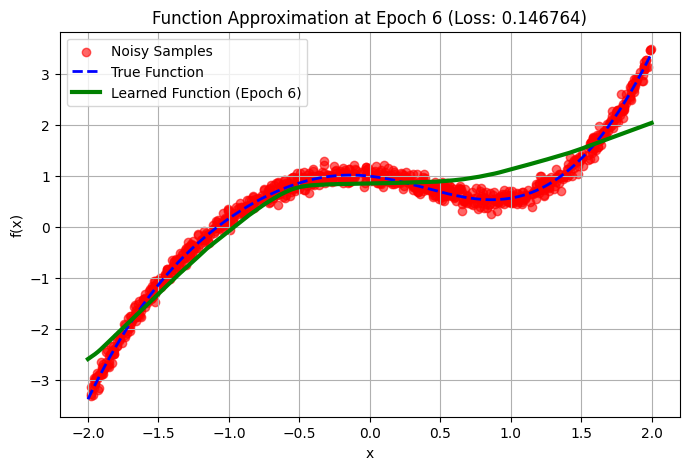

Epoch [7/31], Loss: 0.146764
Epoch [8/31], Loss: 0.121277
Epoch [9/31], Loss: 0.103481
Epoch [10/31], Loss: 0.082877
Epoch [11/31], Loss: 0.067834
Epoch [12/31], Loss: 0.060941


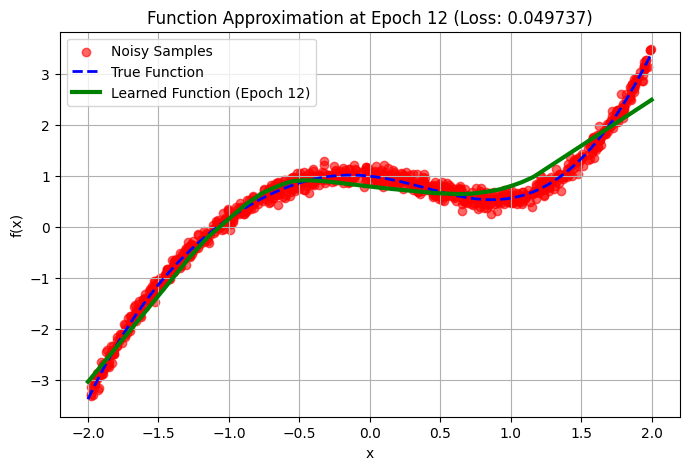

Epoch [13/31], Loss: 0.049737
Epoch [14/31], Loss: 0.042768
Epoch [15/31], Loss: 0.037063
Epoch [16/31], Loss: 0.034205
Epoch [17/31], Loss: 0.027691
Epoch [18/31], Loss: 0.023654


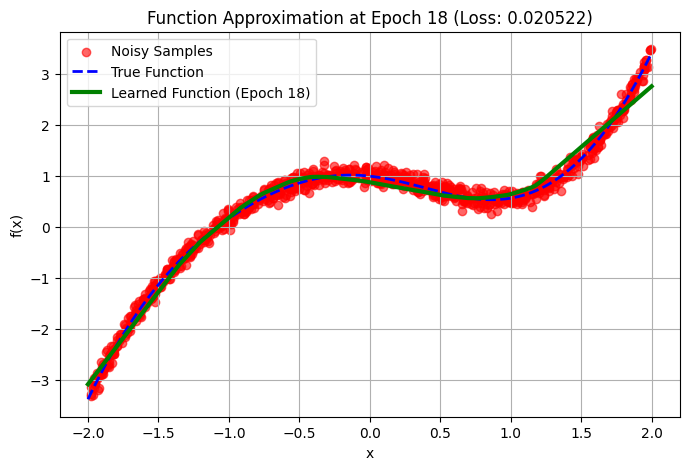

Epoch [19/31], Loss: 0.020522
Epoch [20/31], Loss: 0.017862
Epoch [21/31], Loss: 0.015772
Epoch [22/31], Loss: 0.013374
Epoch [23/31], Loss: 0.011202
Epoch [24/31], Loss: 0.010259


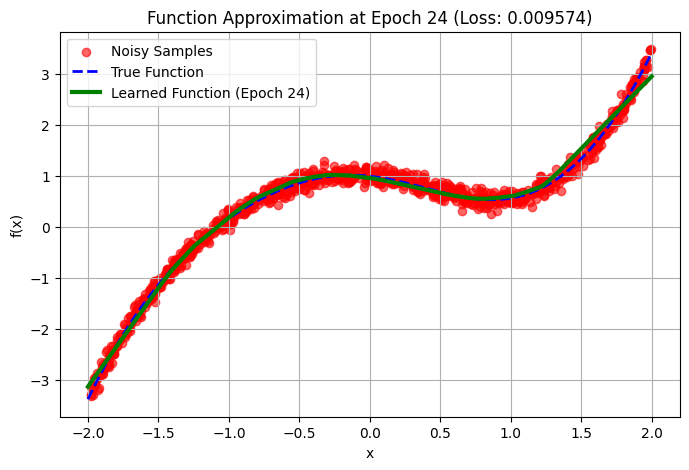

Epoch [25/31], Loss: 0.009574
Epoch [26/31], Loss: 0.007723
Epoch [27/31], Loss: 0.006639
Epoch [28/31], Loss: 0.006258
Epoch [29/31], Loss: 0.005295
Epoch [30/31], Loss: 0.004620


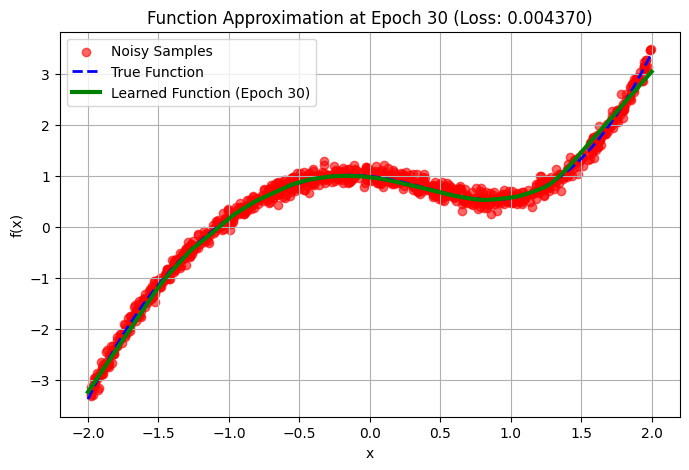

Epoch [31/31], Loss: 0.004370


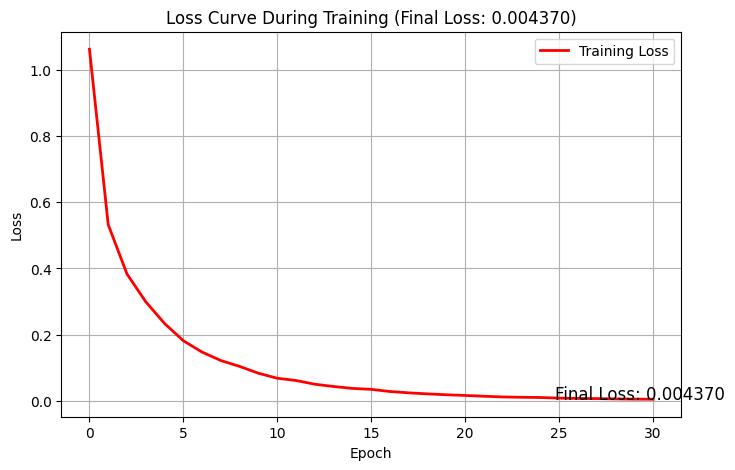

In [95]:
# TODO: Train Balanced Network


x = np.arange(-2,2,0.01).reshape(-1, 1)
y = hybrid_function(x)

x_train_tensor_2 = torch.tensor(x,dtype = torch.float32)
y_train_tensor_2 = torch.tensor(y,dtype = torch.float32)

model = BalancedNetwork()

loss_history_BalancedNetwork = train_model(model, x_train_tensor_2, y_train_tensor_2, true_function_1 = hybrid_function, num_epochs=31, batch_size=32, lr=0.001,plot_interval= 6)

plot_loss_curve(loss_history_BalancedNetwork)

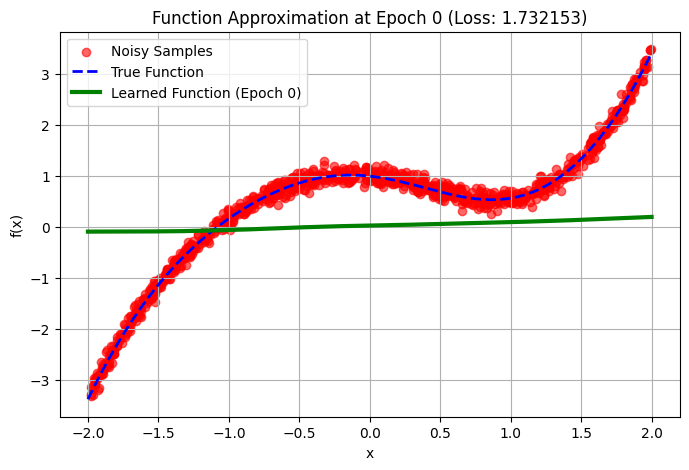

Epoch [1/31], Loss: 1.732153
Epoch [2/31], Loss: 1.364957
Epoch [3/31], Loss: 0.863729
Epoch [4/31], Loss: 0.699363
Epoch [5/31], Loss: 0.543543
Epoch [6/31], Loss: 0.379732


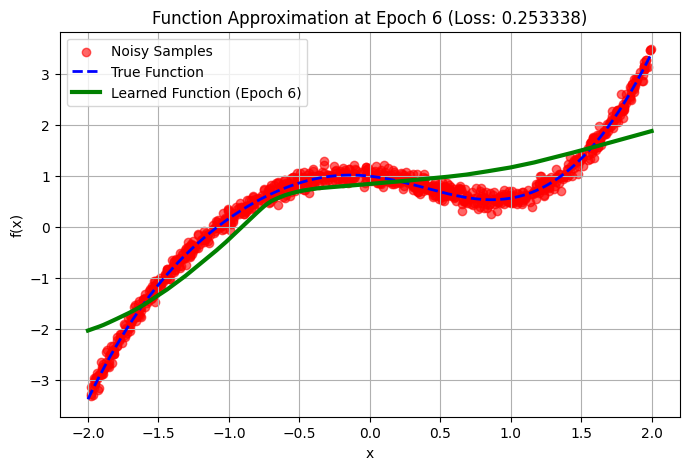

Epoch [7/31], Loss: 0.253338
Epoch [8/31], Loss: 0.192524
Epoch [9/31], Loss: 0.163405
Epoch [10/31], Loss: 0.142430
Epoch [11/31], Loss: 0.130412
Epoch [12/31], Loss: 0.116061


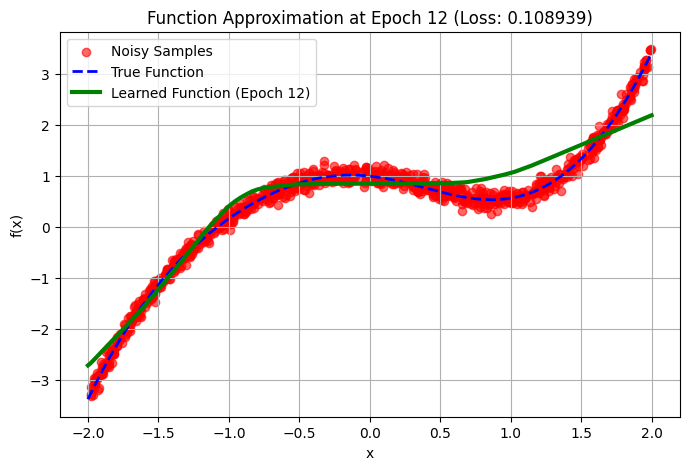

Epoch [13/31], Loss: 0.108939
Epoch [14/31], Loss: 0.092639
Epoch [15/31], Loss: 0.083427
Epoch [16/31], Loss: 0.077437
Epoch [17/31], Loss: 0.065347
Epoch [18/31], Loss: 0.061366


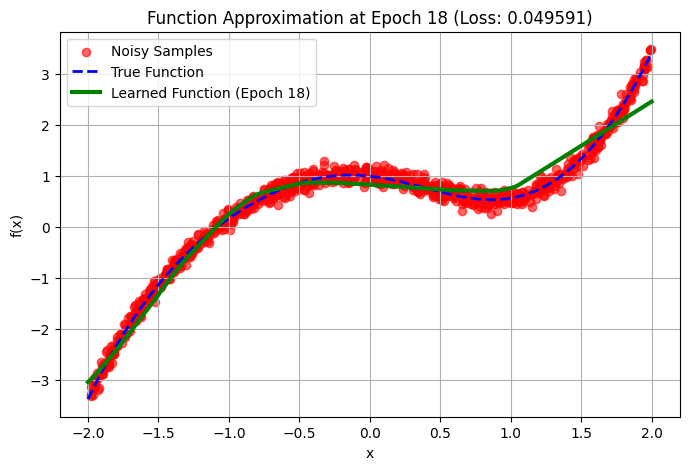

Epoch [19/31], Loss: 0.049591
Epoch [20/31], Loss: 0.044930
Epoch [21/31], Loss: 0.039896
Epoch [22/31], Loss: 0.033810
Epoch [23/31], Loss: 0.028686
Epoch [24/31], Loss: 0.025179


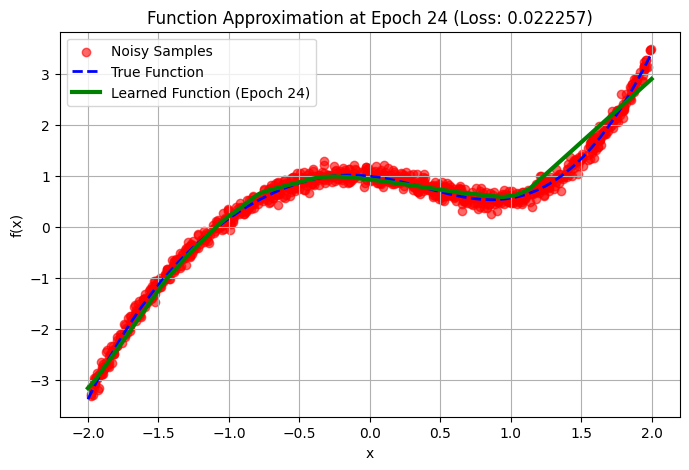

Epoch [25/31], Loss: 0.022257
Epoch [26/31], Loss: 0.017368
Epoch [27/31], Loss: 0.014020
Epoch [28/31], Loss: 0.012646
Epoch [29/31], Loss: 0.012025
Epoch [30/31], Loss: 0.010244


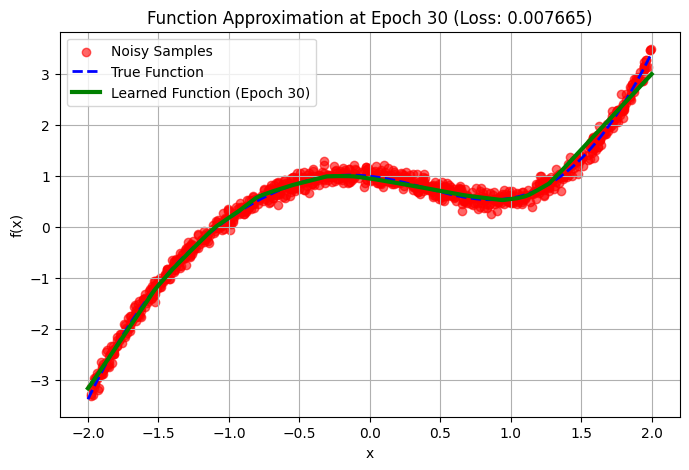

Epoch [31/31], Loss: 0.007665


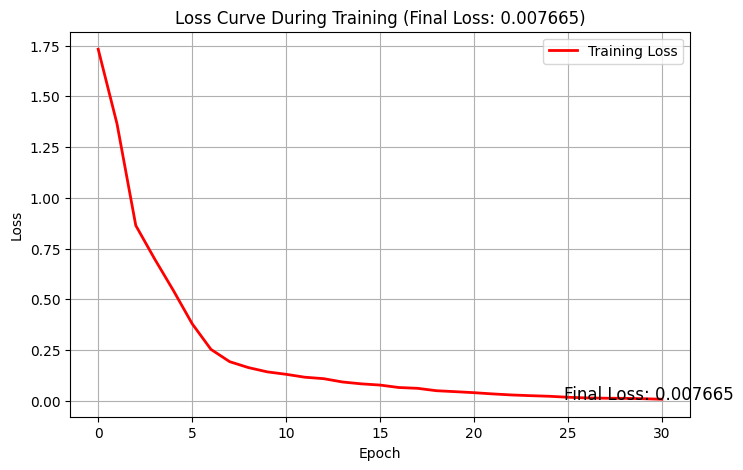

In [96]:
# TODO: Train Deep-Narrow Network
x = np.arange(-2,2,0.01).reshape(-1, 1)
y = hybrid_function(x)

x_train_tensor_2 = torch.tensor(x,dtype = torch.float32)
y_train_tensor_2 = torch.tensor(y,dtype = torch.float32)

model = DeepNarrowNetwork()

loss_history_DeepNarrowNetwork = train_model(model, x_train_tensor_2, y_train_tensor_2, true_function_1 = hybrid_function, num_epochs=31, batch_size=32, lr=0.001,plot_interval= 6)

plot_loss_curve(loss_history_DeepNarrowNetwork)

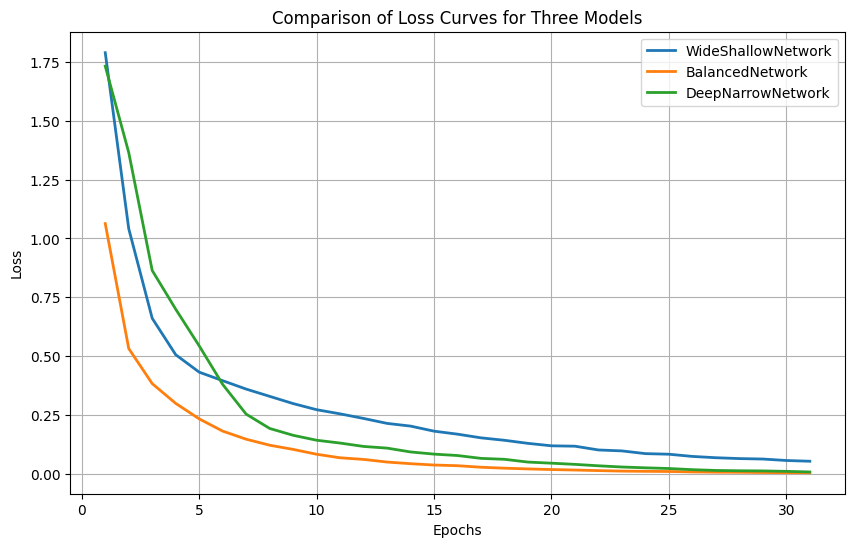

In [97]:
# TODO: create a function named compare_loss_curves
# and plot the loss of three models in one plot to compare them

compare_loss_curves(loss_history_WideShallowNetwork,loss_history_BalancedNetwork,loss_history_DeepNarrowNetwork,labels=['WideShallowNetwork','BalancedNetwork','DeepNarrowNetwork'])


Now we see their performance of a hard and complex function.


Generating Data for Complex Sinusoidal Function


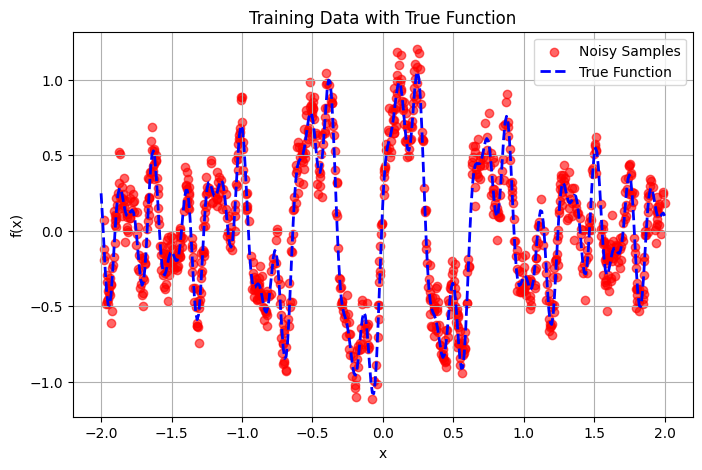

In [98]:
# Define the complex sinusoidal function
def complex_sinusoidal_function(x):
    return np.exp(-x**2) * np.sin(10*x) + 0.3 * np.sin(30*x) + 0.2 * np.cos(50*x)

# Generate training data
print("\nGenerating Data for Complex Sinusoidal Function")
x_train_tensor, y_train_tensor, x_train, y_train = generate_training_data(true_func=complex_sinusoidal_function)

# Plot training data
plot_training_data(x_train, y_train, true_func=complex_sinusoidal_function)


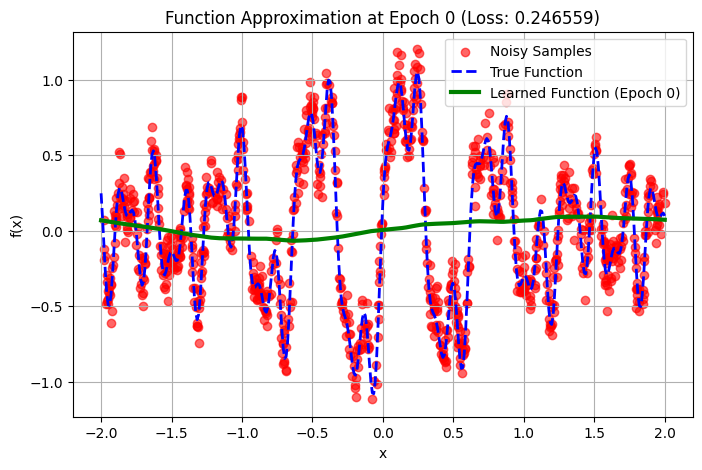

Epoch [1/401], Loss: 0.246559
Epoch [2/401], Loss: 0.228528
Epoch [3/401], Loss: 0.229134
Epoch [4/401], Loss: 0.220180
Epoch [5/401], Loss: 0.225677
Epoch [6/401], Loss: 0.222327
Epoch [7/401], Loss: 0.219910
Epoch [8/401], Loss: 0.226395
Epoch [9/401], Loss: 0.222777
Epoch [10/401], Loss: 0.217763
Epoch [11/401], Loss: 0.221774
Epoch [12/401], Loss: 0.221161
Epoch [13/401], Loss: 0.219481
Epoch [14/401], Loss: 0.220524
Epoch [15/401], Loss: 0.219463
Epoch [16/401], Loss: 0.220504
Epoch [17/401], Loss: 0.219133
Epoch [18/401], Loss: 0.219144
Epoch [19/401], Loss: 0.224102
Epoch [20/401], Loss: 0.219457
Epoch [21/401], Loss: 0.219021
Epoch [22/401], Loss: 0.218792
Epoch [23/401], Loss: 0.216762
Epoch [24/401], Loss: 0.218382
Epoch [25/401], Loss: 0.218119
Epoch [26/401], Loss: 0.214486
Epoch [27/401], Loss: 0.218161
Epoch [28/401], Loss: 0.215331
Epoch [29/401], Loss: 0.216085
Epoch [30/401], Loss: 0.217477
Epoch [31/401], Loss: 0.214713
Epoch [32/401], Loss: 0.220366
Epoch [33/401], L

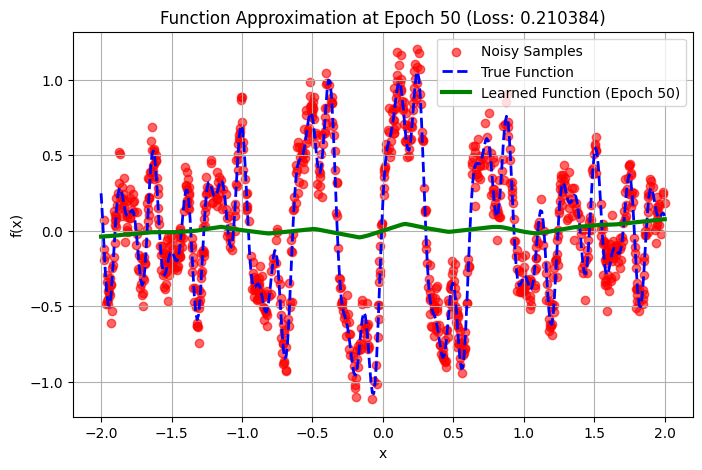

Epoch [51/401], Loss: 0.210384
Epoch [52/401], Loss: 0.214569
Epoch [53/401], Loss: 0.212794
Epoch [54/401], Loss: 0.210893
Epoch [55/401], Loss: 0.211063
Epoch [56/401], Loss: 0.213549
Epoch [57/401], Loss: 0.212322
Epoch [58/401], Loss: 0.211630
Epoch [59/401], Loss: 0.212270
Epoch [60/401], Loss: 0.213225
Epoch [61/401], Loss: 0.212902
Epoch [62/401], Loss: 0.217534
Epoch [63/401], Loss: 0.215130
Epoch [64/401], Loss: 0.207842
Epoch [65/401], Loss: 0.212887
Epoch [66/401], Loss: 0.214510
Epoch [67/401], Loss: 0.217089
Epoch [68/401], Loss: 0.212668
Epoch [69/401], Loss: 0.213529
Epoch [70/401], Loss: 0.213185
Epoch [71/401], Loss: 0.218395
Epoch [72/401], Loss: 0.212124
Epoch [73/401], Loss: 0.210889
Epoch [74/401], Loss: 0.209665
Epoch [75/401], Loss: 0.211811
Epoch [76/401], Loss: 0.211146
Epoch [77/401], Loss: 0.211084
Epoch [78/401], Loss: 0.207568
Epoch [79/401], Loss: 0.209841
Epoch [80/401], Loss: 0.211475
Epoch [81/401], Loss: 0.209540
Epoch [82/401], Loss: 0.215035
Epoch [8

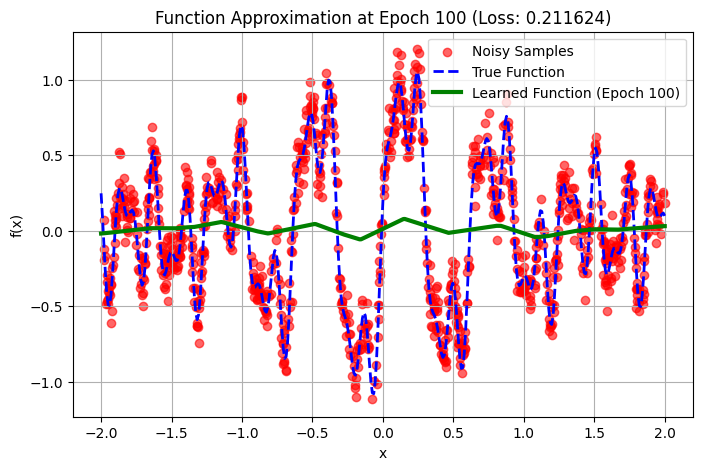

Epoch [101/401], Loss: 0.211624
Epoch [102/401], Loss: 0.215354
Epoch [103/401], Loss: 0.207555
Epoch [104/401], Loss: 0.211483
Epoch [105/401], Loss: 0.206345
Epoch [106/401], Loss: 0.211460
Epoch [107/401], Loss: 0.212776
Epoch [108/401], Loss: 0.206963
Epoch [109/401], Loss: 0.209540
Epoch [110/401], Loss: 0.209257
Epoch [111/401], Loss: 0.209572
Epoch [112/401], Loss: 0.211062
Epoch [113/401], Loss: 0.211096
Epoch [114/401], Loss: 0.204986
Epoch [115/401], Loss: 0.208946
Epoch [116/401], Loss: 0.206924
Epoch [117/401], Loss: 0.207059
Epoch [118/401], Loss: 0.206172
Epoch [119/401], Loss: 0.207444
Epoch [120/401], Loss: 0.211109
Epoch [121/401], Loss: 0.204065
Epoch [122/401], Loss: 0.206774
Epoch [123/401], Loss: 0.205740
Epoch [124/401], Loss: 0.205034
Epoch [125/401], Loss: 0.209981
Epoch [126/401], Loss: 0.208650
Epoch [127/401], Loss: 0.204286
Epoch [128/401], Loss: 0.205704
Epoch [129/401], Loss: 0.204893
Epoch [130/401], Loss: 0.206227
Epoch [131/401], Loss: 0.204301
Epoch [1

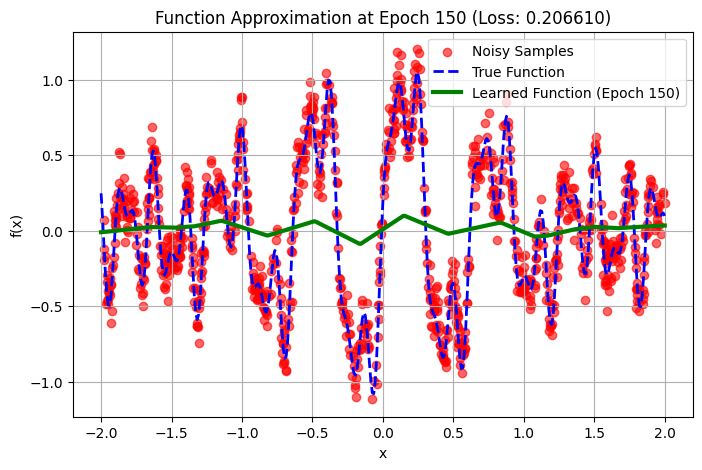

Epoch [151/401], Loss: 0.206610
Epoch [152/401], Loss: 0.205901
Epoch [153/401], Loss: 0.206180
Epoch [154/401], Loss: 0.203536
Epoch [155/401], Loss: 0.201287
Epoch [156/401], Loss: 0.204175
Epoch [157/401], Loss: 0.203113
Epoch [158/401], Loss: 0.208244
Epoch [159/401], Loss: 0.203310
Epoch [160/401], Loss: 0.201269
Epoch [161/401], Loss: 0.203051
Epoch [162/401], Loss: 0.201800
Epoch [163/401], Loss: 0.201552
Epoch [164/401], Loss: 0.208269
Epoch [165/401], Loss: 0.199160
Epoch [166/401], Loss: 0.202147
Epoch [167/401], Loss: 0.199341
Epoch [168/401], Loss: 0.206216
Epoch [169/401], Loss: 0.202267
Epoch [170/401], Loss: 0.202716
Epoch [171/401], Loss: 0.201869
Epoch [172/401], Loss: 0.205006
Epoch [173/401], Loss: 0.198548
Epoch [174/401], Loss: 0.201680
Epoch [175/401], Loss: 0.202953
Epoch [176/401], Loss: 0.209008
Epoch [177/401], Loss: 0.203055
Epoch [178/401], Loss: 0.203897
Epoch [179/401], Loss: 0.201057
Epoch [180/401], Loss: 0.202005
Epoch [181/401], Loss: 0.202279
Epoch [1

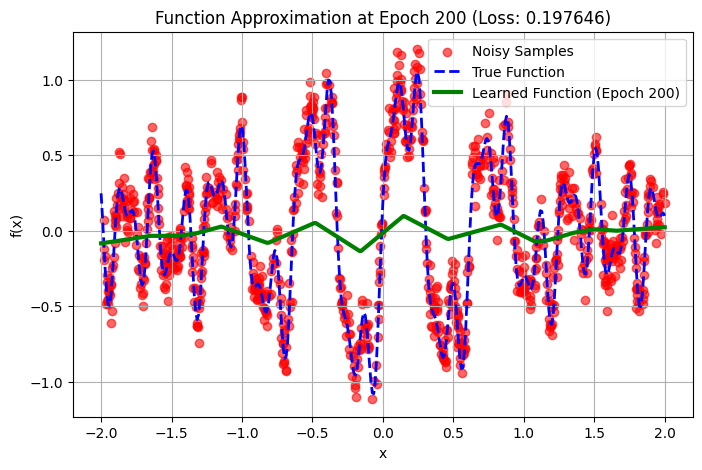

Epoch [201/401], Loss: 0.197646
Epoch [202/401], Loss: 0.200189
Epoch [203/401], Loss: 0.196685
Epoch [204/401], Loss: 0.199426
Epoch [205/401], Loss: 0.197838
Epoch [206/401], Loss: 0.197588
Epoch [207/401], Loss: 0.203113
Epoch [208/401], Loss: 0.199702
Epoch [209/401], Loss: 0.197036
Epoch [210/401], Loss: 0.197645
Epoch [211/401], Loss: 0.196345
Epoch [212/401], Loss: 0.197414
Epoch [213/401], Loss: 0.197063
Epoch [214/401], Loss: 0.196934
Epoch [215/401], Loss: 0.197107
Epoch [216/401], Loss: 0.197720
Epoch [217/401], Loss: 0.199430
Epoch [218/401], Loss: 0.196191
Epoch [219/401], Loss: 0.198874
Epoch [220/401], Loss: 0.198459
Epoch [221/401], Loss: 0.196159
Epoch [222/401], Loss: 0.196044
Epoch [223/401], Loss: 0.200324
Epoch [224/401], Loss: 0.196795
Epoch [225/401], Loss: 0.197151
Epoch [226/401], Loss: 0.194669
Epoch [227/401], Loss: 0.197888
Epoch [228/401], Loss: 0.193798
Epoch [229/401], Loss: 0.195413
Epoch [230/401], Loss: 0.196894
Epoch [231/401], Loss: 0.196317
Epoch [2

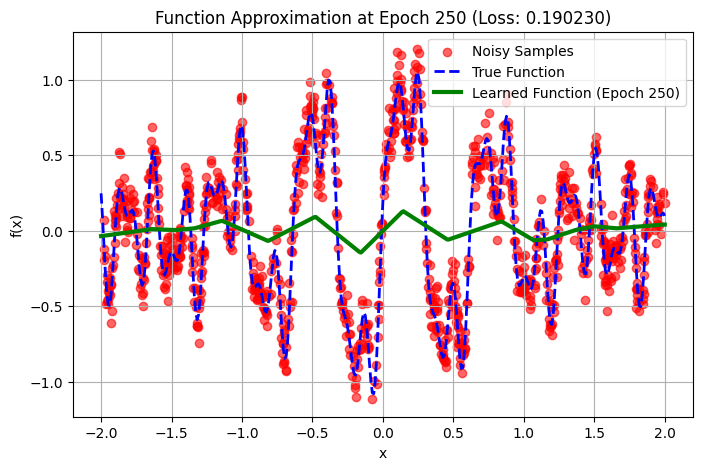

Epoch [251/401], Loss: 0.190230
Epoch [252/401], Loss: 0.194031
Epoch [253/401], Loss: 0.194114
Epoch [254/401], Loss: 0.192731
Epoch [255/401], Loss: 0.191628
Epoch [256/401], Loss: 0.192714
Epoch [257/401], Loss: 0.192285
Epoch [258/401], Loss: 0.191864
Epoch [259/401], Loss: 0.193107
Epoch [260/401], Loss: 0.190093
Epoch [261/401], Loss: 0.195247
Epoch [262/401], Loss: 0.195600
Epoch [263/401], Loss: 0.201860
Epoch [264/401], Loss: 0.195736
Epoch [265/401], Loss: 0.195105
Epoch [266/401], Loss: 0.190141
Epoch [267/401], Loss: 0.193673
Epoch [268/401], Loss: 0.194289
Epoch [269/401], Loss: 0.189602
Epoch [270/401], Loss: 0.194635
Epoch [271/401], Loss: 0.192582
Epoch [272/401], Loss: 0.190053
Epoch [273/401], Loss: 0.192156
Epoch [274/401], Loss: 0.194042
Epoch [275/401], Loss: 0.192362
Epoch [276/401], Loss: 0.193542
Epoch [277/401], Loss: 0.188354
Epoch [278/401], Loss: 0.192848
Epoch [279/401], Loss: 0.195444
Epoch [280/401], Loss: 0.193711
Epoch [281/401], Loss: 0.193359
Epoch [2

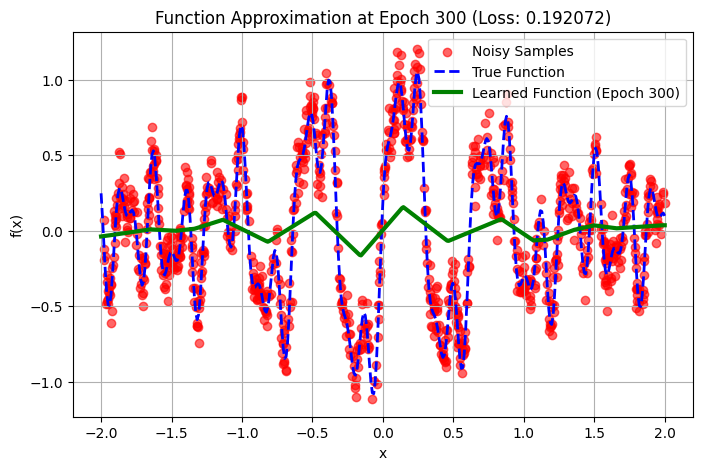

Epoch [301/401], Loss: 0.192072
Epoch [302/401], Loss: 0.185665
Epoch [303/401], Loss: 0.187783
Epoch [304/401], Loss: 0.187550
Epoch [305/401], Loss: 0.189682
Epoch [306/401], Loss: 0.187249
Epoch [307/401], Loss: 0.188727
Epoch [308/401], Loss: 0.186066
Epoch [309/401], Loss: 0.188007
Epoch [310/401], Loss: 0.190943
Epoch [311/401], Loss: 0.185637
Epoch [312/401], Loss: 0.188734
Epoch [313/401], Loss: 0.194941
Epoch [314/401], Loss: 0.187088
Epoch [315/401], Loss: 0.190708
Epoch [316/401], Loss: 0.190652
Epoch [317/401], Loss: 0.190691
Epoch [318/401], Loss: 0.192371
Epoch [319/401], Loss: 0.186015
Epoch [320/401], Loss: 0.191858
Epoch [321/401], Loss: 0.189220
Epoch [322/401], Loss: 0.186622
Epoch [323/401], Loss: 0.187640
Epoch [324/401], Loss: 0.188290
Epoch [325/401], Loss: 0.184062
Epoch [326/401], Loss: 0.188038
Epoch [327/401], Loss: 0.184289
Epoch [328/401], Loss: 0.188707
Epoch [329/401], Loss: 0.185912
Epoch [330/401], Loss: 0.189441
Epoch [331/401], Loss: 0.191160
Epoch [3

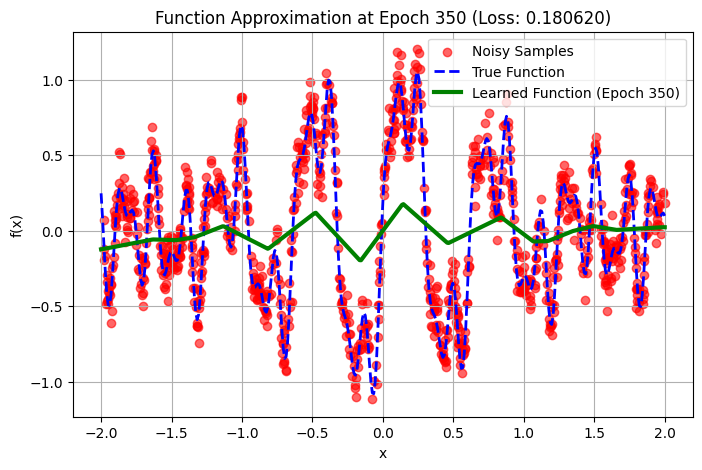

Epoch [351/401], Loss: 0.180620
Epoch [352/401], Loss: 0.184746
Epoch [353/401], Loss: 0.188703
Epoch [354/401], Loss: 0.184502
Epoch [355/401], Loss: 0.179211
Epoch [356/401], Loss: 0.182773
Epoch [357/401], Loss: 0.181919
Epoch [358/401], Loss: 0.184158
Epoch [359/401], Loss: 0.186179
Epoch [360/401], Loss: 0.184215
Epoch [361/401], Loss: 0.183833
Epoch [362/401], Loss: 0.183132
Epoch [363/401], Loss: 0.183973
Epoch [364/401], Loss: 0.182964
Epoch [365/401], Loss: 0.185645
Epoch [366/401], Loss: 0.183740
Epoch [367/401], Loss: 0.182046
Epoch [368/401], Loss: 0.182082
Epoch [369/401], Loss: 0.182373
Epoch [370/401], Loss: 0.179945
Epoch [371/401], Loss: 0.180933
Epoch [372/401], Loss: 0.182825
Epoch [373/401], Loss: 0.181608
Epoch [374/401], Loss: 0.181388
Epoch [375/401], Loss: 0.180083
Epoch [376/401], Loss: 0.178474
Epoch [377/401], Loss: 0.180904
Epoch [378/401], Loss: 0.183144
Epoch [379/401], Loss: 0.186891
Epoch [380/401], Loss: 0.182055
Epoch [381/401], Loss: 0.181759
Epoch [3

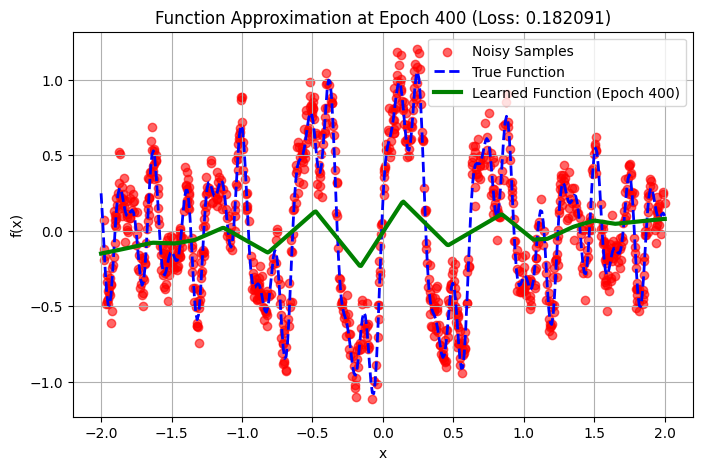

Epoch [401/401], Loss: 0.182091


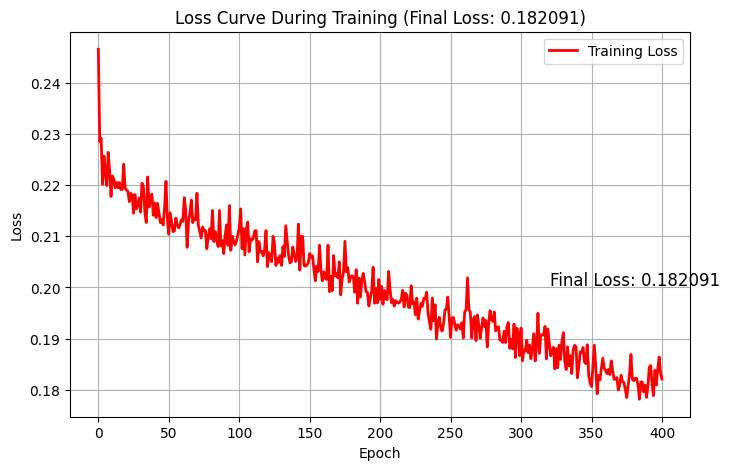

In [99]:
# TODO: Train Wide-Shallow Network
x = np.arange(-2,2,0.01).reshape(-1, 1)
y = complex_sinusoidal_function(x)

x_train_tensor_2 = torch.tensor(x,dtype = torch.float32)
y_train_tensor_2 = torch.tensor(y,dtype = torch.float32)

model = WideShallowNetwork()

num_epochs = 401
loss_history_WideShallowNetwork = train_model(model, x_train_tensor_2, y_train_tensor_2, true_function_1 = complex_sinusoidal_function, num_epochs = num_epochs, batch_size=32, lr=0.001 ,plot_interval= 50)



loss_value = loss_history_WideShallowNetwork[-1]

checkpoint = {
    "epoch": num_epochs,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": loss_value
}

torch.save(checkpoint, "/content/drive/MyDrive/DL_HW1/models/WideShallowNetwork.pth")

plot_loss_curve(loss_history_WideShallowNetwork)

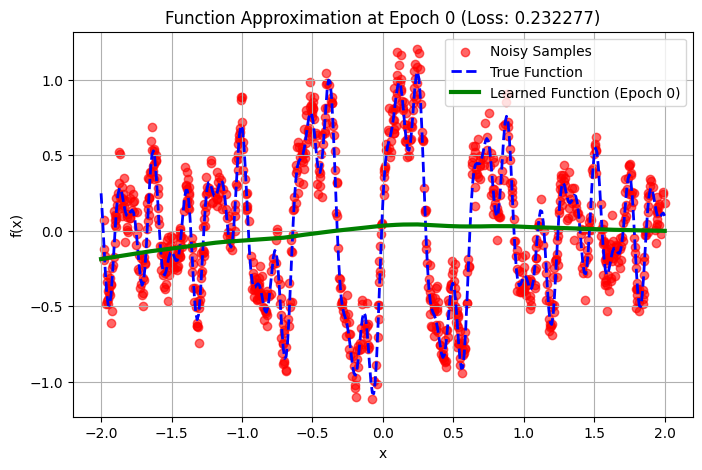

Epoch [1/401], Loss: 0.232277
Epoch [2/401], Loss: 0.221181
Epoch [3/401], Loss: 0.222267
Epoch [4/401], Loss: 0.220920
Epoch [5/401], Loss: 0.220639
Epoch [6/401], Loss: 0.221111
Epoch [7/401], Loss: 0.223743
Epoch [8/401], Loss: 0.219915
Epoch [9/401], Loss: 0.221327
Epoch [10/401], Loss: 0.216830
Epoch [11/401], Loss: 0.218840
Epoch [12/401], Loss: 0.216274
Epoch [13/401], Loss: 0.217829
Epoch [14/401], Loss: 0.214971
Epoch [15/401], Loss: 0.214713
Epoch [16/401], Loss: 0.219791
Epoch [17/401], Loss: 0.218736
Epoch [18/401], Loss: 0.215132
Epoch [19/401], Loss: 0.215155
Epoch [20/401], Loss: 0.212396
Epoch [21/401], Loss: 0.212625
Epoch [22/401], Loss: 0.208913
Epoch [23/401], Loss: 0.208713
Epoch [24/401], Loss: 0.206136
Epoch [25/401], Loss: 0.209649
Epoch [26/401], Loss: 0.204842
Epoch [27/401], Loss: 0.204606
Epoch [28/401], Loss: 0.203917
Epoch [29/401], Loss: 0.199659
Epoch [30/401], Loss: 0.205256
Epoch [31/401], Loss: 0.200748
Epoch [32/401], Loss: 0.197859
Epoch [33/401], L

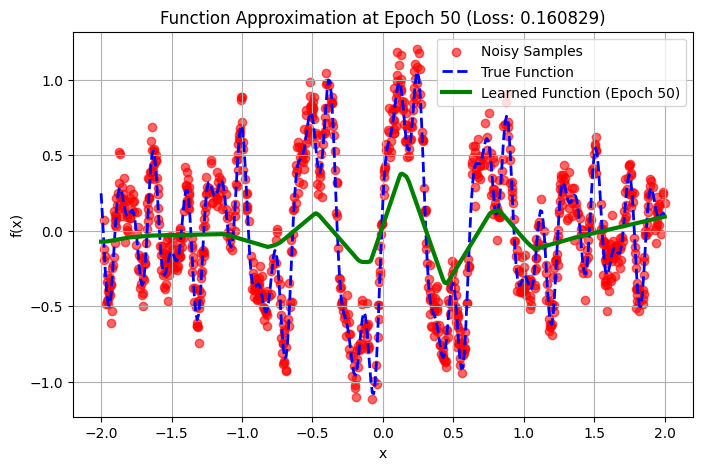

Epoch [51/401], Loss: 0.160829
Epoch [52/401], Loss: 0.161457
Epoch [53/401], Loss: 0.155193
Epoch [54/401], Loss: 0.152732
Epoch [55/401], Loss: 0.153398
Epoch [56/401], Loss: 0.151119
Epoch [57/401], Loss: 0.152266
Epoch [58/401], Loss: 0.149029
Epoch [59/401], Loss: 0.148327
Epoch [60/401], Loss: 0.142088
Epoch [61/401], Loss: 0.142285
Epoch [62/401], Loss: 0.142033
Epoch [63/401], Loss: 0.136707
Epoch [64/401], Loss: 0.135212
Epoch [65/401], Loss: 0.136057
Epoch [66/401], Loss: 0.130741
Epoch [67/401], Loss: 0.129359
Epoch [68/401], Loss: 0.125238
Epoch [69/401], Loss: 0.123581
Epoch [70/401], Loss: 0.122071
Epoch [71/401], Loss: 0.128097
Epoch [72/401], Loss: 0.124142
Epoch [73/401], Loss: 0.119447
Epoch [74/401], Loss: 0.118315
Epoch [75/401], Loss: 0.116293
Epoch [76/401], Loss: 0.111273
Epoch [77/401], Loss: 0.113084
Epoch [78/401], Loss: 0.108729
Epoch [79/401], Loss: 0.109012
Epoch [80/401], Loss: 0.107524
Epoch [81/401], Loss: 0.106123
Epoch [82/401], Loss: 0.107536
Epoch [8

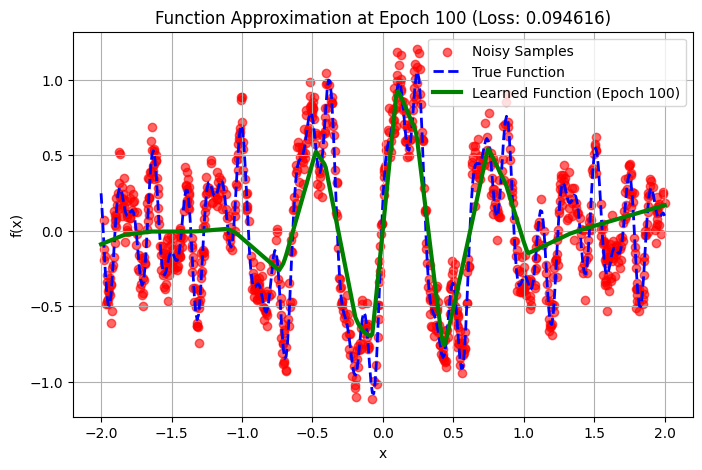

Epoch [101/401], Loss: 0.094616
Epoch [102/401], Loss: 0.091633
Epoch [103/401], Loss: 0.090344
Epoch [104/401], Loss: 0.089562
Epoch [105/401], Loss: 0.085120
Epoch [106/401], Loss: 0.086973
Epoch [107/401], Loss: 0.082316
Epoch [108/401], Loss: 0.084264
Epoch [109/401], Loss: 0.081682
Epoch [110/401], Loss: 0.084704
Epoch [111/401], Loss: 0.089326
Epoch [112/401], Loss: 0.086801
Epoch [113/401], Loss: 0.082629
Epoch [114/401], Loss: 0.079733
Epoch [115/401], Loss: 0.081108
Epoch [116/401], Loss: 0.079910
Epoch [117/401], Loss: 0.080352
Epoch [118/401], Loss: 0.081975
Epoch [119/401], Loss: 0.076426
Epoch [120/401], Loss: 0.080649
Epoch [121/401], Loss: 0.078041
Epoch [122/401], Loss: 0.076078
Epoch [123/401], Loss: 0.075359
Epoch [124/401], Loss: 0.077618
Epoch [125/401], Loss: 0.075783
Epoch [126/401], Loss: 0.080527
Epoch [127/401], Loss: 0.077858
Epoch [128/401], Loss: 0.078968
Epoch [129/401], Loss: 0.076317
Epoch [130/401], Loss: 0.074090
Epoch [131/401], Loss: 0.072277
Epoch [1

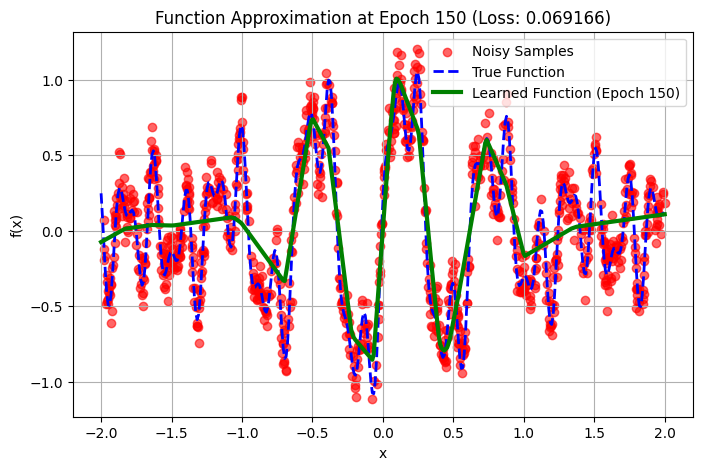

Epoch [151/401], Loss: 0.069166
Epoch [152/401], Loss: 0.068947
Epoch [153/401], Loss: 0.068817
Epoch [154/401], Loss: 0.068827
Epoch [155/401], Loss: 0.068281
Epoch [156/401], Loss: 0.069548
Epoch [157/401], Loss: 0.071423
Epoch [158/401], Loss: 0.071373
Epoch [159/401], Loss: 0.073701
Epoch [160/401], Loss: 0.072009
Epoch [161/401], Loss: 0.070781
Epoch [162/401], Loss: 0.071414
Epoch [163/401], Loss: 0.072071
Epoch [164/401], Loss: 0.069393
Epoch [165/401], Loss: 0.068402
Epoch [166/401], Loss: 0.066738
Epoch [167/401], Loss: 0.070547
Epoch [168/401], Loss: 0.068074
Epoch [169/401], Loss: 0.066952
Epoch [170/401], Loss: 0.068808
Epoch [171/401], Loss: 0.065826
Epoch [172/401], Loss: 0.065293
Epoch [173/401], Loss: 0.067122
Epoch [174/401], Loss: 0.068868
Epoch [175/401], Loss: 0.067861
Epoch [176/401], Loss: 0.065721
Epoch [177/401], Loss: 0.064369
Epoch [178/401], Loss: 0.064673
Epoch [179/401], Loss: 0.065698
Epoch [180/401], Loss: 0.071434
Epoch [181/401], Loss: 0.068123
Epoch [1

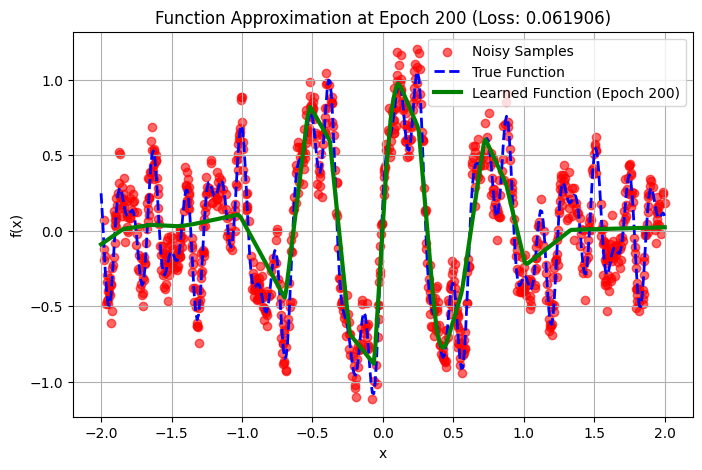

Epoch [201/401], Loss: 0.061906
Epoch [202/401], Loss: 0.062968
Epoch [203/401], Loss: 0.063525
Epoch [204/401], Loss: 0.062185
Epoch [205/401], Loss: 0.063444
Epoch [206/401], Loss: 0.063305
Epoch [207/401], Loss: 0.063055
Epoch [208/401], Loss: 0.063938
Epoch [209/401], Loss: 0.063432
Epoch [210/401], Loss: 0.060388
Epoch [211/401], Loss: 0.062048
Epoch [212/401], Loss: 0.062750
Epoch [213/401], Loss: 0.061222
Epoch [214/401], Loss: 0.061393
Epoch [215/401], Loss: 0.061131
Epoch [216/401], Loss: 0.064026
Epoch [217/401], Loss: 0.064027
Epoch [218/401], Loss: 0.061895
Epoch [219/401], Loss: 0.059418
Epoch [220/401], Loss: 0.062922
Epoch [221/401], Loss: 0.065093
Epoch [222/401], Loss: 0.065059
Epoch [223/401], Loss: 0.063776
Epoch [224/401], Loss: 0.068208
Epoch [225/401], Loss: 0.061350
Epoch [226/401], Loss: 0.063288
Epoch [227/401], Loss: 0.063025
Epoch [228/401], Loss: 0.063286
Epoch [229/401], Loss: 0.060066
Epoch [230/401], Loss: 0.059732
Epoch [231/401], Loss: 0.062707
Epoch [2

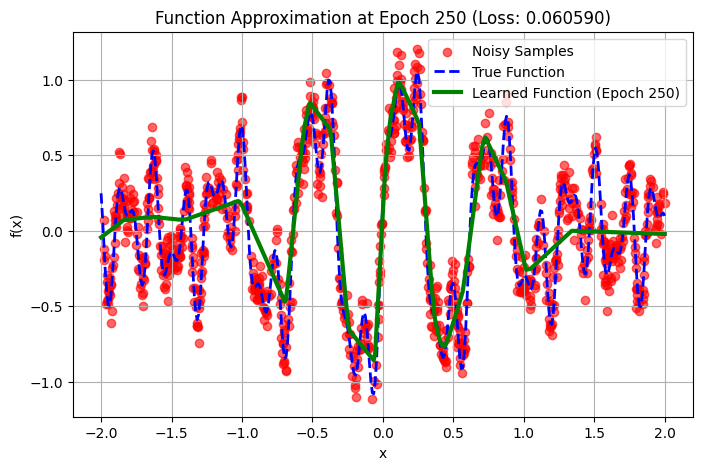

Epoch [251/401], Loss: 0.060590
Epoch [252/401], Loss: 0.060029
Epoch [253/401], Loss: 0.058006
Epoch [254/401], Loss: 0.058456
Epoch [255/401], Loss: 0.062483
Epoch [256/401], Loss: 0.061710
Epoch [257/401], Loss: 0.060181
Epoch [258/401], Loss: 0.057350
Epoch [259/401], Loss: 0.058231
Epoch [260/401], Loss: 0.059286
Epoch [261/401], Loss: 0.060795
Epoch [262/401], Loss: 0.058955
Epoch [263/401], Loss: 0.059934
Epoch [264/401], Loss: 0.059987
Epoch [265/401], Loss: 0.061438
Epoch [266/401], Loss: 0.059123
Epoch [267/401], Loss: 0.059533
Epoch [268/401], Loss: 0.056266
Epoch [269/401], Loss: 0.057031
Epoch [270/401], Loss: 0.058765
Epoch [271/401], Loss: 0.056617
Epoch [272/401], Loss: 0.058837
Epoch [273/401], Loss: 0.056458
Epoch [274/401], Loss: 0.060146
Epoch [275/401], Loss: 0.057778
Epoch [276/401], Loss: 0.060144
Epoch [277/401], Loss: 0.060167
Epoch [278/401], Loss: 0.057619
Epoch [279/401], Loss: 0.058482
Epoch [280/401], Loss: 0.058497
Epoch [281/401], Loss: 0.057826
Epoch [2

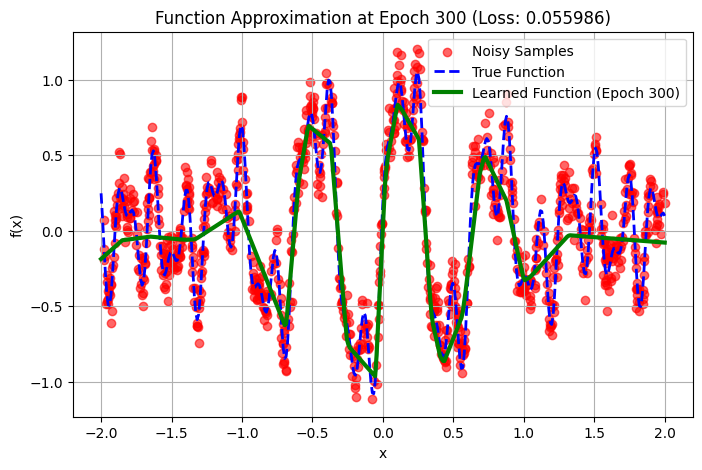

Epoch [301/401], Loss: 0.055986
Epoch [302/401], Loss: 0.056460
Epoch [303/401], Loss: 0.061129
Epoch [304/401], Loss: 0.057581
Epoch [305/401], Loss: 0.058721
Epoch [306/401], Loss: 0.055856
Epoch [307/401], Loss: 0.057960
Epoch [308/401], Loss: 0.055923
Epoch [309/401], Loss: 0.058165
Epoch [310/401], Loss: 0.058259
Epoch [311/401], Loss: 0.055888
Epoch [312/401], Loss: 0.055396
Epoch [313/401], Loss: 0.055038
Epoch [314/401], Loss: 0.056425
Epoch [315/401], Loss: 0.058699
Epoch [316/401], Loss: 0.058302
Epoch [317/401], Loss: 0.058748
Epoch [318/401], Loss: 0.054309
Epoch [319/401], Loss: 0.056762
Epoch [320/401], Loss: 0.057220
Epoch [321/401], Loss: 0.056730
Epoch [322/401], Loss: 0.060968
Epoch [323/401], Loss: 0.056709
Epoch [324/401], Loss: 0.060443
Epoch [325/401], Loss: 0.057060
Epoch [326/401], Loss: 0.056209
Epoch [327/401], Loss: 0.055213
Epoch [328/401], Loss: 0.057726
Epoch [329/401], Loss: 0.056023
Epoch [330/401], Loss: 0.058228
Epoch [331/401], Loss: 0.056792
Epoch [3

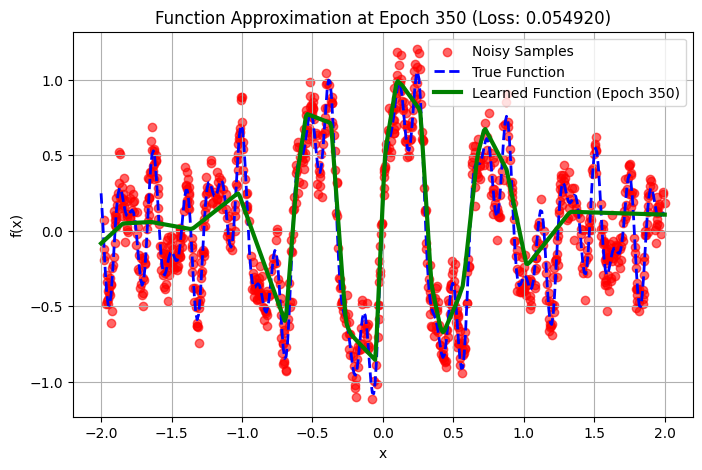

Epoch [351/401], Loss: 0.054920
Epoch [352/401], Loss: 0.055255
Epoch [353/401], Loss: 0.056813
Epoch [354/401], Loss: 0.054074
Epoch [355/401], Loss: 0.054058
Epoch [356/401], Loss: 0.055021
Epoch [357/401], Loss: 0.051988
Epoch [358/401], Loss: 0.055458
Epoch [359/401], Loss: 0.054317
Epoch [360/401], Loss: 0.052108
Epoch [361/401], Loss: 0.054997
Epoch [362/401], Loss: 0.056652
Epoch [363/401], Loss: 0.053387
Epoch [364/401], Loss: 0.054482
Epoch [365/401], Loss: 0.053573
Epoch [366/401], Loss: 0.053521
Epoch [367/401], Loss: 0.057696
Epoch [368/401], Loss: 0.053414
Epoch [369/401], Loss: 0.053811
Epoch [370/401], Loss: 0.057496
Epoch [371/401], Loss: 0.053998
Epoch [372/401], Loss: 0.058005
Epoch [373/401], Loss: 0.054775
Epoch [374/401], Loss: 0.054182
Epoch [375/401], Loss: 0.053225
Epoch [376/401], Loss: 0.053277
Epoch [377/401], Loss: 0.055866
Epoch [378/401], Loss: 0.057282
Epoch [379/401], Loss: 0.057380
Epoch [380/401], Loss: 0.055603
Epoch [381/401], Loss: 0.054921
Epoch [3

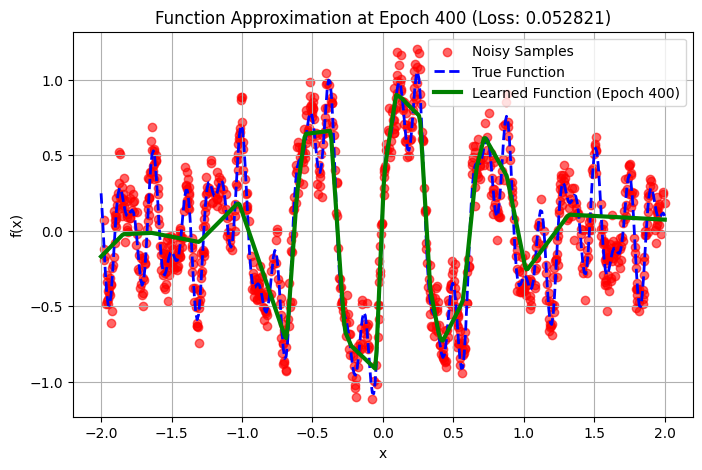

Epoch [401/401], Loss: 0.052821


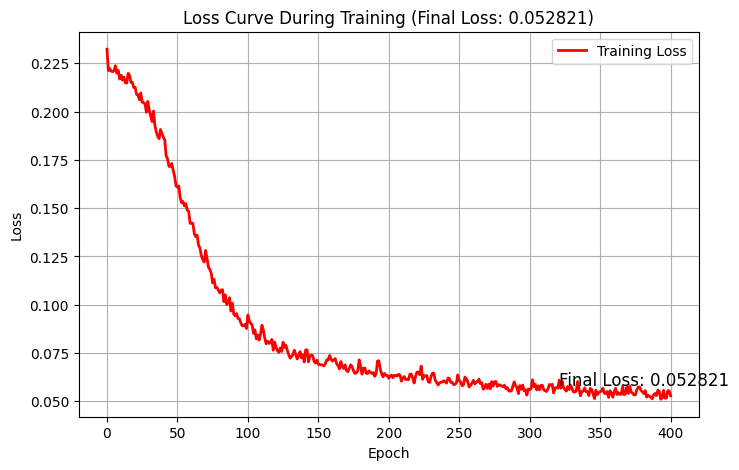

In [100]:
# TODO: Train Balanced Network
x = np.arange(-2,2,0.01).reshape(-1, 1)
y = complex_sinusoidal_function(x)

x_train_tensor_2 = torch.tensor(x,dtype = torch.float32)
y_train_tensor_2 = torch.tensor(y,dtype = torch.float32)

model = BalancedNetwork()

num_epochs = 401
loss_history_BalancedNetwork = train_model(model, x_train_tensor_2, y_train_tensor_2, true_function_1 = complex_sinusoidal_function, num_epochs = num_epochs, batch_size=32, lr=0.001 ,plot_interval= 50)

loss_value = loss_history_BalancedNetwork[-1]

checkpoint = {
    "epoch": num_epochs,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": loss_value
}

torch.save(checkpoint, "/content/drive/MyDrive/DL_HW1/models/BalancedNetwork.pth")

plot_loss_curve(loss_history_BalancedNetwork)

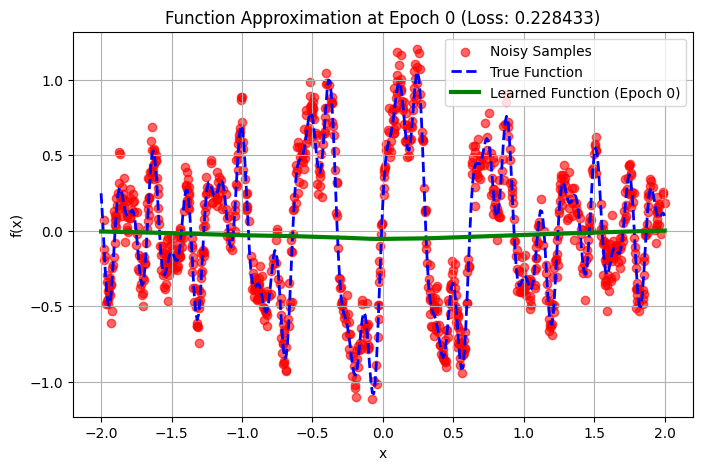

Epoch [1/401], Loss: 0.228433
Epoch [2/401], Loss: 0.224154
Epoch [3/401], Loss: 0.222013
Epoch [4/401], Loss: 0.220942
Epoch [5/401], Loss: 0.225302
Epoch [6/401], Loss: 0.219794
Epoch [7/401], Loss: 0.220889
Epoch [8/401], Loss: 0.224223
Epoch [9/401], Loss: 0.221698
Epoch [10/401], Loss: 0.218201
Epoch [11/401], Loss: 0.216993
Epoch [12/401], Loss: 0.221091
Epoch [13/401], Loss: 0.221784
Epoch [14/401], Loss: 0.221433
Epoch [15/401], Loss: 0.216847
Epoch [16/401], Loss: 0.212718
Epoch [17/401], Loss: 0.216678
Epoch [18/401], Loss: 0.214848
Epoch [19/401], Loss: 0.213153
Epoch [20/401], Loss: 0.210689
Epoch [21/401], Loss: 0.214829
Epoch [22/401], Loss: 0.215100
Epoch [23/401], Loss: 0.208250
Epoch [24/401], Loss: 0.206012
Epoch [25/401], Loss: 0.207887
Epoch [26/401], Loss: 0.204803
Epoch [27/401], Loss: 0.198162
Epoch [28/401], Loss: 0.192138
Epoch [29/401], Loss: 0.191087
Epoch [30/401], Loss: 0.188682
Epoch [31/401], Loss: 0.179338
Epoch [32/401], Loss: 0.177791
Epoch [33/401], L

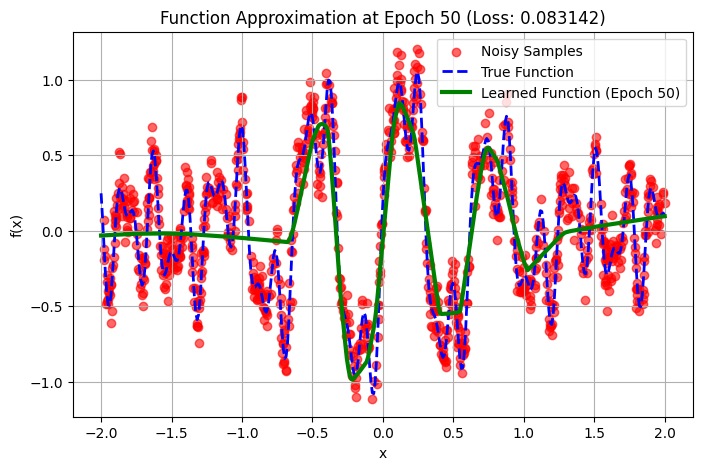

Epoch [51/401], Loss: 0.083142
Epoch [52/401], Loss: 0.080425
Epoch [53/401], Loss: 0.080899
Epoch [54/401], Loss: 0.078783
Epoch [55/401], Loss: 0.079476
Epoch [56/401], Loss: 0.077573
Epoch [57/401], Loss: 0.075197
Epoch [58/401], Loss: 0.072726
Epoch [59/401], Loss: 0.075815
Epoch [60/401], Loss: 0.073432
Epoch [61/401], Loss: 0.075570
Epoch [62/401], Loss: 0.071655
Epoch [63/401], Loss: 0.069649
Epoch [64/401], Loss: 0.068513
Epoch [65/401], Loss: 0.068258
Epoch [66/401], Loss: 0.070347
Epoch [67/401], Loss: 0.068930
Epoch [68/401], Loss: 0.069496
Epoch [69/401], Loss: 0.071005
Epoch [70/401], Loss: 0.070378
Epoch [71/401], Loss: 0.069659
Epoch [72/401], Loss: 0.065604
Epoch [73/401], Loss: 0.069582
Epoch [74/401], Loss: 0.065281
Epoch [75/401], Loss: 0.062268
Epoch [76/401], Loss: 0.064828
Epoch [77/401], Loss: 0.063191
Epoch [78/401], Loss: 0.064561
Epoch [79/401], Loss: 0.063008
Epoch [80/401], Loss: 0.064868
Epoch [81/401], Loss: 0.063540
Epoch [82/401], Loss: 0.062017
Epoch [8

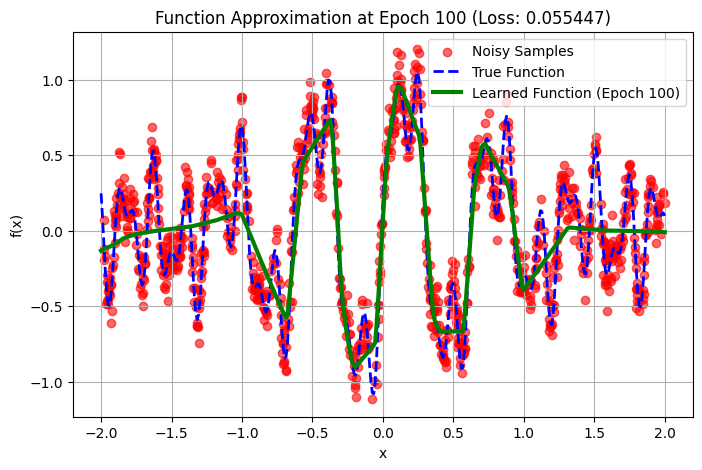

Epoch [101/401], Loss: 0.055447
Epoch [102/401], Loss: 0.056045
Epoch [103/401], Loss: 0.056829
Epoch [104/401], Loss: 0.056376
Epoch [105/401], Loss: 0.056082
Epoch [106/401], Loss: 0.055319
Epoch [107/401], Loss: 0.057355
Epoch [108/401], Loss: 0.056832
Epoch [109/401], Loss: 0.054607
Epoch [110/401], Loss: 0.054722
Epoch [111/401], Loss: 0.054809
Epoch [112/401], Loss: 0.051949
Epoch [113/401], Loss: 0.053107
Epoch [114/401], Loss: 0.051812
Epoch [115/401], Loss: 0.053711
Epoch [116/401], Loss: 0.057379
Epoch [117/401], Loss: 0.054871
Epoch [118/401], Loss: 0.055413
Epoch [119/401], Loss: 0.052988
Epoch [120/401], Loss: 0.051442
Epoch [121/401], Loss: 0.054198
Epoch [122/401], Loss: 0.053193
Epoch [123/401], Loss: 0.051066
Epoch [124/401], Loss: 0.051573
Epoch [125/401], Loss: 0.052033
Epoch [126/401], Loss: 0.050507
Epoch [127/401], Loss: 0.052266
Epoch [128/401], Loss: 0.049994
Epoch [129/401], Loss: 0.050509
Epoch [130/401], Loss: 0.051488
Epoch [131/401], Loss: 0.050446
Epoch [1

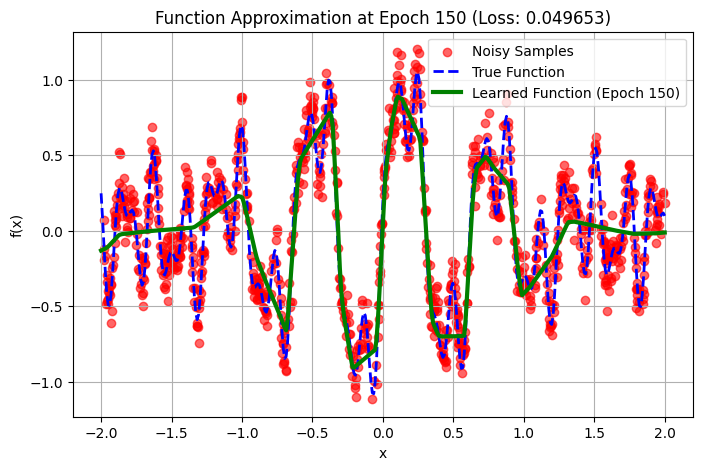

Epoch [151/401], Loss: 0.049653
Epoch [152/401], Loss: 0.049915
Epoch [153/401], Loss: 0.048978
Epoch [154/401], Loss: 0.050170
Epoch [155/401], Loss: 0.049199
Epoch [156/401], Loss: 0.050216
Epoch [157/401], Loss: 0.048667
Epoch [158/401], Loss: 0.048838
Epoch [159/401], Loss: 0.048005
Epoch [160/401], Loss: 0.048057
Epoch [161/401], Loss: 0.051159
Epoch [162/401], Loss: 0.049558
Epoch [163/401], Loss: 0.048170
Epoch [164/401], Loss: 0.050134
Epoch [165/401], Loss: 0.048893
Epoch [166/401], Loss: 0.048286
Epoch [167/401], Loss: 0.050174
Epoch [168/401], Loss: 0.050228
Epoch [169/401], Loss: 0.048685
Epoch [170/401], Loss: 0.047397
Epoch [171/401], Loss: 0.047379
Epoch [172/401], Loss: 0.047815
Epoch [173/401], Loss: 0.048042
Epoch [174/401], Loss: 0.048280
Epoch [175/401], Loss: 0.047418
Epoch [176/401], Loss: 0.047668
Epoch [177/401], Loss: 0.046525
Epoch [178/401], Loss: 0.048051
Epoch [179/401], Loss: 0.045598
Epoch [180/401], Loss: 0.049383
Epoch [181/401], Loss: 0.049427
Epoch [1

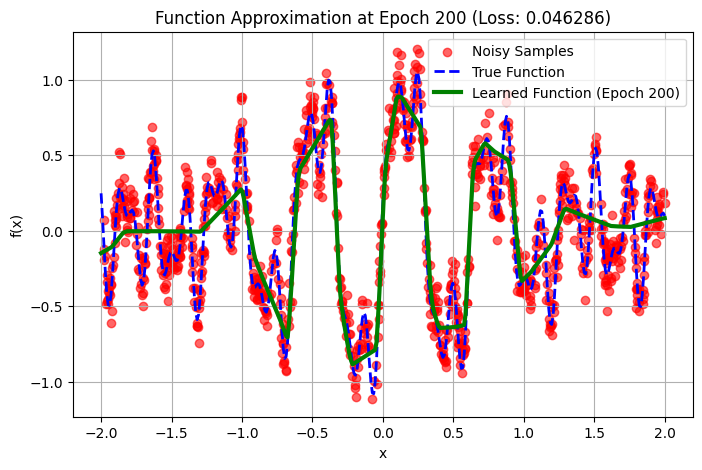

Epoch [201/401], Loss: 0.046286
Epoch [202/401], Loss: 0.047378
Epoch [203/401], Loss: 0.048332
Epoch [204/401], Loss: 0.052456
Epoch [205/401], Loss: 0.049567
Epoch [206/401], Loss: 0.052012
Epoch [207/401], Loss: 0.047406
Epoch [208/401], Loss: 0.048029
Epoch [209/401], Loss: 0.047263
Epoch [210/401], Loss: 0.047267
Epoch [211/401], Loss: 0.045572
Epoch [212/401], Loss: 0.047072
Epoch [213/401], Loss: 0.047353
Epoch [214/401], Loss: 0.045639
Epoch [215/401], Loss: 0.046218
Epoch [216/401], Loss: 0.045794
Epoch [217/401], Loss: 0.045241
Epoch [218/401], Loss: 0.045306
Epoch [219/401], Loss: 0.044760
Epoch [220/401], Loss: 0.046071
Epoch [221/401], Loss: 0.045525
Epoch [222/401], Loss: 0.044072
Epoch [223/401], Loss: 0.044969
Epoch [224/401], Loss: 0.044770
Epoch [225/401], Loss: 0.045844
Epoch [226/401], Loss: 0.045078
Epoch [227/401], Loss: 0.046526
Epoch [228/401], Loss: 0.045564
Epoch [229/401], Loss: 0.045957
Epoch [230/401], Loss: 0.045741
Epoch [231/401], Loss: 0.047671
Epoch [2

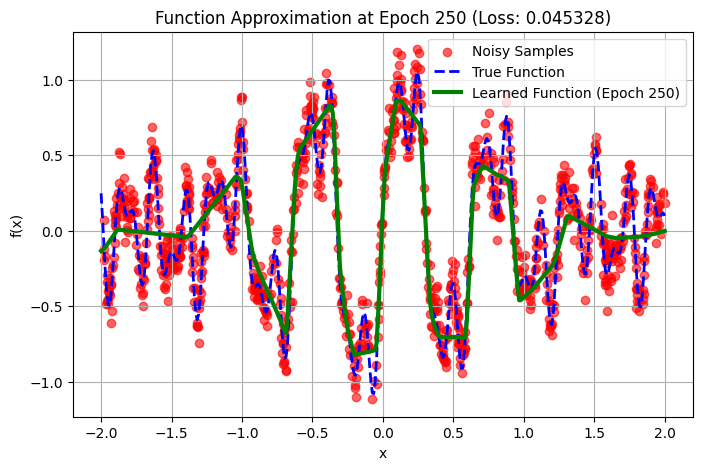

Epoch [251/401], Loss: 0.045328
Epoch [252/401], Loss: 0.047911
Epoch [253/401], Loss: 0.045227
Epoch [254/401], Loss: 0.046601
Epoch [255/401], Loss: 0.044890
Epoch [256/401], Loss: 0.045533
Epoch [257/401], Loss: 0.045052
Epoch [258/401], Loss: 0.043219
Epoch [259/401], Loss: 0.050054
Epoch [260/401], Loss: 0.045581
Epoch [261/401], Loss: 0.045900
Epoch [262/401], Loss: 0.044059
Epoch [263/401], Loss: 0.043778
Epoch [264/401], Loss: 0.042878
Epoch [265/401], Loss: 0.043462
Epoch [266/401], Loss: 0.046733
Epoch [267/401], Loss: 0.044618
Epoch [268/401], Loss: 0.043048
Epoch [269/401], Loss: 0.043137
Epoch [270/401], Loss: 0.045235
Epoch [271/401], Loss: 0.044763
Epoch [272/401], Loss: 0.046666
Epoch [273/401], Loss: 0.044482
Epoch [274/401], Loss: 0.042436
Epoch [275/401], Loss: 0.045002
Epoch [276/401], Loss: 0.047158
Epoch [277/401], Loss: 0.046822
Epoch [278/401], Loss: 0.044939
Epoch [279/401], Loss: 0.043390
Epoch [280/401], Loss: 0.043379
Epoch [281/401], Loss: 0.042483
Epoch [2

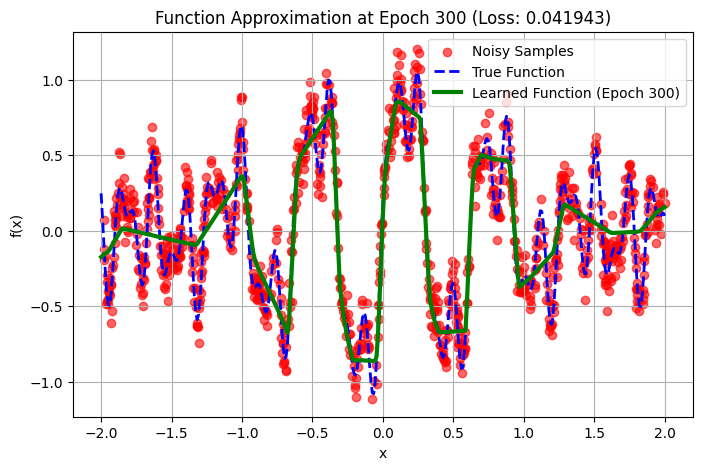

Epoch [301/401], Loss: 0.041943
Epoch [302/401], Loss: 0.043657
Epoch [303/401], Loss: 0.044288
Epoch [304/401], Loss: 0.042672
Epoch [305/401], Loss: 0.043743
Epoch [306/401], Loss: 0.042876
Epoch [307/401], Loss: 0.043861
Epoch [308/401], Loss: 0.043285
Epoch [309/401], Loss: 0.045160
Epoch [310/401], Loss: 0.043079
Epoch [311/401], Loss: 0.042164
Epoch [312/401], Loss: 0.043021
Epoch [313/401], Loss: 0.044585
Epoch [314/401], Loss: 0.042222
Epoch [315/401], Loss: 0.041971
Epoch [316/401], Loss: 0.041968
Epoch [317/401], Loss: 0.041554
Epoch [318/401], Loss: 0.041445
Epoch [319/401], Loss: 0.041824
Epoch [320/401], Loss: 0.042714
Epoch [321/401], Loss: 0.042112
Epoch [322/401], Loss: 0.041963
Epoch [323/401], Loss: 0.043746
Epoch [324/401], Loss: 0.042267
Epoch [325/401], Loss: 0.043981
Epoch [326/401], Loss: 0.042317
Epoch [327/401], Loss: 0.044556
Epoch [328/401], Loss: 0.042925
Epoch [329/401], Loss: 0.041796
Epoch [330/401], Loss: 0.043383
Epoch [331/401], Loss: 0.043866
Epoch [3

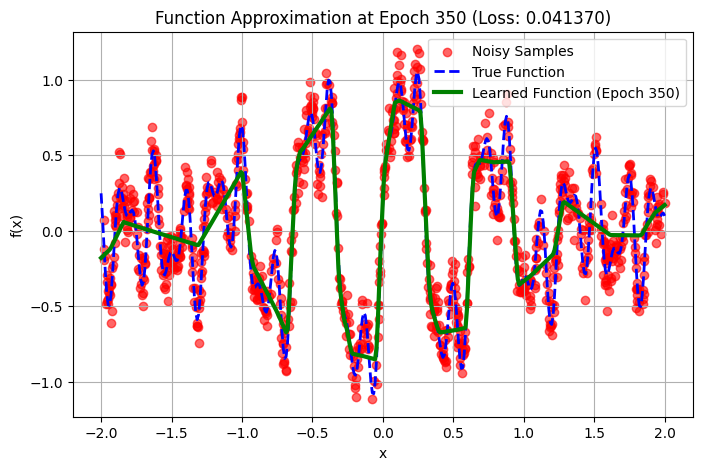

Epoch [351/401], Loss: 0.041370
Epoch [352/401], Loss: 0.041971
Epoch [353/401], Loss: 0.042433
Epoch [354/401], Loss: 0.041120
Epoch [355/401], Loss: 0.042103
Epoch [356/401], Loss: 0.042176
Epoch [357/401], Loss: 0.041618
Epoch [358/401], Loss: 0.040968
Epoch [359/401], Loss: 0.041161
Epoch [360/401], Loss: 0.039979
Epoch [361/401], Loss: 0.041223
Epoch [362/401], Loss: 0.043287
Epoch [363/401], Loss: 0.042771
Epoch [364/401], Loss: 0.041623
Epoch [365/401], Loss: 0.042090
Epoch [366/401], Loss: 0.042738
Epoch [367/401], Loss: 0.041882
Epoch [368/401], Loss: 0.041542
Epoch [369/401], Loss: 0.041383
Epoch [370/401], Loss: 0.042008
Epoch [371/401], Loss: 0.042386
Epoch [372/401], Loss: 0.044913
Epoch [373/401], Loss: 0.042551
Epoch [374/401], Loss: 0.042405
Epoch [375/401], Loss: 0.041214
Epoch [376/401], Loss: 0.042545
Epoch [377/401], Loss: 0.042830
Epoch [378/401], Loss: 0.041883
Epoch [379/401], Loss: 0.041160
Epoch [380/401], Loss: 0.043004
Epoch [381/401], Loss: 0.041526
Epoch [3

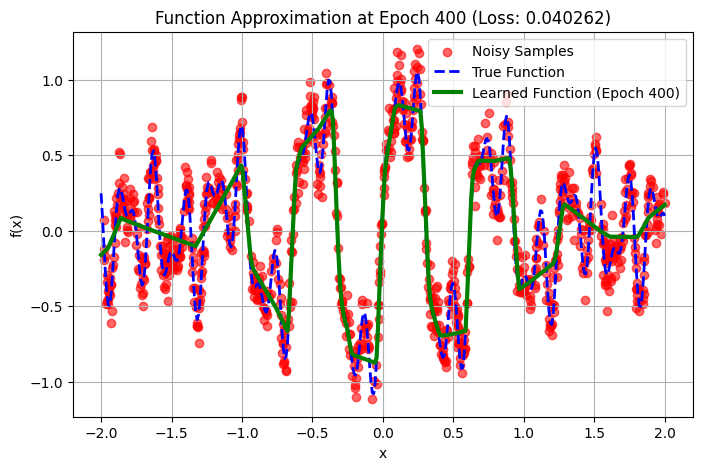

Epoch [401/401], Loss: 0.040262


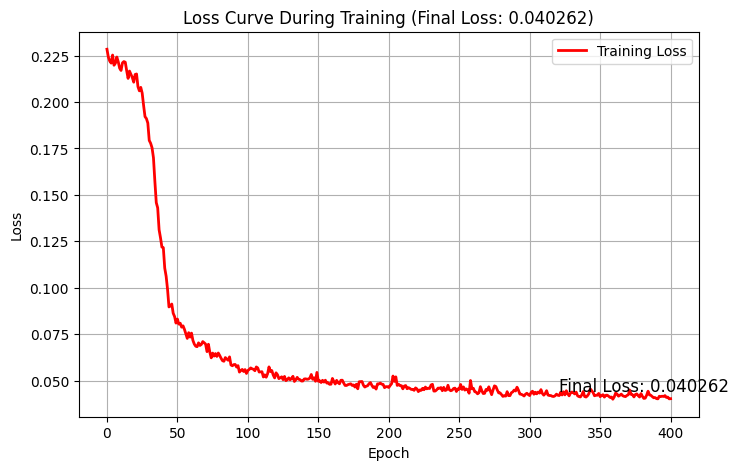

In [101]:
# TODO: Train Deep-Narrow Network
x = np.arange(-2,2,0.01).reshape(-1, 1)
y = complex_sinusoidal_function(x)

x_train_tensor_2 = torch.tensor(x,dtype = torch.float32)
y_train_tensor_2 = torch.tensor(y,dtype = torch.float32)

model = DeepNarrowNetwork()

num_epochs = 401
loss_history_DeepNarrowNetwork = train_model(model, x_train_tensor_2, y_train_tensor_2, true_function_1 = complex_sinusoidal_function, num_epochs = num_epochs, batch_size=32, lr=0.001,plot_interval= 50 )

loss_value = loss_history_DeepNarrowNetwork[-1]

checkpoint = {
    "epoch": num_epochs,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": loss_value
}

torch.save(checkpoint, "/content/drive/MyDrive/DL_HW1/models/DeepNarrowNetwork.pth")

plot_loss_curve(loss_history_DeepNarrowNetwork)

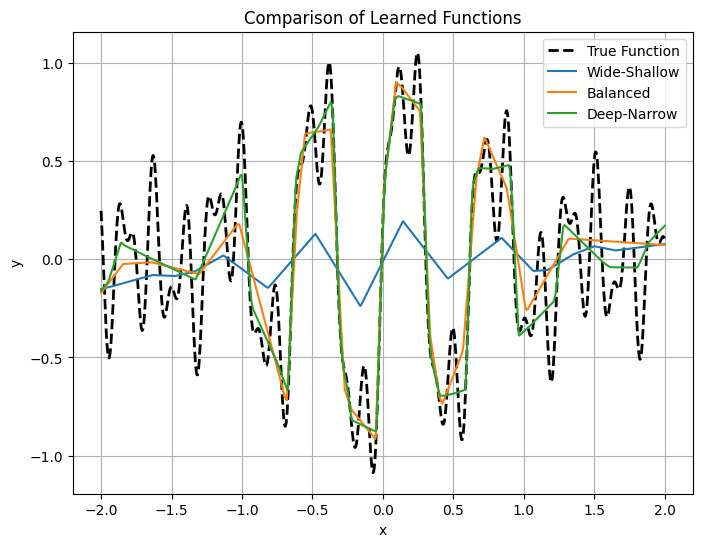

In [102]:
# TODO: create a function named compare_learned_functions
# and plot the output of three models in one plot to compare them with the real funtion

def compare_learned_functions(model_paths, labels, true_function, model_classes):
    x_values = np.linspace(-2, 2, 1000)
    y_true = true_function(x_values)

    plt.figure(figsize=(8, 6))
    plt.plot(x_values, y_true, label='True Function', linestyle='dashed', linewidth=2, color='black')

    for model_path, label, model_class in zip(model_paths, labels, model_classes):
        model = model_class()

        checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
        model.load_state_dict(checkpoint["model_state_dict"])
        model.eval()
        with torch.no_grad():
            x_tensor = torch.tensor(x_values, dtype=torch.float32).unsqueeze(1)
            y_pred = model(x_tensor).squeeze().numpy()

        plt.plot(x_values, y_pred, label=label)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Comparison of Learned Functions')
    plt.legend()
    plt.grid(True)
    plt.show()


model_paths = [
    "/content/drive/MyDrive/DL_HW1/models/WideShallowNetwork.pth",
    "/content/drive/MyDrive/DL_HW1/models/BalancedNetwork.pth",
    "/content/drive/MyDrive/DL_HW1/models/DeepNarrowNetwork.pth"
]

labels = ["Wide-Shallow", "Balanced", "Deep-Narrow"]

model_classes = [WideShallowNetwork, BalancedNetwork, DeepNarrowNetwork]

compare_learned_functions(model_paths, labels, complex_sinusoidal_function,model_classes)



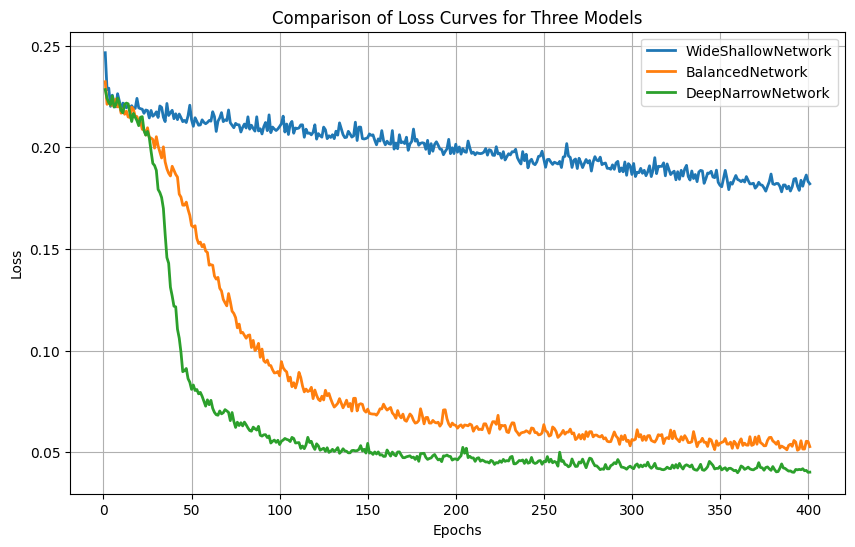

In [103]:
# TODO: Plot the loss of three models in one plot to compare them
compare_loss_curves(loss_history_WideShallowNetwork,loss_history_BalancedNetwork,loss_history_DeepNarrowNetwork,labels=['WideShallowNetwork','BalancedNetwork','DeepNarrowNetwork'])


# MNIST Classification (10 points)
In the next part we will use MNIST data and train a model to classify the digits.

## Step 1: Load and Preprocess the MNIST Dataset


Before training our model, we need to load the MNIST dataset. The MNIST dataset consists of 60,000 training images and 10,000 test images of handwritten digits (0-9). Each image is 28×28 pixels in grayscale.

We'll use PyTorch's `torchvision.datasets` module to download and load the dataset. We also need to transform the images into tensors and normalize them to improve training stability.

### 🔹 Data Preprocessing
- Convert images to tensors using `ToTensor()`.
- Normalize images to have zero mean and unit variance using `Normalize()`.
- Use PyTorch's `DataLoader` to efficiently load the dataset in batches.


In [104]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# TODO: Define transformation: convert images to tensors and normalize them
# Then download and load the training and test datasets using the transform
# Convert to DataLoaders for batch processing

transform = transforms.Compose([
        transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='/content/drive/MyDrive/DL_HW1/data_MNIST', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='/content/drive/MyDrive/DL_HW1/data_MNIST', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)



# End of TODO
# Check dataset size
print(f"Training dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")


Training dataset size: 60000
Test dataset size: 10000


## Step 2: Define a Simple MLP Model


Now that we have the MNIST dataset ready, we will define a simple feedforward neural network (MLP) to classify the digits.

### 🔹 Model Architecture
- **Input Layer**: 28x28 pixels (flattened to 784)
- **Hidden Layers**: Two fully connected layers (Linear layers)
- **Activation Function**: ReLU for non-linearity
- **Output Layer**: 10 neurons (one per digit), using Softmax




In [105]:
import torch.nn as nn
import torch.nn.functional as F

# TODO: Define a simple MLP model that gets the image and outputs 10 numbers (logits)
# No softmax needed (handled in loss function)

class SimpleMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, output_dim = 10):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim) #1
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# END of TODO

## Step 3: Train the MLP Model and Visualize Layer Activations


Now that we have defined our MLP model, we need to:
1. **Train** the model on MNIST.
2. **Capture activations** from each layer after every epoch.
3. **Reduce activation dimensions** using **t-SNE**.
4. **Visualize** the transformed activations in 2D.

### 🔹 Why Visualize Activations?
- Helps understand how the network **transforms** input data.
- Detects potential issues like **vanishing activations** or **saturation**.
- Gives insights into **how different layers learn representations**.


In [106]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch.optim as optim
from tqdm import tqdm  # Progress bar

# Define device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model, loss function, and optimizer
model = SimpleMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
num_epochs = 31
for epoch in range(num_epochs):
  for x_batch, y_batch in train_loader:

      x_batch, y_batch = x_batch.to(device), y_batch.to(device)


      y_hat = model(x_batch.view(x_batch.shape[0], -1))  # Flatten کردن ورودی


      loss = criterion(y_hat, y_batch)


      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

  print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [1/31], Loss: 0.1925
Epoch [2/31], Loss: 0.0360
Epoch [3/31], Loss: 0.0467
Epoch [4/31], Loss: 0.1047
Epoch [5/31], Loss: 0.1187
Epoch [6/31], Loss: 0.0997
Epoch [7/31], Loss: 0.0377
Epoch [8/31], Loss: 0.0154
Epoch [9/31], Loss: 0.0886
Epoch [10/31], Loss: 0.0027
Epoch [11/31], Loss: 0.0027
Epoch [12/31], Loss: 0.0097
Epoch [13/31], Loss: 0.0132
Epoch [14/31], Loss: 0.0529
Epoch [15/31], Loss: 0.0478
Epoch [16/31], Loss: 0.0230
Epoch [17/31], Loss: 0.0761
Epoch [18/31], Loss: 0.0085
Epoch [19/31], Loss: 0.0012
Epoch [20/31], Loss: 0.0099
Epoch [21/31], Loss: 0.0920
Epoch [22/31], Loss: 0.0024
Epoch [23/31], Loss: 0.0006
Epoch [24/31], Loss: 0.0748
Epoch [25/31], Loss: 0.0731
Epoch [26/31], Loss: 0.0065
Epoch [27/31], Loss: 0.0118
Epoch [28/31], Loss: 0.0002
Epoch [29/31], Loss: 0.0014
Epoch [30/31], Loss: 0.0008
Epoch [31/31], Loss: 0.0003


In [107]:
# TODO:
# Implement functionality to capture activations from specific layers of a neural network model.
# 1. Initialize a data structure to store activations from layers like "fc1", "fc2", and "fc3".
# 2. Define a hook function that:
#    - Captures the output of a given layer.
#    - Detaches it from the computation graph, moves it to the CPU, and converts it to a NumPy array.
#    - Stores the result in the activation data structure.
# 3. Register this hook function to the target layers using PyTorch's `register_forward_hook`.


import torch
import numpy as np

activation = {}

def get_activation(name):

    def hook(model, input, output):
        activation[name] = output.detach().cpu().numpy()
    return hook


model.fc1.register_forward_hook(get_activation('fc1'))
model.fc2.register_forward_hook(get_activation('fc2'))
model.fc3.register_forward_hook(get_activation('fc3'))


In [108]:
# TODO: Implement a function to visualize neural network activations across layers.
# The function should:
# 1. Accept activation data from various layers and the current epoch.
# 2. Perform dimensionality reduction on activations using t-SNE.
# 3. Efficiently sample a subset of activations for performance.
# 4. Create subplots for t-SNE visualizations for each layer.
# 5. Use appropriate color maps, labels, and titles for clarity.
# 6. Display the visualizations in a well-organized layout.



def plot_activations(activation_data, epoch):
    layers = list(activation_data.keys())
    num_layers = len(layers)

    fig, axes = plt.subplots(1, num_layers, figsize=(5 * num_layers, 4))
    if num_layers == 1:
        axes = [axes]

    for ax, layer in zip(axes, layers):
        activations_layer = activation_data[layer]

        if activations_layer.ndim > 2:
            activations_layer = activations_layer.reshape(activations_layer.shape[0], -1)

        sample_size = 1000
        if activations_layer.shape[0] > sample_size:
            indices = np.random.choice(activations_layer.shape[0], sample_size, replace=False)
            activations_sampled = activations_layer[indices]
        else:
            activations_sampled = activations_layer

        tsne = TSNE(n_components=2, random_state=42)
        activations_2d = tsne.fit_transform(activations_sampled)

        ax.scatter(activations_2d[:, 0], activations_2d[:, 1], c='viridis', alpha=0.6, s=10)
        ax.set_title(f"t-SNE of {layer} activations (Epoch {epoch})")
        ax.set_xlabel("Dimension 1")
        ax.set_ylabel("Dimension 2")

    plt.tight_layout()
    plt.show()

# End of TODO

In [109]:
# TODO: Implement a training function with visualization
# 1. Set the model to training mode.
# 2. Iterate through multiple epochs:
#    a. Reset activation storage at the start of each epoch to ensure fresh data.
#    b. Initialize a running loss variable to track training progress.
#    c. Use a progress bar to provide real-time feedback on training.
# 3. Within each epoch, loop over the training dataset:
#    a. Move images and labels to the appropriate device (CPU/GPU).
#    b. Zero the gradients of the optimizer before each forward pass.
#    c. Perform a forward pass through the model.
#    d. Compute the loss using the given criterion.
#    e. Perform backpropagation to compute gradients.
#    f. Update model parameters using the optimizer.
#    g. Accumulate the loss for tracking progress.
#    h. Update the progress bar with the current loss.
# 4. After each epoch, print the average loss for monitoring performance.
# 5. Visualize activations at the end of each epoch using plot_activations.



def train_with_visualization(model, train_loader, criterion, optimizer, epochs=5):
    pass


# End of TODO


In [110]:
# TODO: Train the model and visualize activations
train_with_visualization(model, train_loader, criterion, optimizer, epochs=5)

## Understanding Activation Clustering in the Output Layer (FC3)

In our t-SNE visualization, we notice that **activations in the FC3 layer** form roughly **10 clusters**.

**Why does the FC3 layer form 10 distinct clusters?**
